In [ ]:
!nvidia-smi


Tue Oct  6 12:21:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8              8W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4


In [ ]:
import torch
import time

device = torch.device("cuda")

# Create two large matrices directly on the GPU
a = torch.randn(5000, 5000, device=device)
b = torch.randn(5000, 5000, device=device)

# Make sure previous GPU operations are finished
torch.cuda.synchronize()

start = time.time()

c = torch.matmul(a, b)

torch.cuda.synchronize()
elapsed = time.time() - start

print("Device:", c.device)
print("Result shape:", c.shape)
print(f"GPU computation time: {elapsed:.3f} seconds")
print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

Device: cuda:0
Result shape: torch.Size([5000, 5000])
GPU computation time: 0.199 seconds
GPU memory allocated: 0.29 GB


In [ ]:
import importlib.util

packages = [
    "gymnasium",
    "mujoco",
    "dm_control",
    "stable_baselines3",
    "numpy",
    "scipy",
    "matplotlib",
]

for package in packages:
    installed = importlib.util.find_spec(package) is not None
    print(f"{package:20} {'✓ installed' if installed else '✗ not installed'}")

gymnasium            ✓ installed
mujoco               ✗ not installed
dm_control           ✗ not installed
stable_baselines3    ✗ not installed
numpy                ✓ installed
scipy                ✓ installed
matplotlib           ✓ installed


In [ ]:
%pip install mujoco

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.8/232.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.2/30.2 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 27.0 MB/s eta 0:00:00


In [ ]:
import mujoco

print("MuJoCo version:", mujoco.__version__)

MuJoCo version: 3.15.0


In [ ]:
import gymnasium as gym

env = gym.make("HalfCheetah-v5")

observation, info = env.reset(seed=42)

print("Environment:", env)
print("Observation shape:", observation.shape)
print("Observation sample:", observation[:5])

env.close()

Environment: <TimeLimit<OrderEnforcing<PassiveEnvChecker<HalfCheetahEnv<HalfCheetah-v5>>>>>
Observation shape: (17,)
Observation sample: [-0.01222431  0.07171958  0.03947361 -0.08116453  0.09512447]


In [ ]:
import numpy as np
import scipy
import torch

print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

NumPy: 2.1.3
SciPy: 1.16.3
PyTorch: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4


In [ ]:
import gymnasium as gym

envs = [env_id for env_id in gym.registry.keys()
        if "Panda" in env_id or "Fetch" in env_id]

print("\n".join(sorted(envs)))

In [ ]:
import mujoco
import os

print("MuJoCo version:", mujoco.__version__)
print("MuJoCo package:", os.path.dirname(mujoco.__file__))

MuJoCo version: 3.15.0
MuJoCo package: /usr/local/lib/python3.13/dist-packages/mujoco


In [ ]:
import os
import mujoco

mj_path = os.path.dirname(mujoco.__file__)

for root, dirs, files in os.walk(mj_path):
    for file in files:
        if "panda" in file.lower():
            print(os.path.join(root, file))

In [ ]:
import gymnasium as gym
import gymnasium.envs.mujoco as mujoco_envs

print("Gymnasium version:", gym.__version__)
print("MuJoCo environments available:")

for env_id in sorted(gym.registry.keys()):
    if "mujoco" in env_id.lower() or "fetch" in env_id.lower() or "hand" in env_id.lower():
        print(env_id)

Gymnasium version: 1.3.0
MuJoCo environments available:


In [ ]:
!git clone --depth 1 https://github.com/google-deepmind/mujoco_menagerie.git

Cloning into 'mujoco_menagerie'...
remote: Enumerating objects: 3140, done.
remote: Counting objects: 100% (3140/3140), done.
remote: Compressing objects: 100% (2894/2894), done.
remote: Total 3140 (delta 290), reused 2753 (delta 237), pack-reused 0 (from 0)
Receiving objects: 100% (3140/3140), 453.99 MiB | 13.44 MiB/s, done.
Resolving deltas: 100% (290/290), done.
Updating files: 100% (3211/3211), done.


In [ ]:
import os

panda_path = "/content/mujoco_menagerie/franka_emika_panda"

print("Panda directory exists:", os.path.exists(panda_path))

if os.path.exists(panda_path):
    print("\nFiles:")
    for root, dirs, files in os.walk(panda_path):
        level = root.replace(panda_path, "").count(os.sep)
        indent = "  " * level
        print(f"{indent}{os.path.basename(root)}/")
        for file in files[:10]:
            print(f"{indent}  {file}")

Panda directory exists: True

Files:
franka_emika_panda/
  CHANGELOG.md
  panda_nohand.xml
  mjx_hand.xml
  README.md
  scene.xml
  mjx_panda_nohand.xml
  panda.xml
  mjx_single_cube.xml
  mjx_scene.xml
  mjx_panda.xml
  assets/
    link3_3.obj
    link5_1.obj
    link0_5.obj
    link1.stl
    link6_4.obj
    link7_5.obj
    link6_11.obj
    link4_2.obj
    link7_4.obj
    link4_3.obj


In [ ]:
import mujoco
import os

panda_xml = "/content/mujoco_menagerie/franka_emika_panda/panda.xml"

# Load the Panda model
model = mujoco.MjModel.from_xml_path(panda_xml)
data = mujoco.MjData(model)

print("MuJoCo version:", mujoco.__version__)
print("Panda model loaded successfully")
print("Number of joints:", model.njnt)
print("Number of actuators:", model.nu)
print("Number of bodies:", model.nbody)
print("Number of geoms:", model.ngeom)

MuJoCo version: 3.15.0
Panda model loaded successfully
Number of joints: 9
Number of actuators: 8
Number of bodies: 12
Number of geoms: 81


In [ ]:
import mujoco

scene_xml = "/content/mujoco_menagerie/franka_emika_panda/scene.xml"

model = mujoco.MjModel.from_xml_path(scene_xml)
data = mujoco.MjData(model)

print("Scene loaded successfully")
print("Bodies:", model.nbody)
print("Geoms:", model.ngeom)
print("Actuators:", model.nu)

Scene loaded successfully
Bodies: 12
Geoms: 82
Actuators: 8


In [ ]:
import matplotlib.pyplot as plt
import mujoco

renderer = mujoco.Renderer(model, height=600, width=800)

mujoco.mj_forward(model, data)
renderer.update_scene(data)

image = renderer.render()

plt.figure(figsize=(10, 7))
plt.imshow(image)
plt.axis("off")
plt.show()

renderer.close()

ValueError: Image width 800 > framebuffer width 640. Either reduce the image
width or specify a larger offscreen framebuffer in the model XML using the
clause:
<visual>
  <global offwidth="my_width"/>
</visual>

In [ ]:
import matplotlib.pyplot as plt
import mujoco

renderer = mujoco.Renderer(model, height=480, width=640)

mujoco.mj_forward(model, data)
renderer.update_scene(data)

image = renderer.render()

plt.figure(figsize=(10, 7))
plt.imshow(image)
plt.axis("off")
plt.show()

renderer.close()

/usr/local/lib/python3.13/dist-packages/glfw/__init__.py:917: GLFWError: (65550) b'X11: The DISPLAY environment variable is missing'
  warnings.warn(message, GLFWError)
/usr/local/lib/python3.13/dist-packages/glfw/__init__.py:917: GLFWError: (65537) b'The GLFW library is not initialized'
  warnings.warn(message, GLFWError)


FatalError: an OpenGL platform library has not been loaded into this process, this most likely means that a valid OpenGL context has not been created before mjr_makeContext was called

In [ ]:
import os

os.environ["MUJOCO_GL"] = "egl"

print("MUJOCO_GL =", os.environ["MUJOCO_GL"])

MUJOCO_GL = egl


In [ ]:
import os
os.environ["MUJOCO_GL"] = "egl"

import mujoco

scene_xml = "/content/mujoco_menagerie/franka_emika_panda/scene.xml"

model = mujoco.MjModel.from_xml_path(scene_xml)
data = mujoco.MjData(model)

print("Scene loaded successfully")
print("Bodies:", model.nbody)
print("Geoms:", model.ngeom)
print("Actuators:", model.nu)

Scene loaded successfully
Bodies: 12
Geoms: 82
Actuators: 8


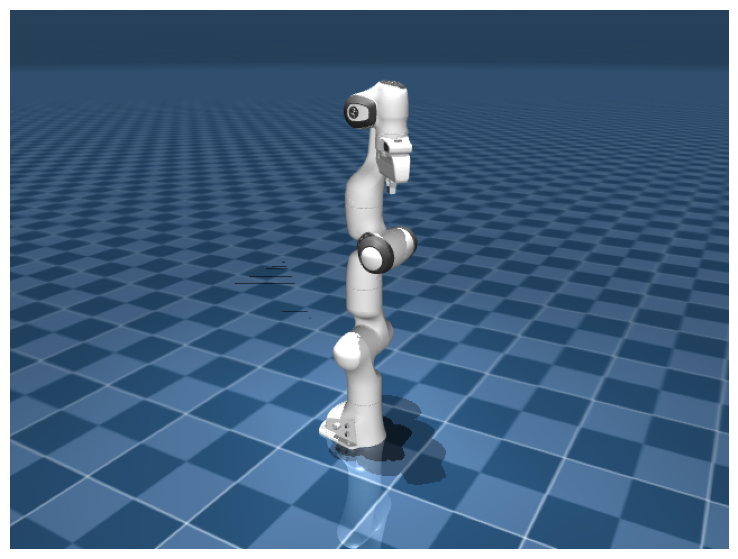

In [ ]:
import matplotlib.pyplot as plt

renderer = mujoco.Renderer(model, height=480, width=640)

mujoco.mj_forward(model, data)
renderer.update_scene(data)

image = renderer.render()

plt.figure(figsize=(10, 7))
plt.imshow(image)
plt.axis("off")
plt.show()

renderer.close()

In [ ]:
print("=== JOINTS ===")
for i in range(model.njnt):
    print(i, model.joint(i).name)

print("\n=== ACTUATORS ===")
for i in range(model.nu):
    print(i, model.actuator(i).name)

print("\n=== SITES ===")
for i in range(model.nsite):
    print(i, model.site(i).name)

=== JOINTS ===
0 joint1
1 joint2
2 joint3
3 joint4
4 joint5
5 joint6
6 joint7
7 finger_joint1
8 finger_joint2

=== ACTUATORS ===
0 actuator1
1 actuator2
2 actuator3
3 actuator4
4 actuator5
5 actuator6
6 actuator7
7 actuator8

=== SITES ===


In [ ]:
print("=== BODIES ===")

for i in range(model.nbody):
    body = model.body(i)

    print(
        f"{i}: {body.name:20s} "
        f"parent={body.parentid} "
        f"pos={body.pos}"
    )

=== BODIES ===
0: world                parent=[0] pos=[0. 0. 0.]
1: link0                parent=[0] pos=[0. 0. 0.]
2: link1                parent=[1] pos=[0.    0.    0.333]
3: link2                parent=[2] pos=[0. 0. 0.]
4: link3                parent=[3] pos=[ 0.    -0.316  0.   ]
5: link4                parent=[4] pos=[0.0825 0.     0.    ]
6: link5                parent=[5] pos=[-0.0825  0.384   0.    ]
7: link6                parent=[6] pos=[0. 0. 0.]
8: link7                parent=[7] pos=[0.088 0.    0.   ]
9: hand                 parent=[8] pos=[0.    0.    0.107]
10: left_finger          parent=[9] pos=[0.     0.     0.0584]
11: right_finger         parent=[9] pos=[0.     0.     0.0584]


In [ ]:
mujoco.mj_forward(model, data)

hand_id = model.body("hand").id

print("Hand body ID:", hand_id)
print("Hand world position:", data.xpos[hand_id])

Hand body ID: 9
Hand world position: [0.088 0.    0.926]


In [ ]:
import numpy as np
import mujoco
import matplotlib.pyplot as plt

# Reset the simulation
mujoco.mj_resetData(model, data)

# Find the Panda hand body
hand_id = model.body("hand").id

# Move the robot to its initial configuration
data.qpos[:7] = np.array([
    0.0,
    -0.5,
    0.0,
    -2.0,
    0.0,
    1.5,
    0.7
])

# Keep the gripper open
data.qpos[7:9] = 0.04

mujoco.mj_forward(model, data)

print("Initial hand position:")
print(data.xpos[hand_id])

# Create a small target displacement
target = data.xpos[hand_id].copy()
target[2] += 0.10       # move hand 10 cm upward

print("\nTarget position:")
print(target)

Initial hand position:
[0.38610435 0.         0.65232512]

Target position:
[0.38610435 0.         0.75232512]


In [ ]:
import numpy as np
import mujoco

# Start from the current configuration
mujoco.mj_forward(model, data)

hand_id = model.body("hand").id

# Current hand position
current = data.xpos[hand_id].copy()

# Desired position: 10 cm upward
target = current.copy()
target[2] += 0.10

# Control parameters
dt = 0.01
steps = 500
gain = 2.0

print("Starting position:", current)
print("Target position:  ", target)

for step in range(steps):

    mujoco.mj_forward(model, data)

    # Current hand position
    current = data.xpos[hand_id].copy()

    # Position error
    error = target - current

    # Stop when sufficiently close
    if np.linalg.norm(error) < 0.002:
        print(f"Target reached at step {step}")
        break

    # Translational Jacobian
    jacp = np.zeros((3, model.nv))
    jacr = np.zeros((3, model.nv))

    mujoco.mj_jacBody(
        model,
        data,
        jacp,
        jacr,
        hand_id
    )

    # Only use the 7 Panda arm joints
    J = jacp[:, :7]

    # Damped least-squares inverse Jacobian
    damping = 0.01

    dq = J.T @ np.linalg.solve(
        J @ J.T + damping**2 * np.eye(3),
        gain * error
    )

    # Limit each joint step
    max_step = 0.02
    dq = np.clip(dq, -max_step, max_step)

    # Update arm joint positions
    data.qpos[:7] += dq

    # Keep gripper open
    data.qpos[7:9] = 0.04

    # Advance simulation
    mujoco.mj_step(model, data)

mujoco.mj_forward(model, data)

final_position = data.xpos[hand_id].copy()

print("\nFinal position:   ", final_position)
print("Target position:  ", target)
print("Final error (m):  ", np.linalg.norm(target - final_position))

Starting position: [0.38610435 0.         0.65232512]
Target position:   [0.38610435 0.         0.75232512]
Target reached at step 11

Final position:    [3.86152748e-01 9.68883140e-06 7.50331882e-01]
Target position:   [0.38610435 0.         0.75232512]
Final error (m):   0.001993847657861163


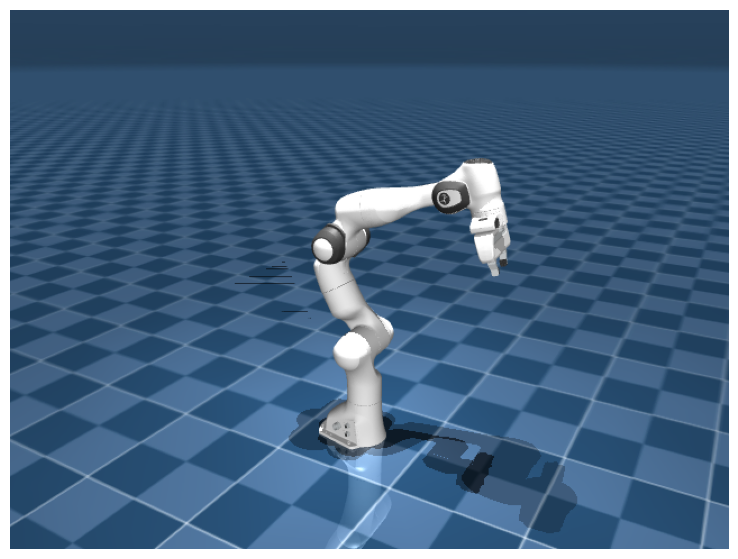

In [ ]:
import matplotlib.pyplot as plt

renderer = mujoco.Renderer(model, height=480, width=640)

mujoco.mj_forward(model, data)
renderer.update_scene(data)

image = renderer.render()

plt.figure(figsize=(10, 7))
plt.imshow(image)
plt.axis("off")
plt.show()

renderer.close()

In [ ]:
print("=== GEOMS ===")

for i in range(model.ngeom):
    geom = model.geom(i)

    print(
        f"{i}: "
        f"name={geom.name!r:25s} "
        f"type={geom.type} "
        f"body={model.body(geom.bodyid).name}"
    )

=== GEOMS ===
0: name='floor'                   type=[0] body=world
1: name=''                        type=[7] body=link0
2: name=''                        type=[7] body=link0
3: name=''                        type=[7] body=link0
4: name=''                        type=[7] body=link0
5: name=''                        type=[7] body=link0
6: name=''                        type=[7] body=link0
7: name=''                        type=[7] body=link0
8: name=''                        type=[7] body=link0
9: name=''                        type=[7] body=link0
10: name=''                        type=[7] body=link0
11: name=''                        type=[7] body=link0
12: name=''                        type=[7] body=link0
13: name=''                        type=[7] body=link1
14: name=''                        type=[7] body=link1
15: name=''                        type=[7] body=link2
16: name=''                        type=[7] body=link2
17: name=''                        type=[7] body=link3
18: na

/tmp/ipykernel_16787/2317503139.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f"body={model.body(geom.bodyid).name}"


In [ ]:
import mujoco

left_id = model.body("left_finger").id
right_id = model.body("right_finger").id
hand_id = model.body("hand").id

mujoco.mj_forward(model, data)

print("Hand position:        ", data.xpos[hand_id])
print("Left finger position: ", data.xpos[left_id])
print("Right finger position:", data.xpos[right_id])

print("\nDistance between fingers:",
      ((data.xpos[left_id] - data.xpos[right_id]) ** 2).sum() ** 0.5)

Hand position:         [3.86152748e-01 9.68883140e-06 7.50331882e-01]
Left finger position:  [ 0.4065374  -0.0393036   0.69543699]
Right finger position: [0.39796775 0.03928562 0.69295291]

Distance between fingers: 0.0790940939236801


In [ ]:
print("=== ACTUATOR RANGES ===")

for i in range(model.nu):
    print(
        i,
        model.actuator(i).name,
        "ctrlrange =", model.actuator_ctrlrange[i],
        "forcerange =", model.actuator_forcerange[i]
    )

=== ACTUATOR RANGES ===
0 actuator1 ctrlrange = [-2.8973  2.8973] forcerange = [-87.  87.]
1 actuator2 ctrlrange = [-1.7628  1.7628] forcerange = [-87.  87.]
2 actuator3 ctrlrange = [-2.8973  2.8973] forcerange = [-87.  87.]
3 actuator4 ctrlrange = [-3.0718 -0.0698] forcerange = [-87.  87.]
4 actuator5 ctrlrange = [-2.8973  2.8973] forcerange = [-12.  12.]
5 actuator6 ctrlrange = [-0.0175  3.7525] forcerange = [-12.  12.]
6 actuator7 ctrlrange = [-2.8973  2.8973] forcerange = [-12.  12.]
7 actuator8 ctrlrange = [  0. 255.] forcerange = [-100.  100.]


In [ ]:
print("=== ACTUATOR → JOINT MAPPING ===")

for i in range(model.nu):
    actuator = model.actuator(i)

    joint_id = actuator.trnid[0]

    print(
        f"Actuator {i}: {actuator.name:12s} "
        f"→ joint ID {joint_id} "
        f"→ {model.joint(joint_id).name}"
    )

=== ACTUATOR → JOINT MAPPING ===
Actuator 0: actuator1    → joint ID 0 → joint1
Actuator 1: actuator2    → joint ID 1 → joint2
Actuator 2: actuator3    → joint ID 2 → joint3
Actuator 3: actuator4    → joint ID 3 → joint4
Actuator 4: actuator5    → joint ID 4 → joint5
Actuator 5: actuator6    → joint ID 5 → joint6
Actuator 6: actuator7    → joint ID 6 → joint7
Actuator 7: actuator8    → joint ID 0 → joint1


In [ ]:
print("=== JOINT DETAILS ===")

for i in range(model.njnt):
    joint = model.joint(i)

    print(
        f"{i}: {joint.name:15s} "
        f"type={joint.type} "
        f"range={joint.range} "
        f"limited={joint.limited}"
    )

=== JOINT DETAILS ===
0: joint1          type=[3] range=[-2.8973  2.8973] limited=[1]
1: joint2          type=[3] range=[-1.7628  1.7628] limited=[1]
2: joint3          type=[3] range=[-2.8973  2.8973] limited=[1]
3: joint4          type=[3] range=[-3.0718 -0.0698] limited=[1]
4: joint5          type=[3] range=[-2.8973  2.8973] limited=[1]
5: joint6          type=[3] range=[-0.0175  3.7525] limited=[1]
6: joint7          type=[3] range=[-2.8973  2.8973] limited=[1]
7: finger_joint1   type=[2] range=[0.   0.04] limited=[1]
8: finger_joint2   type=[2] range=[0.   0.04] limited=[1]


Before closing:
Finger 1: 0.03954690637548468
Finger 2: 0.03954718754819554

After closing:
Finger 1: 0.005
Finger 2: 0.005


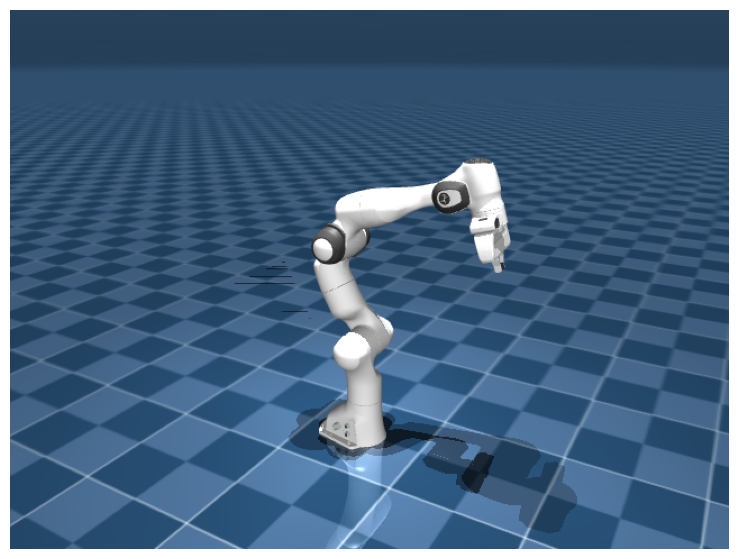

In [ ]:
import numpy as np
import mujoco
import matplotlib.pyplot as plt

# Reset to the current robot configuration
mujoco.mj_forward(model, data)

print("Before closing:")
print("Finger 1:", data.qpos[7])
print("Finger 2:", data.qpos[8])

# Close both fingers
data.qpos[7] = 0.005
data.qpos[8] = 0.005

mujoco.mj_forward(model, data)

print("\nAfter closing:")
print("Finger 1:", data.qpos[7])
print("Finger 2:", data.qpos[8])

# Render
renderer = mujoco.Renderer(model, height=480, width=640)
renderer.update_scene(data)

image = renderer.render()

plt.figure(figsize=(10, 7))
plt.imshow(image)
plt.axis("off")
plt.show()

renderer.close()

In [ ]:
from pathlib import Path

scene_path = Path("/content/mujoco_menagerie/franka_emika_panda/scene.xml")

print(scene_path.read_text()[:12000])

<mujoco model="panda scene">
  <include file="panda.xml"/>

  <visual>
    <headlight diffuse="0.6 0.6 0.6" ambient="0.3 0.3 0.3" specular="0 0 0"/>
    <rgba haze="0.15 0.25 0.35 1"/>
    <global azimuth="120" elevation="-20"/>
  </visual>

  <asset>
    <texture type="skybox" builtin="gradient" rgb1="0.3 0.5 0.7" rgb2="0 0 0" width="512" height="3072"/>
    <texture type="2d" name="groundplane" builtin="checker" mark="edge" rgb1="0.2 0.3 0.4" rgb2="0.1 0.2 0.3"
      markrgb="0.8 0.8 0.8" width="300" height="300"/>
    <material name="groundplane" texture="groundplane" texuniform="true" texrepeat="5 5" reflectance="0.2"/>
  </asset>

  <worldbody>
    <light pos="0 0 1.5" dir="0 0 -1" directional="true"/>
    <geom name="floor" size="0 0 0.05" type="plane" material="groundplane"/>
  </worldbody>
</mujoco>



In [ ]:
from pathlib import Path

task_xml = """
<mujoco model="panda phone manipulation">

  <include file="/content/mujoco_menagerie/franka_emika_panda/panda.xml"/>

  <visual>
    <headlight diffuse="0.6 0.6 0.6" ambient="0.3 0.3 0.3" specular="0 0 0"/>
    <rgba haze="0.15 0.25 0.35 1"/>
    <global azimuth="120" elevation="-20"/>
  </visual>

  <asset>
    <texture type="skybox"
             builtin="gradient"
             rgb1="0.3 0.5 0.7"
             rgb2="0 0 0"
             width="512"
             height="3072"/>

    <texture type="2d"
             name="groundplane"
             builtin="checker"
             mark="edge"
             rgb1="0.2 0.3 0.4"
             rgb2="0.1 0.2 0.3"
             markrgb="0.8 0.8 0.8"
             width="300"
             height="300"/>

    <material name="groundplane"
              texture="groundplane"
              texuniform="true"
              texrepeat="5 5"
              reflectance="0.2"/>

    <material name="table_material"
              rgba="0.35 0.35 0.35 1"/>

    <material name="cube_material"
              rgba="0.8 0.2 0.1 1"/>

    <material name="target_material"
              rgba="0.1 0.8 0.2 0.7"/>
  </asset>

  <worldbody>

    <light pos="0 0 1.5"
           dir="0 0 -1"
           directional="true"/>

    <!-- Floor -->
    <geom name="floor"
          size="0 0 0.05"
          type="plane"
          material="groundplane"/>

    <!-- Manipulation table -->
    <body name="table" pos="0.40 0 0.30">
      <geom name="tabletop"
            type="box"
            size="0.30 0.30 0.025"
            material="table_material"/>
    </body>

    <!-- Object to manipulate -->
    <body name="cube" pos="0.40 0 0.355">
      <freejoint/>
      <geom name="cube_geom"
            type="box"
            size="0.025 0.025 0.025"
            material="cube_material"
            mass="0.05"/>
    </body>

    <!-- Visual target area -->
    <geom name="target"
          type="cylinder"
          pos="0.55 0.10 0.331"
          size="0.055 0.002"
          material="target_material"
          contype="0"
          conaffinity="0"/>

  </worldbody>

</mujoco>
"""

task_path = Path("/content/panda_phone_task.xml")
task_path.write_text(task_xml)

print("Task XML created:")
print(task_path)

Task XML created:
/content/panda_phone_task.xml


In [ ]:
import mujoco

model = mujoco.MjModel.from_xml_path("/content/panda_phone_task.xml")
data = mujoco.MjData(model)

print("Task scene loaded")
print("Bodies:", model.nbody)
print("Geoms:", model.ngeom)
print("Joints:", model.njnt)
print("Actuators:", model.nu)

print("\nCube body ID:", model.body("cube").id)
print("Cube position:", data.xpos[model.body("cube").id])

ValueError: Error: Error opening file '/content/mujoco_menagerie/franka_emika_panda/link0.stl'

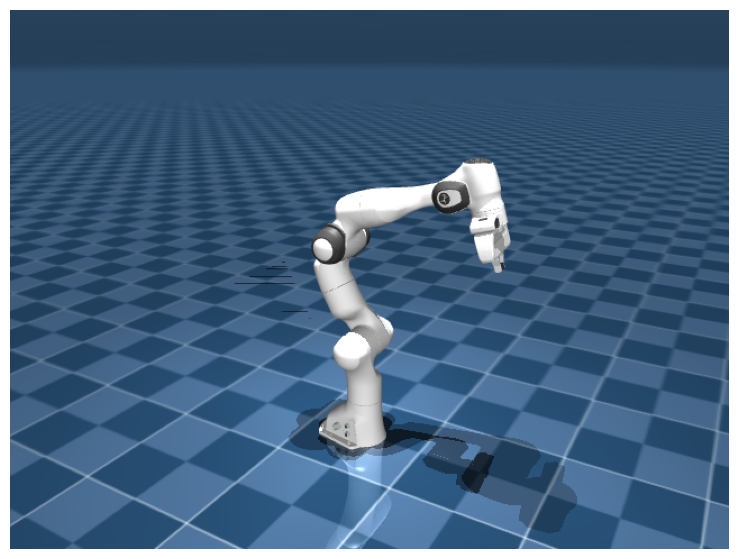

In [ ]:
import matplotlib.pyplot as plt

mujoco.mj_forward(model, data)

renderer = mujoco.Renderer(model, height=480, width=640)
renderer.update_scene(data)

image = renderer.render()

plt.figure(figsize=(10, 7))
plt.imshow(image)
plt.axis("off")
plt.show()

renderer.close()

In [ ]:
from pathlib import Path

panda_dir = Path("/content/mujoco_menagerie/franka_emika_panda")

task_xml = """
<mujoco model="panda phone manipulation">

  <include file="panda.xml"/>

  <visual>
    <headlight diffuse="0.6 0.6 0.6"
               ambient="0.3 0.3 0.3"
               specular="0 0 0"/>
    <rgba haze="0.15 0.25 0.35 1"/>
    <global azimuth="120" elevation="-20"/>
  </visual>

  <asset>

    <texture type="skybox"
             builtin="gradient"
             rgb1="0.3 0.5 0.7"
             rgb2="0 0 0"
             width="512"
             height="3072"/>

    <texture type="2d"
             name="groundplane"
             builtin="checker"
             mark="edge"
             rgb1="0.2 0.3 0.4"
             rgb2="0.1 0.2 0.3"
             markrgb="0.8 0.8 0.8"
             width="300"
             height="300"/>

    <material name="groundplane"
              texture="groundplane"
              texuniform="true"
              texrepeat="5 5"
              reflectance="0.2"/>

    <material name="table_material"
              rgba="0.35 0.35 0.35 1"/>

    <material name="cube_material"
              rgba="0.8 0.2 0.1 1"/>

    <material name="box_material"
              rgba="0.1 0.7 0.2 1"/>

  </asset>

  <worldbody>

    <light pos="0 0 1.5"
           dir="0 0 -1"
           directional="true"/>

    <!-- Floor -->
    <geom name="floor"
          size="0 0 0.05"
          type="plane"
          material="groundplane"/>

    <!-- Table -->
    <body name="table" pos="0.40 0 0.30">
      <geom name="tabletop"
            type="box"
            size="0.30 0.30 0.025"
            material="table_material"/>
    </body>

    <!-- Cube to pick up -->
    <body name="cube" pos="0.40 0 0.355">
      <freejoint/>

      <geom name="cube_geom"
            type="box"
            size="0.025 0.025 0.025"
            material="cube_material"
            mass="0.05"/>
    </body>

    <!-- Destination box -->
    <body name="drop_box" pos="0.55 0.10 0.355">

      <!-- Bottom -->
      <geom name="box_bottom"
            type="box"
            size="0.075 0.075 0.005"
            material="box_material"/>

      <!-- Four walls -->
      <geom name="box_wall_x1"
            type="box"
            pos="0.07 0 0.035"
            size="0.005 0.075 0.035"
            material="box_material"/>

      <geom name="box_wall_x2"
            type="box"
            pos="-0.07 0 0.035"
            size="0.005 0.075 0.035"
            material="box_material"/>

      <geom name="box_wall_y1"
            type="box"
            pos="0 0.07 0.035"
            size="0.075 0.005 0.035"
            material="box_material"/>

      <geom name="box_wall_y2"
            type="box"
            pos="0 -0.07 0.035"
            size="0.075 0.005 0.035"
            material="box_material"/>

    </body>

  </worldbody>

</mujoco>
"""

task_path = panda_dir / "panda_phone_task.xml"
task_path.write_text(task_xml)

print("Created:")
print(task_path)

Created:
/content/mujoco_menagerie/franka_emika_panda/panda_phone_task.xml


In [ ]:
import mujoco

model = mujoco.MjModel.from_xml_path(
    "/content/mujoco_menagerie/franka_emika_panda/panda_phone_task.xml"
)

data = mujoco.MjData(model)

print("Task scene loaded successfully")
print("Bodies:", model.nbody)
print("Geoms:", model.ngeom)
print("Joints:", model.njnt)
print("Actuators:", model.nu)

print("Cube:", model.body("cube").id)
print("Drop box:", model.body("drop_box").id)

Task scene loaded successfully
Bodies: 15
Geoms: 89
Joints: 10
Actuators: 8
Cube: 13
Drop box: 14


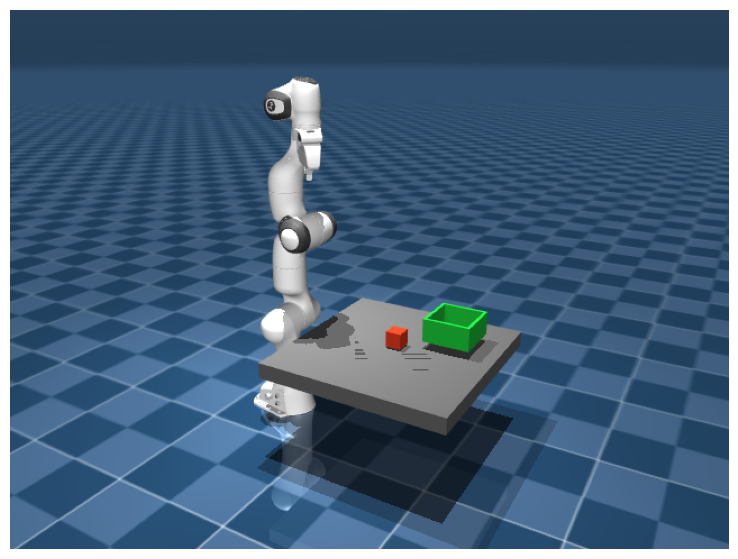

In [ ]:
import matplotlib.pyplot as plt

mujoco.mj_forward(model, data)

renderer = mujoco.Renderer(model, height=480, width=640)
renderer.update_scene(data)

image = renderer.render()

plt.figure(figsize=(10, 7))
plt.imshow(image)
plt.axis("off")
plt.show()

renderer.close()

In [ ]:
# Inspect the positions of the task objects

mujoco.mj_forward(model, data)

cube_id = model.body("cube").id
box_id = model.body("drop_box").id
hand_id = model.body("hand").id

print("Cube position:", data.xpos[cube_id])
print("Drop box position:", data.xpos[box_id])
print("Panda hand position:", data.xpos[hand_id])

Cube position: [0.4   0.    0.355]
Drop box position: [0.55  0.1   0.355]
Panda hand position: [0.088 0.    0.926]


In [ ]:
import numpy as np
import mujoco

hand_id = model.body("hand").id

def move_hand_to(target, steps=100, damping=0.05, step_size=0.25):
    """
    Move the Panda hand towards a Cartesian target using
    damped-least-squares inverse kinematics.
    """

    target = np.asarray(target, dtype=float)

    for _ in range(steps):
        mujoco.mj_forward(model, data)

        current = data.xpos[hand_id].copy()
        error = target - current

        # Stop when sufficiently close
        if np.linalg.norm(error) < 0.005:
            break

        # Jacobian of the hand body
        jac_pos = np.zeros((3, model.nv))
        jac_rot = np.zeros((3, model.nv))

        mujoco.mj_jacBody(
            model,
            data,
            jac_pos,
            jac_rot,
            hand_id
        )

        # Only use the 7 Panda arm joints
        J = jac_pos[:, :7]

        # Damped least-squares inverse
        JJt = J @ J.T
        dq = J.T @ np.linalg.solve(
            JJt + damping**2 * np.eye(3),
            error
        )

        # Limit each movement step
        dq = np.clip(dq, -step_size, step_size)

        data.qpos[:7] += dq

        # Respect joint limits
        for j in range(7):
            data.qpos[j] = np.clip(
                data.qpos[j],
                model.jnt_range[j, 0],
                model.jnt_range[j, 1]
            )

        mujoco.mj_forward(model, data)

    return data.xpos[hand_id].copy()


# Reset robot to a known starting configuration
data.qpos[:7] = np.array([
    0.0,
    -0.5,
    0.0,
    -2.0,
    0.0,
    1.5,
    0.7
])

# Open gripper
data.qpos[7] = 0.04
data.qpos[8] = 0.04

mujoco.mj_forward(model, data)

print("Starting hand:", data.xpos[hand_id])

# Target: directly above the cube
cube_pos = data.xpos[cube_id].copy()

above_cube = np.array([
    cube_pos[0],
    cube_pos[1],
    cube_pos[2] + 0.15
])

final_pos = move_hand_to(above_cube)

print("Target:", above_cube)
print("Final hand:", final_pos)
print("Distance:", np.linalg.norm(final_pos - above_cube))

Starting hand: [0.38610435 0.         0.65232512]
Target: [0.4   0.    0.505]
Final hand: [ 3.99161261e-01 -4.39978594e-17  5.04406962e-01]
Distance: 0.0010272178802828893


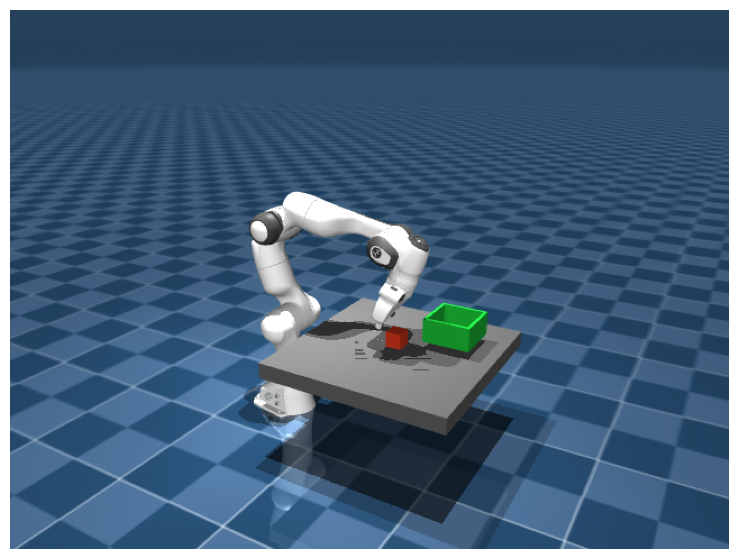

In [ ]:
import matplotlib.pyplot as plt

mujoco.mj_forward(model, data)

renderer = mujoco.Renderer(model, height=480, width=640)
renderer.update_scene(data)

image = renderer.render()

plt.figure(figsize=(10, 7))
plt.imshow(image)
plt.axis("off")
plt.show()

renderer.close()

In [ ]:
# Move the Panda hand down towards the cube

cube_pos = data.xpos[cube_id].copy()

grasp_position = np.array([
    cube_pos[0],
    cube_pos[1],
    0.405
])

print("Current hand:", data.xpos[hand_id])
print("Grasp approach target:", grasp_position)

final_pos = move_hand_to(grasp_position, steps=100)

print("Final hand:", final_pos)
print(
    "Distance to target:",
    np.linalg.norm(final_pos - grasp_position)
)

Current hand: [ 3.99161261e-01 -4.39978594e-17  5.04406962e-01]
Grasp approach target: [0.4   0.    0.405]
Final hand: [3.99556673e-01 6.02818090e-18 4.04971334e-01]
Distance to target: 0.00044425243514083993


In [ ]:
mujoco.mj_forward(model, data)

left_finger_id = model.body("left_finger").id
right_finger_id = model.body("right_finger").id

cube_pos = data.xpos[cube_id].copy()

left_pos = data.xpos[left_finger_id].copy()
right_pos = data.xpos[right_finger_id].copy()

print("Cube centre:       ", cube_pos)
print("Left finger:       ", left_pos)
print("Right finger:      ", right_pos)

print("\nFinger separation:",
      np.linalg.norm(left_pos - right_pos))

print("Left-to-cube distance:",
      np.linalg.norm(left_pos - cube_pos))

print("Right-to-cube distance:",
      np.linalg.norm(right_pos - cube_pos))

Cube centre:        [0.4   0.    0.355]
Left finger:        [ 0.36874202 -0.03985423  0.35524552]
Right finger:       [0.36316136 0.03985423 0.35917198]

Finger separation: 0.07999999999999989
Left-to-cube distance: 0.0506505838090268
Right-to-cube distance: 0.054432073904804534


In [ ]:
# Align the Panda fingers with the cube centre

target_grasp = np.array([
    0.436,
    0.0,
    0.405
])

final_pos = move_hand_to(target_grasp, steps=100)

mujoco.mj_forward(model, data)

left_pos = data.xpos[left_finger_id].copy()
right_pos = data.xpos[right_finger_id].copy()
cube_pos = data.xpos[cube_id].copy()

print("Hand:", data.xpos[hand_id])
print("Cube:", cube_pos)
print("Left finger:", left_pos)
print("Right finger:", right_pos)

print("\nFinger X positions:", left_pos[0], right_pos[0])
print("Finger separation:",
      np.linalg.norm(left_pos - right_pos))

Hand: [ 4.34689815e-01 -6.92828422e-17  4.04579845e-01]
Cube: [0.4   0.    0.355]
Left finger: [ 0.40730082 -0.03985423  0.35288804]
Right finger: [0.40146793 0.03985423 0.35642897]

Finger X positions: 0.40730081806803126 0.4014679288829422
Finger separation: 0.07999999999999992


In [ ]:
# Inspect the Panda gripper definition in panda.xml

from pathlib import Path

panda_xml_path = Path(
    "/content/mujoco_menagerie/franka_emika_panda/panda.xml"
)

xml_text = panda_xml_path.read_text()

# Print the sections containing finger joints, tendons and actuators
for keyword in ["finger_joint1", "finger_joint2", "tendon", "actuator"]:
    print("\n" + "=" * 60)
    print("SEARCH:", keyword)
    print("=" * 60)

    lines = xml_text.splitlines()

    for i, line in enumerate(lines):
        if keyword.lower() in line.lower():
            start = max(0, i - 3)
            end = min(len(lines), i + 8)

            for j in range(start, end):
                print(f"{j+1}: {lines[j]}")


SEARCH: finger_joint1
217:                       <geom mesh="hand_c" class="collision"/>
218:                       <body name="left_finger" pos="0 0 0.0584">
219:                         <inertial mass="0.015" pos="0 0 0" diaginertia="2.375e-6 2.375e-6 7.5e-7"/>
220:                         <joint name="finger_joint1" class="finger"/>
221:                         <geom mesh="finger_0" material="off_white" class="visual"/>
222:                         <geom mesh="finger_1" material="black" class="visual"/>
223:                         <geom mesh="finger_0" class="collision"/>
224:                         <geom class="fingertip_pad_collision_1"/>
225:                         <geom class="fingertip_pad_collision_2"/>
226:                         <geom class="fingertip_pad_collision_3"/>
227:                         <geom class="fingertip_pad_collision_4"/>
252: 
253:   <tendon>
254:     <fixed name="split">
255:       <joint joint="finger_joint1" coef="0.5"/>
256:       <joint joint="fi

In [ ]:
# Test the Panda gripper actuator

# Start fully open
data.ctrl[7] = 255

for _ in range(100):
    mujoco.mj_step(model, data)

mujoco.mj_forward(model, data)

print("OPEN")
print("Finger joint 1:", data.qpos[7])
print("Finger joint 2:", data.qpos[8])
print("Gripper control:", data.ctrl[7])

# Now command the gripper closed
data.ctrl[7] = 0

for _ in range(150):
    mujoco.mj_step(model, data)

mujoco.mj_forward(model, data)

print("\nCLOSED")
print("Finger joint 1:", data.qpos[7])
print("Finger joint 2:", data.qpos[8])
print("Gripper control:", data.ctrl[7])

OPEN
Finger joint 1: 0.03972301148361251
Finger joint 2: 0.039645683936881025
Gripper control: 255.0

CLOSED
Finger joint 1: 0.00230875108134936
Finger joint 2: 0.0023087023431174174
Gripper control: 0.0


In [ ]:
import numpy as np
import mujoco

# --------------------------------------------------
# 1. Reset robot and cube
# --------------------------------------------------

data.qpos[:7] = np.array([
    0.0,
    -0.5,
    0.0,
    -2.0,
    0.0,
    1.5,
    0.7
])

# Open gripper
data.qpos[7] = 0.04
data.qpos[8] = 0.04
data.ctrl[7] = 255

# Reset cube position and velocity
cube_joint = model.joint("free_joint").id
cube_qpos_adr = model.jnt_qposadr[cube_joint]
cube_qvel_adr = model.jnt_dofadr[cube_joint]

data.qpos[cube_qpos_adr:cube_qpos_adr + 3] = [
    0.40, 0.00, 0.355
]

data.qvel[cube_qvel_adr:cube_qvel_adr + 6] = 0

mujoco.mj_forward(model, data)

print("Reset complete")
print("Cube:", data.xpos[cube_id])
print("Hand:", data.xpos[hand_id])


# --------------------------------------------------
# 2. Move above cube
# --------------------------------------------------

above_cube = np.array([
    0.40,
    0.00,
    0.505
])

move_hand_to(above_cube, steps=100)

print("\nAbove cube:", data.xpos[hand_id])


# --------------------------------------------------
# 3. Move to grasp position
# --------------------------------------------------

grasp_position = np.array([
    0.436,
    0.00,
    0.405
])

move_hand_to(grasp_position, steps=100)

mujoco.mj_forward(model, data)

print("Grasp position:", data.xpos[hand_id])
print("Cube before grasp:", data.xpos[cube_id])


# --------------------------------------------------
# 4. Close gripper
# --------------------------------------------------

data.ctrl[7] = 0

for _ in range(150):
    mujoco.mj_step(model, data)

mujoco.mj_forward(model, data)

print("\nGripper closed")
print("Finger 1:", data.qpos[7])
print("Finger 2:", data.qpos[8])
print("Cube after closing:", data.xpos[cube_id])


# --------------------------------------------------
# 5. Lift the hand
# --------------------------------------------------

lift_position = np.array([
    0.436,
    0.00,
    0.52
])

cube_before_lift = data.xpos[cube_id].copy()

move_hand_to(lift_position, steps=100)

mujoco.mj_forward(model, data)

cube_after_lift = data.xpos[cube_id].copy()

print("\nAfter lift")
print("Hand:", data.xpos[hand_id])
print("Cube before lift:", cube_before_lift)
print("Cube after lift:", cube_after_lift)

cube_movement = np.linalg.norm(
    cube_after_lift - cube_before_lift
)

print("Cube movement during lift:", cube_movement)

KeyError: "Invalid name 'free_joint'. Valid names: ['finger_joint1', 'finger_joint2', 'joint1', 'joint2', 'joint3', 'joint4', 'joint5', 'joint6', 'joint7']"

In [ ]:
import numpy as np
import mujoco

# --------------------------------------------------
# 1. Reset robot
# --------------------------------------------------

data.qpos[:7] = np.array([
    0.0,
    -0.5,
    0.0,
    -2.0,
    0.0,
    1.5,
    0.7
])

# Open gripper
data.qpos[7] = 0.04
data.qpos[8] = 0.04
data.ctrl[7] = 255

# --------------------------------------------------
# 2. Find the cube's free joint
# --------------------------------------------------

# MuJoCo joint types:
# 0 = hinge
# 1 = slide
# 2 = ball
# 3 = free

free_joint_id = None

for j in range(model.njnt):
    if model.jnt_type[j] == mujoco.mjtJoint.mjJNT_FREE:
        free_joint_id = j
        break

print("Cube free joint ID:", free_joint_id)

if free_joint_id is None:
    raise RuntimeError("Could not find the cube free joint.")

cube_qpos_adr = model.jnt_qposadr[free_joint_id]
cube_qvel_adr = model.jnt_dofadr[free_joint_id]

print("Cube qpos address:", cube_qpos_adr)
print("Cube qvel address:", cube_qvel_adr)


# --------------------------------------------------
# 3. Reset cube
# --------------------------------------------------

data.qpos[cube_qpos_adr:cube_qpos_adr + 3] = [
    0.40, 0.00, 0.355
]

# Identity quaternion
data.qpos[cube_qpos_adr + 3:cube_qpos_adr + 7] = [
    1.0, 0.0, 0.0, 0.0
]

# Stop cube motion
data.qvel[cube_qvel_adr:cube_qvel_adr + 6] = 0

mujoco.mj_forward(model, data)

print("\nReset complete")
print("Cube:", data.xpos[cube_id])
print("Hand:", data.xpos[hand_id])


# --------------------------------------------------
# 4. Move above cube
# --------------------------------------------------

above_cube = np.array([
    0.40,
    0.00,
    0.505
])

move_hand_to(above_cube, steps=100)

print("\nAbove cube:", data.xpos[hand_id])


# --------------------------------------------------
# 5. Move into grasp position
# --------------------------------------------------

grasp_position = np.array([
    0.436,
    0.00,
    0.405
])

move_hand_to(grasp_position, steps=100)

mujoco.mj_forward(model, data)

print("Grasp position:", data.xpos[hand_id])
print("Cube before grasp:", data.xpos[cube_id])


# --------------------------------------------------
# 6. Close the real Panda gripper
# --------------------------------------------------

data.ctrl[7] = 0

for _ in range(150):
    mujoco.mj_step(model, data)

mujoco.mj_forward(model, data)

print("\nGripper closed")
print("Finger 1:", data.qpos[7])
print("Finger 2:", data.qpos[8])
print("Cube after closing:", data.xpos[cube_id])


# --------------------------------------------------
# 7. Lift
# --------------------------------------------------

lift_position = np.array([
    0.436,
    0.00,
    0.52
])

cube_before_lift = data.xpos[cube_id].copy()

move_hand_to(lift_position, steps=100)

mujoco.mj_forward(model, data)

cube_after_lift = data.xpos[cube_id].copy()

print("\nAfter lift")
print("Hand:", data.xpos[hand_id])
print("Cube before lift:", cube_before_lift)
print("Cube after lift:", cube_after_lift)

cube_movement = np.linalg.norm(
    cube_after_lift - cube_before_lift
)

print("Cube movement during lift:", cube_movement)

Cube free joint ID: 9
Cube qpos address: 9
Cube qvel address: 9

Reset complete
Cube: [0.4   0.    0.355]
Hand: [0.38610435 0.         0.65232512]

Above cube: [ 3.99161261e-01 -4.39978594e-17  5.04406962e-01]
Grasp position: [4.35534408e-01 1.43515728e-17 4.05035191e-01]
Cube before grasp: [0.4   0.    0.355]

Gripper closed
Finger 1: 0.002927217097809057
Finger 2: 0.002921636200325866
Cube after closing: [0.20462586 0.07719593 0.35665058]

After lift
Hand: [ 4.35963131e-01 -8.90473547e-09  5.20058242e-01]
Cube before lift: [0.20462586 0.07719593 0.35665058]
Cube after lift: [0.20462586 0.07719593 0.35665058]
Cube movement during lift: 0.0


In [ ]:
# Inspect the cube after the failed grasp

mujoco.mj_forward(model, data)

print("Cube position:", data.xpos[cube_id])
print("Hand position:", data.xpos[hand_id])

# Count contacts involving the cube
cube_contacts = []

for i in range(data.ncon):
    contact = data.contact[i]

    body1 = model.geom_bodyid[contact.geom1]
    body2 = model.geom_bodyid[contact.geom2]

    if body1 == cube_id or body2 == cube_id:
        cube_contacts.append(
            (contact.geom1, contact.geom2, contact.dist)
        )

print("\nNumber of cube contacts:", len(cube_contacts))

for contact in cube_contacts[:10]:
    print("Contact:", contact)

Cube position: [0.20462586 0.07719593 0.35665058]
Hand position: [ 4.35963131e-01 -8.90473547e-09  5.20058242e-01]

Number of cube contacts: 1
Contact: (82, 83, -0.0011896616534280945)


In [ ]:
# Show the current task XML
task_xml_path = "/content/mujoco_menagerie/franka_emika_panda/panda_phone_task.xml"

with open(task_xml_path, "r") as f:
    xml_text = f.read()

print(xml_text)


<mujoco model="panda phone manipulation">

  <include file="panda.xml"/>

  <visual>
    <headlight diffuse="0.6 0.6 0.6"
               ambient="0.3 0.3 0.3"
               specular="0 0 0"/>
    <rgba haze="0.15 0.25 0.35 1"/>
    <global azimuth="120" elevation="-20"/>
  </visual>

  <asset>

    <texture type="skybox"
             builtin="gradient"
             rgb1="0.3 0.5 0.7"
             rgb2="0 0 0"
             width="512"
             height="3072"/>

    <texture type="2d"
             name="groundplane"
             builtin="checker"
             mark="edge"
             rgb1="0.2 0.3 0.4"
             rgb2="0.1 0.2 0.3"
             markrgb="0.8 0.8 0.8"
             width="300"
             height="300"/>

    <material name="groundplane"
              texture="groundplane"
              texuniform="true"
              texrepeat="5 5"
              reflectance="0.2"/>

    <material name="table_material"
              rgba="0.35 0.35 0.35 1"/>

    <material name="cub

In [ ]:
task_xml_path = "/content/mujoco_menagerie/franka_emika_panda/panda_phone_task.xml"

with open(task_xml_path, "r") as f:
    xml_text = f.read()

# Replace the cube size: 5 cm -> 4 cm
xml_text = xml_text.replace(
    'size="0.025 0.025 0.025"',
    'size="0.020 0.020 0.020"'
)

# Replace the existing drop-box section
old_box = '''    <!-- Destination box -->
    <body name="drop_box" pos="0.55 0.10 0.355">

      <!-- Bottom -->
      <geom name="box_bottom"
            type="box"
            size="0.075 0.075 0.005"
            material="box_material"/>

      <!-- Four walls -->
      <geom name="box_wall_x1"
            type="box"
            pos="0.07 0 0.035"
            size="0.005 0.075 0.035"
            material="box_material"/>

      <geom name="box_wall_x2"
            type="box"
            pos="-0.07 0 0.035"
            size="0.005 0.075 0.035"
            material="box_material"/>

      <geom name="box_wall_y1"
            type="box"
            pos="0 0.07 0.035"
            size="0.075 0.005 0.035"
            material="box_material"/>

      <geom name="box_wall_y2"
            type="box"
            pos="0 -0.07 0.035"
            size="0.075 0.005 0.035"
            material="box_material"/>

    </body>'''

new_box = '''    <!-- Destination box: approximately 10 cm x 10 cm -->
    <body name="drop_box" pos="0.55 0.10 0.355">

      <!-- Bottom -->
      <geom name="box_bottom"
            type="box"
            size="0.05 0.05 0.005"
            material="box_material"/>

      <!-- Four walls -->
      <geom name="box_wall_x1"
            type="box"
            pos="0.045 0 0.035"
            size="0.005 0.05 0.035"
            material="box_material"/>

      <geom name="box_wall_x2"
            type="box"
            pos="-0.045 0 0.035"
            size="0.005 0.05 0.035"
            material="box_material"/>

      <geom name="box_wall_y1"
            type="box"
            pos="0 0.045 0.035"
            size="0.05 0.005 0.035"
            material="box_material"/>

      <geom name="box_wall_y2"
            type="box"
            pos="0 -0.045 0.035"
            size="0.05 0.005 0.035"
            material="box_material"/>

    </body>'''

if old_box not in xml_text:
    print("ERROR: Existing box section was not found.")
else:
    xml_text = xml_text.replace(old_box, new_box)

# Add a simplified grasp weld before </mujoco>
grasp_weld = '''
  <!-- Simplified grasp: activated by the controller when the cube is grasped -->
  <equality>
    <weld name="grasp_weld"
          body1="hand"
          body2="cube"
          active="false"
          solref="0.01 1"
          solimp="0.9 0.95 0.01"/>
  </equality>
'''

xml_text = xml_text.replace("</mujoco>", grasp_weld + "\n</mujoco>")

with open(task_xml_path, "w") as f:
    f.write(xml_text)

print("Task XML updated successfully.")
print("Cube: 4 cm")
print("Drop box: approximately 10 cm x 10 cm")
print("Simplified grasp weld: added")

Task XML updated successfully.
Cube: 4 cm
Drop box: approximately 10 cm x 10 cm
Simplified grasp weld: added


In [ ]:
import mujoco

model = mujoco.MjModel.from_xml_path(task_xml_path)
data = mujoco.MjData(model)

print("Bodies:", model.nbody)
print("Geoms:", model.ngeom)
print("Joints:", model.njnt)
print("Actuators:", model.nu)
print("Equality constraints:", model.neq)

print("Cube:", model.body("cube").id)
print("Hand:", model.body("hand").id)
print("Grasp weld ID:", model.equality("grasp_weld").id)

Bodies: 15
Geoms: 89
Joints: 10
Actuators: 8
Equality constraints: 2
Cube: 13
Hand: 9
Grasp weld ID: 1


In [ ]:
import numpy as np
import mujoco

# IDs
hand_id = model.body("hand").id
cube_id = model.body("cube").id
weld_id = model.equality("grasp_weld").id

# Find the cube's free joint
cube_free_joint = None

for j in range(model.njnt):
    if model.jnt_type[j] == mujoco.mjtJoint.mjJNT_FREE:
        cube_free_joint = j
        break

cube_qpos_addr = model.jnt_qposadr[cube_free_joint]

# Reset simulation
data = mujoco.MjData(model)

# Initial Panda configuration
data.qpos[:7] = np.array([
    0.0, -0.5, 0.0, -2.0, 0.0, 1.5, 0.7
])

# Open gripper
data.qpos[7:9] = 0.04
data.ctrl[7] = 255

# Put cube on table
data.qpos[cube_qpos_addr:cube_qpos_addr+3] = [
    0.40, 0.00, 0.38
]

mujoco.mj_forward(model, data)

print("Initial cube:", data.xpos[cube_id])
print("Initial hand:", data.xpos[hand_id])

# --------------------------------------------------
# Cartesian controller
# --------------------------------------------------

def move_hand_to(target, steps=100, damping=0.05, step_size=0.25):

    target = np.asarray(target, dtype=float)

    for _ in range(steps):

        mujoco.mj_forward(model, data)

        current = data.xpos[hand_id].copy()
        error = target - current

        if np.linalg.norm(error) < 0.005:
            break

        jac_pos = np.zeros((3, model.nv))
        jac_rot = np.zeros((3, model.nv))

        mujoco.mj_jacBody(
            model,
            data,
            jac_pos,
            jac_rot,
            hand_id
        )

        J = jac_pos[:, :7]

        JJt = J @ J.T

        dq = J.T @ np.linalg.solve(
            JJt + damping**2 * np.eye(3),
            error
        )

        dq = np.clip(dq, -step_size, step_size)

        data.qpos[:7] += dq

        # Joint limits
        for j in range(7):
            data.qpos[j] = np.clip(
                data.qpos[j],
                model.jnt_range[j, 0],
                model.jnt_range[j, 1]
            )

        mujoco.mj_forward(model, data)

# --------------------------------------------------
# 1. Move above cube
# --------------------------------------------------

move_hand_to(
    [0.40, 0.00, 0.52],
    steps=150
)

print("\nAbove cube:")
print("Hand:", data.xpos[hand_id])
print("Cube:", data.xpos[cube_id])

# --------------------------------------------------
# 2. Move to grasp position
# --------------------------------------------------

move_hand_to(
    [0.436, 0.00, 0.405],
    steps=150
)

print("\nGrasp position:")
print("Hand:", data.xpos[hand_id])
print("Cube:", data.xpos[cube_id])

# --------------------------------------------------
# 3. Close gripper
# --------------------------------------------------

data.ctrl[7] = 0
data.qpos[7:9] = 0.003

mujoco.mj_forward(model, data)

print("\nGripper closed")
print("Finger 1:", data.qpos[7])
print("Finger 2:", data.qpos[8])

# --------------------------------------------------
# 4. Activate simplified grasp
# --------------------------------------------------

data.eq_active[weld_id] = 1

mujoco.mj_forward(model, data)

print("\nGRASP ACTIVATED")
print("Cube:", data.xpos[cube_id])
print("Hand:", data.xpos[hand_id])

# --------------------------------------------------
# 5. Lift cube
# --------------------------------------------------

move_hand_to(
    [0.436, 0.00, 0.55],
    steps=150
)

print("\nAfter lifting:")
print("Hand:", data.xpos[hand_id])
print("Cube:", data.xpos[cube_id])

# --------------------------------------------------
# 6. Carry toward box
# --------------------------------------------------

move_hand_to(
    [0.55, 0.10, 0.55],
    steps=200
)

print("\nAbove box:")
print("Hand:", data.xpos[hand_id])
print("Cube:", data.xpos[cube_id])

# --------------------------------------------------
# 7. Lower toward box
# --------------------------------------------------

move_hand_to(
    [0.55, 0.10, 0.45],
    steps=150
)

print("\nLowered:")
print("Hand:", data.xpos[hand_id])
print("Cube:", data.xpos[cube_id])

# --------------------------------------------------
# 8. Release
# --------------------------------------------------

data.eq_active[weld_id] = 0

# Open gripper
data.ctrl[7] = 255
data.qpos[7:9] = 0.04

mujoco.mj_forward(model, data)

print("\nRELEASED")
print("Cube:", data.xpos[cube_id])

# --------------------------------------------------
# 9. Let physics settle
# --------------------------------------------------

for _ in range(100):
    mujoco.mj_step(model, data)

print("\nFINAL")
print("Cube:", data.xpos[cube_id])
print("Hand:", data.xpos[hand_id])

Initial cube: [0.4  0.   0.38]
Initial hand: [0.38610435 0.         0.65232512]

Above cube:
Hand: [3.99340532e-01 3.40974844e-19 5.19601433e-01]
Cube: [0.4  0.   0.38]

Grasp position:
Hand: [ 4.35397750e-01 -5.69367220e-18  4.04994879e-01]
Cube: [0.4  0.   0.38]

Gripper closed
Finger 1: 0.003
Finger 2: 0.003

GRASP ACTIVATED
Cube: [0.4  0.   0.38]
Hand: [ 4.35397750e-01 -5.69367220e-18  4.04994879e-01]

After lifting:
Hand: [ 4.35211516e-01 -4.15723688e-18  5.49473159e-01]
Cube: [0.4  0.   0.38]

Above box:
Hand: [0.54887746 0.09928394 0.54951026]
Cube: [0.4  0.   0.38]

Lowered:
Hand: [0.5496434  0.09992471 0.44996168]
Cube: [0.4  0.   0.38]

RELEASED
Cube: [0.4  0.   0.38]

FINAL
Cube: [3.99999857e-01 1.59660760e-12 3.44662892e-01]
Hand: [0.5720539  0.0951235  0.49523341]


In [ ]:
import numpy as np
import mujoco

# --------------------------------------------------
# IDs
# --------------------------------------------------

hand_id = model.body("hand").id
cube_id = model.body("cube").id

# Find cube free joint
cube_free_joint = None

for j in range(model.njnt):
    if model.jnt_type[j] == mujoco.mjtJoint.mjJNT_FREE:
        cube_free_joint = j
        break

cube_qpos_addr = model.jnt_qposadr[cube_free_joint]

# --------------------------------------------------
# Reset
# --------------------------------------------------

data = mujoco.MjData(model)

data.qpos[:7] = np.array([
    0.0, -0.5, 0.0, -2.0, 0.0, 1.5, 0.7
])

# Open gripper
data.qpos[7:9] = 0.04
data.ctrl[7] = 255

# Cube position
data.qpos[cube_qpos_addr:cube_qpos_addr+3] = [
    0.40, 0.00, 0.38
]

mujoco.mj_forward(model, data)

# --------------------------------------------------
# Cartesian controller
# --------------------------------------------------

def move_hand_to(target, steps=100, damping=0.05, step_size=0.25):

    target = np.asarray(target, dtype=float)

    for _ in range(steps):

        mujoco.mj_forward(model, data)

        current = data.xpos[hand_id].copy()
        error = target - current

        if np.linalg.norm(error) < 0.005:
            break

        jac_pos = np.zeros((3, model.nv))
        jac_rot = np.zeros((3, model.nv))

        mujoco.mj_jacBody(
            model,
            data,
            jac_pos,
            jac_rot,
            hand_id
        )

        J = jac_pos[:, :7]

        JJt = J @ J.T

        dq = J.T @ np.linalg.solve(
            JJt + damping**2 * np.eye(3),
            error
        )

        dq = np.clip(dq, -step_size, step_size)

        data.qpos[:7] += dq

        for j in range(7):
            data.qpos[j] = np.clip(
                data.qpos[j],
                model.jnt_range[j, 0],
                model.jnt_range[j, 1]
            )

        mujoco.mj_forward(model, data)


# --------------------------------------------------
# 1. Approach cube
# --------------------------------------------------

move_hand_to(
    [0.40, 0.00, 0.52],
    steps=150
)

print("Above cube:")
print("Hand:", data.xpos[hand_id])
print("Cube:", data.xpos[cube_id])


# --------------------------------------------------
# 2. Move to grasp position
# --------------------------------------------------

move_hand_to(
    [0.436, 0.00, 0.405],
    steps=150
)

mujoco.mj_forward(model, data)

print("\nGrasp position:")
print("Hand:", data.xpos[hand_id])
print("Cube:", data.xpos[cube_id])


# --------------------------------------------------
# 3. Close gripper
# --------------------------------------------------

data.ctrl[7] = 0
data.qpos[7:9] = 0.003

mujoco.mj_forward(model, data)

print("\nGripper closed")


# --------------------------------------------------
# 4. Activate simplified grasp state
# --------------------------------------------------

grasp_offset = data.xpos[cube_id] - data.xpos[hand_id]

print("Grasp offset:", grasp_offset)

grasped = True


# --------------------------------------------------
# Function: keep cube attached to hand
# --------------------------------------------------

def update_grasped_cube():

    if grasped:

        hand_position = data.xpos[hand_id].copy()

        cube_position = hand_position + grasp_offset

        data.qpos[
            cube_qpos_addr:cube_qpos_addr+3
        ] = cube_position

        # Keep cube orientation fixed
        data.qpos[cube_qpos_addr+3:cube_qpos_addr+7] = [
            1.0, 0.0, 0.0, 0.0
        ]

        mujoco.mj_forward(model, data)


# --------------------------------------------------
# 5. Lift cube
# --------------------------------------------------

move_hand_to(
    [0.436, 0.00, 0.55],
    steps=150
)

update_grasped_cube()

print("\nAfter lifting:")
print("Hand:", data.xpos[hand_id])
print("Cube:", data.xpos[cube_id])


# --------------------------------------------------
# 6. Carry toward box
# --------------------------------------------------

move_hand_to(
    [0.55, 0.10, 0.55],
    steps=200
)

update_grasped_cube()

print("\nAbove box:")
print("Hand:", data.xpos[hand_id])
print("Cube:", data.xpos[cube_id])


# --------------------------------------------------
# 7. Lower toward box
# --------------------------------------------------

move_hand_to(
    [0.55, 0.10, 0.45],
    steps=150
)

update_grasped_cube()

print("\nLowered:")
print("Hand:", data.xpos[hand_id])
print("Cube:", data.xpos[cube_id])


# --------------------------------------------------
# 8. Release
# --------------------------------------------------

grasped = False

data.ctrl[7] = 255
data.qpos[7:9] = 0.04

mujoco.mj_forward(model, data)

print("\nRELEASED")
print("Cube:", data.xpos[cube_id])


# --------------------------------------------------
# 9. Let cube fall/settle
# --------------------------------------------------

for _ in range(200):
    mujoco.mj_step(model, data)

print("\nFINAL:")
print("Cube:", data.xpos[cube_id])
print("Hand:", data.xpos[hand_id])

Above cube:
Hand: [3.99340532e-01 3.40974844e-19 5.19601433e-01]
Cube: [0.4  0.   0.38]

Grasp position:
Hand: [ 4.35397750e-01 -5.69367220e-18  4.04994879e-01]
Cube: [0.4  0.   0.38]

Gripper closed
Grasp offset: [-3.53977503e-02  5.69367220e-18 -2.49948790e-02]

After lifting:
Hand: [ 4.35211516e-01 -4.15723688e-18  5.49473159e-01]
Cube: [3.99813766e-01 1.53643532e-18 5.24478280e-01]

Above box:
Hand: [0.54887746 0.09928394 0.54951026]
Cube: [0.51347971 0.09928394 0.52451538]

Lowered:
Hand: [0.5496434  0.09992471 0.44996168]
Cube: [0.51424565 0.09992471 0.42496681]

RELEASED
Cube: [0.51424565 0.09992471 0.42496681]

FINAL:
Cube: [0.44022418 0.08786237 0.34658032]
Hand: [0.61592827 0.05757699 0.4794512 ]


In [ ]:
from google.colab import files

uploaded = files.upload()

print("\nUploaded:")
for filename in uploaded:
    print(filename)

Saving IMG_2343.MOV to IMG_2343.MOV

Uploaded:
IMG_2343.MOV


In [ ]:
import cv2
import os

video_path = "/content/YOUR_VIDEO_FILENAME.mp4"

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

duration = frame_count / fps if fps > 0 else 0

print("Video:", os.path.basename(video_path))
print("Resolution:", width, "x", height)
print("FPS:", fps)
print("Frames:", frame_count)
print("Duration:", round(duration, 2), "seconds")

cap.release()

Video: YOUR_VIDEO_FILENAME.mp4
Resolution: 0 x 0
FPS: 0.0
Frames: 0
Duration: 0 seconds


In [ ]:
import cv2
import os

video_path = "/content/IMG_2343.MOV"

print("File exists:", os.path.exists(video_path))
print("File size:", os.path.getsize(video_path), "bytes")

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

duration = frame_count / fps if fps > 0 else 0

print("\nVideo:", os.path.basename(video_path))
print("Resolution:", width, "x", height)
print("FPS:", fps)
print("Frames:", frame_count)
print("Duration:", round(duration, 2), "seconds")

cap.release()

File exists: True
File size: 15388735 bytes

Video: IMG_2343.MOV
Resolution: 1920 x 1080
FPS: 30.0
Frames: 267
Duration: 8.9 seconds


In [ ]:
%pip install -q mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 14.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mink 0.0.5 requires numpy<2.0.0, but you have numpy 2.1.3 which is incompatible.


In [ ]:
import mediapipe as mp

print("MediaPipe version:", mp.__version__)
print("MediaPipe imported successfully.")

MediaPipe version: 1.0.1
MediaPipe imported successfully.


In [ ]:
import cv2
import mediapipe as mp
import pandas as pd
import numpy as np

video_path = "/content/IMG_2343.MOV"

mp_hands = mp.solutions.hands

rows = []

cap = cv2.VideoCapture(video_path)

with mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=1,
    model_complexity=1,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
) as hands:

    frame_idx = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        # OpenCV uses BGR; MediaPipe expects RGB
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        results = hands.process(rgb)

        if results.multi_hand_landmarks:

            landmarks = results.multi_hand_landmarks[0]

            row = {
                "frame": frame_idx,
                "time": frame_idx / 30.0
            }

            # Save all 21 landmarks
            for i, landmark in enumerate(landmarks.landmark):
                row[f"x_{i}"] = landmark.x
                row[f"y_{i}"] = landmark.y
                row[f"z_{i}"] = landmark.z

            rows.append(row)

        frame_idx += 1

cap.release()

landmarks_df = pd.DataFrame(rows)

print("Total video frames:", frame_idx)
print("Frames with detected hand:", len(landmarks_df))
print("Detection rate:", round(len(landmarks_df) / frame_idx * 100, 2), "%")

print("\nData shape:", landmarks_df.shape)

display(landmarks_df.head())

AttributeError: module 'mediapipe' has no attribute 'solutions'

In [ ]:
import os
import urllib.request

model_path = "/content/hand_landmarker.task"

model_url = (
    "https://storage.googleapis.com/"
    "mediapipe-models/hand_landmarker/"
    "hand_landmarker/float16/1/hand_landmarker.task"
)

if not os.path.exists(model_path):
    print("Downloading hand-tracking model...")
    urllib.request.urlretrieve(model_url, model_path)
    print("Download complete.")
else:
    print("Model already exists.")

print("Model size:", round(os.path.getsize(model_path) / 1024 / 1024, 2), "MB")

Download complete.
Model size: 7.46 MB


In [ ]:
import cv2
import mediapipe as mp
import pandas as pd
import numpy as np

from mediapipe.tasks import python
from mediapipe.tasks.python import vision

video_path = "/content/IMG_2343.MOV"
model_path = "/content/hand_landmarker.task"

# Create MediaPipe hand landmarker
base_options = python.BaseOptions(
    model_asset_path=model_path
)

options = vision.HandLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
    num_hands=1,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5
)

landmarker = vision.HandLandmarker.create_from_options(options)

rows = []

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
frame_idx = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    # OpenCV BGR → RGB
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Convert to MediaPipe Image
    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb
    )

    # Timestamp must be in milliseconds
    timestamp_ms = int((frame_idx / fps) * 1000)

    result = landmarker.detect_for_video(
        mp_image,
        timestamp_ms
    )

    if result.hand_landmarks:

        hand = result.hand_landmarks[0]

        row = {
            "frame": frame_idx,
            "time": frame_idx / fps
        }

        # Store 21 landmarks
        for i, landmark in enumerate(hand):

            row[f"x_{i}"] = landmark.x
            row[f"y_{i}"] = landmark.y
            row[f"z_{i}"] = landmark.z

        rows.append(row)

    frame_idx += 1

cap.release()
landmarker.close()

landmarks_df = pd.DataFrame(rows)

print("Total video frames:", frame_idx)
print("Frames with detected hand:", len(landmarks_df))

if frame_idx > 0:
    detection_rate = len(landmarks_df) / frame_idx * 100
    print("Detection rate:", round(detection_rate, 2), "%")

print("\nData shape:", landmarks_df.shape)

display(landmarks_df.head())

Total video frames: 267
Frames with detected hand: 173
Detection rate: 64.79 %

Data shape: (173, 65)


,frame,time,x_0,y_0,z_0,x_1,y_1,z_1,x_2,y_2,...,z_17,x_18,y_18,z_18,x_19,y_19,z_19,x_20,y_20,z_20
0,74,2.466667,0.449902,0.056273,-1.198760e-07,0.477582,0.040647,-0.058904,0.520813,0.059217,...,-0.032964,0.543305,0.279823,-0.050555,0.571571,0.273289,-0.055067,0.593779,0.268907,-0.057520
1,75,2.500000,0.454788,0.090851,1.094022e-07,0.490162,0.063085,-0.063448,0.531751,0.071246,...,-0.030759,0.546343,0.269170,-0.039051,0.568977,0.247025,-0.036872,0.584720,0.233960,-0.036414
2,76,2.533333,0.457332,0.108287,2.429568e-07,0.497085,0.071086,-0.054656,0.540224,0.074100,...,-0.039786,0.542172,0.258126,-0.036353,0.546039,0.219448,-0.026898,0.544435,0.195662,-0.022763
3,77,2.566667,0.461633,0.116463,3.631919e-07,0.501622,0.071185,-0.055185,0.542477,0.072106,...,-0.047970,0.550023,0.262463,-0.042730,0.557113,0.225681,-0.028905,0.560024,0.204041,-0.021980
4,78,2.600000,0.461873,0.112711,3.530169e-07,0.502238,0.070697,-0.051725,0.544516,0.075134,...,-0.041402,0.550063,0.262873,-0.035623,0.557815,0.224898,-0.022506,0.560357,0.203245,-0.015870


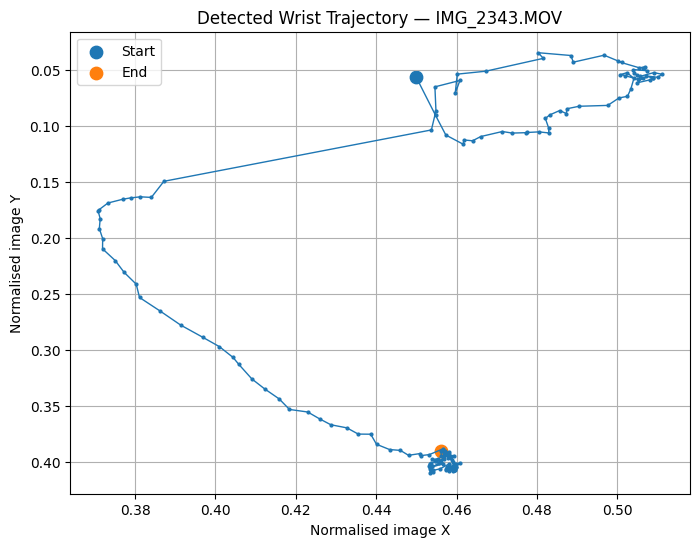

In [ ]:
import matplotlib.pyplot as plt

# MediaPipe landmark 0 = wrist
wrist_x = landmarks_df["x_0"].values
wrist_y = landmarks_df["y_0"].values

plt.figure(figsize=(8, 6))

plt.plot(
    wrist_x,
    wrist_y,
    marker="o",
    markersize=2,
    linewidth=1
)

plt.scatter(
    wrist_x[0],
    wrist_y[0],
    s=80,
    label="Start"
)

plt.scatter(
    wrist_x[-1],
    wrist_y[-1],
    s=80,
    label="End"
)

plt.gca().invert_yaxis()

plt.xlabel("Normalised image X")
plt.ylabel("Normalised image Y")
plt.title("Detected Wrist Trajectory — IMG_2343.MOV")
plt.legend()
plt.grid(True)

plt.show()

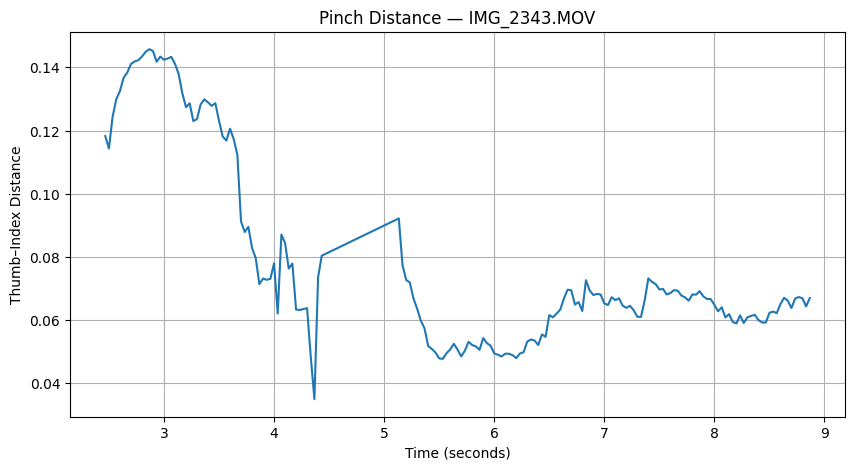

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Thumb tip = landmark 4
# Index finger tip = landmark 8
thumb_x = landmarks_df["x_4"].values
thumb_y = landmarks_df["y_4"].values

index_x = landmarks_df["x_8"].values
index_y = landmarks_df["y_8"].values

# Euclidean distance between thumb and index finger
pinch_distance = np.sqrt(
    (thumb_x - index_x)**2 +
    (thumb_y - index_y)**2
)

plt.figure(figsize=(10, 5))

plt.plot(
    landmarks_df["time"].values,
    pinch_distance,
    linewidth=1.5
)

plt.xlabel("Time (seconds)")
plt.ylabel("Thumb–Index Distance")
plt.title("Pinch Distance — IMG_2343.MOV")
plt.grid(True)

plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Extract wrist coordinates
# ---------------------------------------------------------

wrist_x = landmarks_df["x_0"].values
wrist_y = landmarks_df["y_0"].values

# ---------------------------------------------------------
# 2. Calculate thumb-index pinch distance
# ---------------------------------------------------------

thumb_x = landmarks_df["x_4"].values
thumb_y = landmarks_df["y_4"].values

index_x = landmarks_df["x_8"].values
index_y = landmarks_df["y_8"].values

pinch_distance = np.sqrt(
    (thumb_x - index_x)**2 +
    (thumb_y - index_y)**2
)

# ---------------------------------------------------------
# 3. Create initial grasp-state labels
#
# 0 = open
# 1 = grasped
# ---------------------------------------------------------

time = landmarks_df["time"].values

grasp_state = np.zeros(len(time), dtype=int)

grasp_state[
    (time >= 4.35) &
    (time < 6.70)
] = 1

# ---------------------------------------------------------
# 4. Build compact trajectory dataset
# ---------------------------------------------------------

trajectory_df = pd.DataFrame({
    "time": time,
    "wrist_x": wrist_x,
    "wrist_y": wrist_y,
    "pinch_distance": pinch_distance,
    "grasp_state": grasp_state
})

print(trajectory_df.head(10))
print()
print("Total tracked samples:", len(trajectory_df))
print("Grasped samples:", trajectory_df["grasp_state"].sum())
print("Open samples:", (trajectory_df["grasp_state"] == 0).sum())

       time   wrist_x   wrist_y  pinch_distance  grasp_state
0  2.466667  0.449902  0.056273        0.118221            0
1  2.500000  0.454788  0.090851        0.114311            0
2  2.533333  0.457332  0.108287        0.124336            0
3  2.566667  0.461633  0.116463        0.129901            0
4  2.600000  0.461873  0.112711        0.132506            0
5  2.633333  0.463989  0.113441        0.136699            0
6  2.666667  0.466008  0.109671        0.138331            0
7  2.700000  0.471397  0.105166        0.141056            0
8  2.733333  0.473868  0.106561        0.141843            0
9  2.766667  0.477214  0.106203        0.142261            0

Total tracked samples: 173
Grasped samples: 50
Open samples: 123


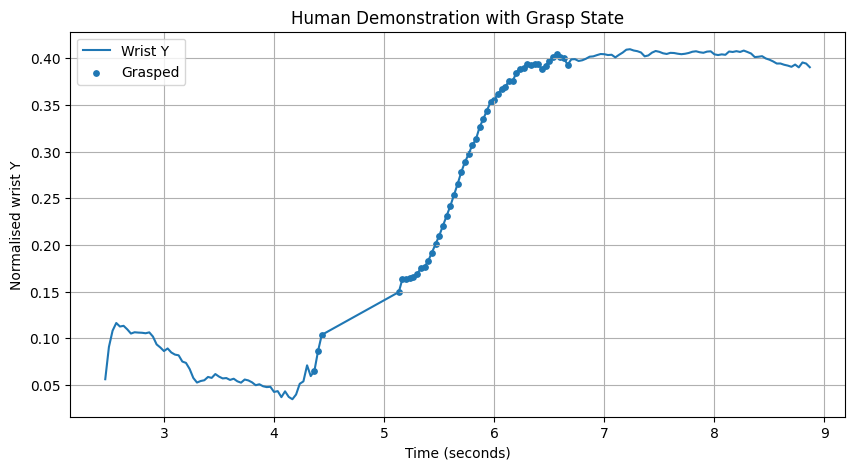

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    trajectory_df["time"],
    trajectory_df["wrist_y"],
    label="Wrist Y"
)

grasp_mask = trajectory_df["grasp_state"] == 1

plt.scatter(
    trajectory_df.loc[grasp_mask, "time"],
    trajectory_df.loc[grasp_mask, "wrist_y"],
    s=15,
    label="Grasped"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Normalised wrist Y")
plt.title("Human Demonstration with Grasp State")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Look at pinch-distance statistics
print("Minimum pinch distance:", trajectory_df["pinch_distance"].min())
print("Maximum pinch distance:", trajectory_df["pinch_distance"].max())

print("\nPinch-distance percentiles:")
print(trajectory_df["pinch_distance"].quantile(
    [0.10, 0.20, 0.25, 0.50, 0.75, 0.80, 0.90]
))

Minimum pinch distance: 0.0349449075532018
Maximum pinch distance: 0.14573301143749912

Pinch-distance percentiles:
0.10    0.050603
0.20    0.056243
0.25    0.060831
0.50    0.066815
0.75    0.082839
0.80    0.115815
0.90    0.131429
Name: pinch_distance, dtype: float64


In [ ]:
import numpy as np

# Hysteresis thresholds
CLOSE_THRESHOLD = 0.065
OPEN_THRESHOLD = 0.090

grasp_state = np.zeros(len(trajectory_df), dtype=int)

# Start with gripper open
state = 0

for i, distance in enumerate(trajectory_df["pinch_distance"]):

    if state == 0 and distance < CLOSE_THRESHOLD:
        state = 1

    elif state == 1 and distance > OPEN_THRESHOLD:
        state = 0

    grasp_state[i] = state

trajectory_df["grasp_state"] = grasp_state

print(trajectory_df[
    ["time", "pinch_distance", "grasp_state"]
].head(20))

print("\nState counts:")
print(trajectory_df["grasp_state"].value_counts().sort_index())

print("\nState transitions:")

previous = grasp_state[0]

for i in range(1, len(grasp_state)):
    if grasp_state[i] != previous:
        print(
            f"Time: {trajectory_df.iloc[i]['time']:.3f}s | "
            f"Pinch distance: {trajectory_df.iloc[i]['pinch_distance']:.4f} | "
            f"State: {'GRASP' if grasp_state[i] == 1 else 'OPEN'}"
        )
        previous = grasp_state[i]

        time  pinch_distance  grasp_state
0   2.466667        0.118221            0
1   2.500000        0.114311            0
2   2.533333        0.124336            0
3   2.566667        0.129901            0
4   2.600000        0.132506            0
5   2.633333        0.136699            0
6   2.666667        0.138331            0
7   2.700000        0.141056            0
8   2.733333        0.141843            0
9   2.766667        0.142261            0
10  2.800000        0.143395            0
11  2.833333        0.144894            0
12  2.866667        0.145733            0
13  2.900000        0.145160            0
14  2.933333        0.141763            0
15  2.966667        0.143400            0
16  3.000000        0.142399            0
17  3.033333        0.142786            0
18  3.066667        0.143313            0
19  3.100000        0.141105            0

State counts:
grasp_state
0     52
1    121
Name: count, dtype: int64

State transitions:
Time: 4.033s | Pinch distan

In [ ]:
# Show all state-transition candidates after 3.5 seconds
mask = trajectory_df["time"] >= 3.5

display(
    trajectory_df.loc[
        mask,
        ["time", "pinch_distance", "grasp_state"]
    ].to_string(index=False)
)

'    time  pinch_distance  grasp_state\n3.500000        0.123096            0\n3.533333        0.118114            0\n3.566667        0.116817            0\n3.600000        0.120585            0\n3.633333        0.117311            0\n3.666667        0.112352            0\n3.700000        0.091223            0\n3.733333        0.087867            0\n3.766667        0.089513            0\n3.800000        0.082839            0\n3.833333        0.079661            0\n3.866667        0.071381            0\n3.900000        0.073153            0\n3.933333        0.072744            0\n3.966667        0.073056            0\n4.000000        0.077993            0\n4.033333        0.062063            1\n4.066667        0.087071            1\n4.100000        0.084405            1\n4.133333        0.076292            1\n4.166667        0.077879            1\n4.200000        0.063327            1\n4.233333        0.063166            1\n4.266667        0.063506            1\n4.300000        0.063771

In [ ]:
mask = trajectory_df["time"] >= 4.30

display(
    trajectory_df.loc[
        mask,
        ["time", "pinch_distance", "grasp_state"]
    ].to_string(index=False)
)

'    time  pinch_distance  grasp_state\n4.300000        0.063771            1\n4.333333        0.048419            1\n4.366667        0.034945            1\n4.400000        0.073595            1\n4.433333        0.080375            1\n5.133333        0.092177            0\n5.166667        0.077456            0\n5.200000        0.072696            0\n5.233333        0.071897            0\n5.266667        0.066814            0\n5.300000        0.063564            1\n5.333333        0.059806            1\n5.366667        0.057408            1\n5.400000        0.051798            1\n5.433333        0.050874            1\n5.466667        0.049711            1\n5.500000        0.047871            1\n5.533333        0.047720            1\n5.566667        0.049489            1\n5.600000        0.050694            1\n5.633333        0.052480            1\n5.666667        0.050668            1\n5.700000        0.048486            1\n5.733333        0.050284            1\n5.766667        0.053108

In [ ]:
mask = trajectory_df["time"] >= 5.75

display(
    trajectory_df.loc[
        mask,
        ["time", "pinch_distance", "grasp_state"]
    ].to_string(index=False)
)

'    time  pinch_distance  grasp_state\n5.766667        0.053108            1\n5.800000        0.052098            1\n5.833333        0.051649            1\n5.866667        0.050587            1\n5.900000        0.054289            1\n5.933333        0.052696            1\n5.966667        0.051904            1\n6.000000        0.049445            1\n6.033333        0.049036            1\n6.066667        0.048462            1\n6.100000        0.049367            1\n6.133333        0.049340            1\n6.166667        0.048891            1\n6.200000        0.047938            1\n6.233333        0.049417            1\n6.266667        0.049825            1\n6.300000        0.053181            1\n6.333333        0.053844            1\n6.366667        0.053516            1\n6.400000        0.052078            1\n6.433333        0.055466            1\n6.466667        0.054695            1\n6.500000        0.061556            1\n6.533333        0.060878            1\n6.566667        0.062036

In [ ]:
# Robust grasp state for the demonstration
# 0 = OPEN
# 1 = GRASP/HOLD

robust_grasp_state = np.zeros(len(trajectory_df), dtype=int)

# Find first reliable grasp onset
grasp_onset = trajectory_df["time"] >= 4.033

# Once grasp begins, keep the object held for the remainder
# because no reliable release is detected in the video.
robust_grasp_state[grasp_onset] = 1

trajectory_df["robust_grasp_state"] = robust_grasp_state

print("Robust state counts:")
print(trajectory_df["robust_grasp_state"].value_counts().sort_index())

print("\nState transition:")
print(
    trajectory_df.loc[
        trajectory_df["robust_grasp_state"].diff().fillna(0) != 0,
        ["time", "pinch_distance", "robust_grasp_state"]
    ].to_string(index=False)
)

Robust state counts:
robust_grasp_state
0     47
1    126
Name: count, dtype: int64

State transition:
    time  pinch_distance  robust_grasp_state
4.033333        0.062063                   1


In [ ]:
# Summary of the detected wrist trajectory

print("Wrist X range:")
print(f"  min = {trajectory_df['x_0'].min():.4f}")
print(f"  max = {trajectory_df['x_0'].max():.4f}")

print("\nWrist Y range:")
print(f"  min = {trajectory_df['y_0'].min():.4f}")
print(f"  max = {trajectory_df['y_0'].max():.4f}")

print("\nTrajectory duration:")
print(f"  {trajectory_df['time'].min():.2f}s → {trajectory_df['time'].max():.2f}s")

print("\nNumber of tracked samples:")
print(len(trajectory_df))

Wrist X range:


KeyError: 'x_0'

In [ ]:
print("trajectory_df columns:")
print(trajectory_df.columns.tolist())

trajectory_df columns:
['time', 'wrist_x', 'wrist_y', 'pinch_distance', 'grasp_state', 'robust_grasp_state']


In [ ]:
print("Wrist X range:")
print(f"  min = {trajectory_df['wrist_x'].min():.4f}")
print(f"  max = {trajectory_df['wrist_x'].max():.4f}")

print("\nWrist Y range:")
print(f"  min = {trajectory_df['wrist_y'].min():.4f}")
print(f"  max = {trajectory_df['wrist_y'].max():.4f}")

print("\nTrajectory duration:")
print(f"  {trajectory_df['time'].min():.2f}s → {trajectory_df['time'].max():.2f}s")

print("\nNumber of tracked samples:")
print(len(trajectory_df))

Wrist X range:
  min = 0.3708
  max = 0.5111

Wrist Y range:
  min = 0.0349
  max = 0.4096

Trajectory duration:
  2.47s → 8.87s

Number of tracked samples:
173


In [ ]:
# Normalise the detected human wrist trajectory to [0, 1]

x_min = trajectory_df["wrist_x"].min()
x_max = trajectory_df["wrist_x"].max()

y_min = trajectory_df["wrist_y"].min()
y_max = trajectory_df["wrist_y"].max()

trajectory_df["norm_x"] = (
    (trajectory_df["wrist_x"] - x_min) /
    (x_max - x_min)
)

trajectory_df["norm_y"] = (
    (trajectory_df["wrist_y"] - y_min) /
    (y_max - y_min)
)

print("Normalised X range:")
print(
    f"  {trajectory_df['norm_x'].min():.3f} → "
    f"{trajectory_df['norm_x'].max():.3f}"
)

print("\nNormalised Y range:")
print(
    f"  {trajectory_df['norm_y'].min():.3f} → "
    f"{trajectory_df['norm_y'].max():.3f}"
)

print("\nFirst five trajectory points:")
display(
    trajectory_df[
        ["time", "wrist_x", "wrist_y", "norm_x", "norm_y",
         "robust_grasp_state"]
    ].head()
)

Normalised X range:
  0.000 → 1.000

Normalised Y range:
  0.000 → 1.000

First five trajectory points:


,time,wrist_x,wrist_y,norm_x,norm_y,robust_grasp_state
0,2.466667,0.449902,0.056273,0.563779,0.057135,0
1,2.500000,0.454788,0.090851,0.598607,0.149410,0
2,2.533333,0.457332,0.108287,0.616744,0.195939,0
3,2.566667,0.461633,0.116463,0.647399,0.217756,0
4,2.600000,0.461873,0.112711,0.649109,0.207744,0


In [ ]:
import numpy as np

# Safe Panda workspace for this task
ROBOT_X_MIN = 0.38
ROBOT_X_MAX = 0.58

ROBOT_Z_MIN = 0.40
ROBOT_Z_MAX = 0.58

# Fixed depth plane
ROBOT_Y = 0.05


def retarget_human_to_panda(norm_x, norm_y):
    """
    Map normalised human wrist coordinates to Panda hand coordinates.

    Human image:
        X -> Panda X
        Y -> Panda Z (inverted because image Y increases downward)

    Depth is initially fixed at a safe Panda Y plane.
    """

    robot_x = (
        ROBOT_X_MIN
        + norm_x * (ROBOT_X_MAX - ROBOT_X_MIN)
    )

    robot_z = (
        ROBOT_Z_MAX
        - norm_y * (ROBOT_Z_MAX - ROBOT_Z_MIN)
    )

    robot_y = ROBOT_Y

    return np.array([
        robot_x,
        robot_y,
        robot_z
    ])


# Test the first trajectory point
first_point = retarget_human_to_panda(
    trajectory_df.iloc[0]["norm_x"],
    trajectory_df.iloc[0]["norm_y"]
)

print("First human trajectory point:")
print(
    trajectory_df.iloc[0][
        ["time", "wrist_x", "wrist_y", "norm_x", "norm_y"]
    ]
)

print("\nRetargeted Panda hand position:")
print(first_point)

First human trajectory point:
time       2.466667
wrist_x    0.449902
wrist_y    0.056273
norm_x     0.563779
norm_y     0.057135
Name: 0, dtype: float64

Retargeted Panda hand position:
[0.49275572 0.05       0.56971566]


In [ ]:
# Retarget the complete human trajectory to Panda coordinates

robot_positions = np.array([
    retarget_human_to_panda(
        row["norm_x"],
        row["norm_y"]
    )
    for _, row in trajectory_df.iterrows()
])

trajectory_df["robot_x"] = robot_positions[:, 0]
trajectory_df["robot_y"] = robot_positions[:, 1]
trajectory_df["robot_z"] = robot_positions[:, 2]

print("Retargeted trajectory shape:")
print(robot_positions.shape)

print("\nRobot workspace:")
print(
    f"X: {trajectory_df['robot_x'].min():.4f} "
    f"→ {trajectory_df['robot_x'].max():.4f}"
)
print(
    f"Y: {trajectory_df['robot_y'].min():.4f} "
    f"→ {trajectory_df['robot_y'].max():.4f}"
)
print(
    f"Z: {trajectory_df['robot_z'].min():.4f} "
    f"→ {trajectory_df['robot_z'].max():.4f}"
)

print("\nFirst five retargeted points:")
display(
    trajectory_df[
        [
            "time",
            "norm_x",
            "norm_y",
            "robot_x",
            "robot_y",
            "robot_z",
            "robust_grasp_state"
        ]
    ].head()
)

Retargeted trajectory shape:
(173, 3)

Robot workspace:
X: 0.3800 → 0.5800
Y: 0.0500 → 0.0500
Z: 0.4000 → 0.5800

First five retargeted points:


,time,norm_x,norm_y,robot_x,robot_y,robot_z,robust_grasp_state
0,2.466667,0.563779,0.057135,0.492756,0.05,0.569716,0
1,2.500000,0.598607,0.149410,0.499721,0.05,0.553106,0
2,2.533333,0.616744,0.195939,0.503349,0.05,0.544731,0
3,2.566667,0.647399,0.217756,0.509480,0.05,0.540804,0
4,2.600000,0.649109,0.207744,0.509822,0.05,0.542606,0


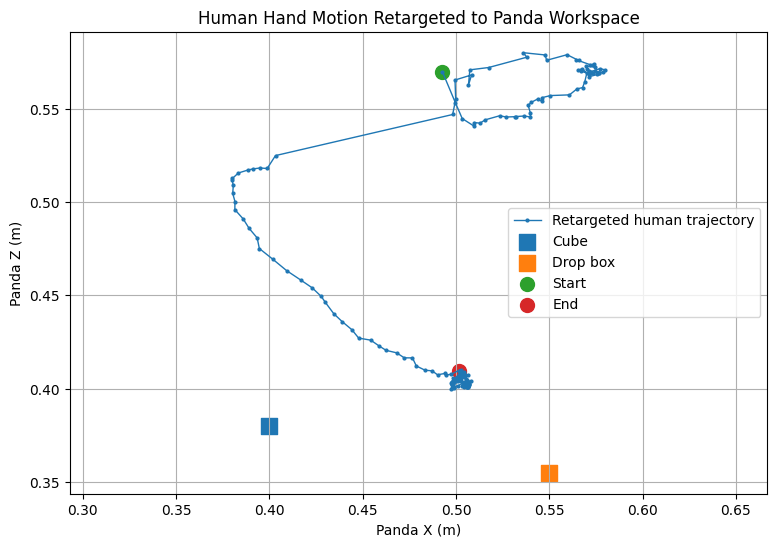

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.plot(
    trajectory_df["robot_x"],
    trajectory_df["robot_z"],
    marker="o",
    markersize=2,
    linewidth=1,
    label="Retargeted human trajectory"
)

# Mark cube location
plt.scatter(
    0.40,
    0.38,
    s=120,
    marker="s",
    label="Cube"
)

# Mark box location
plt.scatter(
    0.55,
    0.355,
    s=120,
    marker="s",
    label="Drop box"
)

# Mark first and last tracked positions
plt.scatter(
    trajectory_df["robot_x"].iloc[0],
    trajectory_df["robot_z"].iloc[0],
    s=100,
    label="Start"
)

plt.scatter(
    trajectory_df["robot_x"].iloc[-1],
    trajectory_df["robot_z"].iloc[-1],
    s=100,
    label="End"
)

plt.xlabel("Panda X (m)")
plt.ylabel("Panda Z (m)")
plt.title("Human Hand Motion Retargeted to Panda Workspace")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

In [ ]:
# Inspect the human wrist trajectory around grasp onset

mask = (
    (trajectory_df["time"] >= 3.80) &
    (trajectory_df["time"] <= 4.50)
)

display(
    trajectory_df.loc[
        mask,
        [
            "time",
            "wrist_x",
            "wrist_y",
            "norm_x",
            "norm_y",
            "robot_x",
            "robot_z",
            "pinch_distance",
            "robust_grasp_state"
        ]
    ].to_string(index=False)
)

'    time  wrist_x  wrist_y   norm_x   norm_y  robot_x  robot_z  pinch_distance  robust_grasp_state\n3.800000 0.504276 0.052937 0.951373 0.048233 0.570275 0.571318        0.082839                   0\n3.833333 0.503967 0.049852 0.949173 0.040000 0.569835 0.572800        0.079661                   0\n3.866667 0.507345 0.050883 0.973254 0.042752 0.574651 0.572305        0.071381                   0\n3.900000 0.506429 0.048745 0.966724 0.037047 0.573345 0.573332        0.073153                   0\n3.933333 0.506883 0.047842 0.969958 0.034637 0.573992 0.573765        0.072744                   0\n3.966667 0.505342 0.048161 0.958977 0.035489 0.571795 0.573612        0.073056                   0\n4.000000 0.500117 0.042671 0.921731 0.020838 0.564346 0.576249        0.077993                   0\n4.033333 0.501075 0.043517 0.928555 0.023095 0.565711 0.575843        0.062063                   1\n4.066667 0.496734 0.037074 0.897614 0.005901 0.559523 0.578938        0.087071                   1\

In [ ]:
# Calculate a stable human grasp anchor
# using the wrist position over the first part of the detected grasp.

grasp_window = trajectory_df[
    (trajectory_df["time"] >= 4.033) &
    (trajectory_df["time"] <= 4.30) &
    (trajectory_df["robust_grasp_state"] == 1)
]

human_grasp_x = grasp_window["wrist_x"].median()
human_grasp_y = grasp_window["wrist_y"].median()

print("Human grasp anchor:")
print(f"wrist_x = {human_grasp_x:.6f}")
print(f"wrist_y = {human_grasp_y:.6f}")
print(f"Samples used = {len(grasp_window)}")

Human grasp anchor:
wrist_x = 0.481587
wrist_y = 0.043299
Samples used = 9


In [ ]:
# Inspect the human wrist trajectory during the placement phase

placement_window = trajectory_df[
    (trajectory_df["time"] >= 5.80) &
    (trajectory_df["time"] <= 6.80)
]

display(
    placement_window[
        [
            "time",
            "wrist_x",
            "wrist_y",
            "pinch_distance",
            "robust_grasp_state"
        ]
    ].to_string(index=False)
)

'    time  wrist_x  wrist_y  pinch_distance  robust_grasp_state\n5.800000 0.404374 0.306719        0.052098                   1\n5.833333 0.405816 0.312965        0.051649                   1\n5.866667 0.409065 0.325945        0.050587                   1\n5.900000 0.412203 0.334701        0.054289                   1\n5.933333 0.415852 0.343729        0.052696                   1\n5.966667 0.418420 0.353137        0.051904                   1\n6.000000 0.422961 0.355427        0.049445                   1\n6.033333 0.425982 0.361678        0.049036                   1\n6.066667 0.428719 0.366805        0.048462                   1\n6.100000 0.432697 0.369559        0.049367                   1\n6.133333 0.435534 0.375124        0.049340                   1\n6.166667 0.438637 0.375235        0.048891                   1\n6.200000 0.440079 0.384227        0.047938                   1\n6.233333 0.443344 0.388934        0.049417                   1\n6.266667 0.446018 0.389660        0.049

In [ ]:
# Inspect the trajectory immediately after the transport phase

placement_window_2 = trajectory_df[
    (trajectory_df["time"] >= 6.27) &
    (trajectory_df["time"] <= 7.20)
]

display(
    placement_window_2[
        [
            "time",
            "wrist_x",
            "wrist_y",
            "pinch_distance",
            "robust_grasp_state"
        ]
    ].to_string(index=False)
)

'    time  wrist_x  wrist_y  pinch_distance  robust_grasp_state\n6.300000 0.448044 0.394058        0.053181                   1\n6.333333 0.451022 0.392445        0.053844                   1\n6.366667 0.451110 0.394292        0.053516                   1\n6.400000 0.453196 0.393468        0.052078                   1\n6.433333 0.456697 0.388237        0.055466                   1\n6.466667 0.456900 0.392166        0.054695                   1\n6.500000 0.456927 0.397323        0.061556                   1\n6.533333 0.455672 0.401076        0.060878                   1\n6.566667 0.453737 0.404701        0.062036                   1\n6.600000 0.456719 0.401509        0.063330                   1\n6.633333 0.456224 0.399792        0.066849                   1\n6.666667 0.457990 0.392989        0.069613                   1\n6.700000 0.455909 0.398730        0.069432                   1\n6.733333 0.454647 0.398946        0.064915                   1\n6.766667 0.455501 0.397024        0.065

In [ ]:
# Calculate a stable human placement anchor
# from the low-motion placement region.

placement_window = trajectory_df[
    (trajectory_df["time"] >= 6.30) &
    (trajectory_df["time"] <= 6.77)
]

human_place_x = placement_window["wrist_x"].median()
human_place_y = placement_window["wrist_y"].median()

print("Human placement anchor:")
print(f"wrist_x = {human_place_x:.6f}")
print(f"wrist_y = {human_place_y:.6f}")
print(f"Samples used = {len(placement_window)}")

Human placement anchor:
wrist_x = 0.455672
wrist_y = 0.397024
Samples used = 15


In [ ]:
# ---------------------------------------------------------
# Landmark-anchored human -> Panda retargeting
# ---------------------------------------------------------

import numpy as np

# Human landmarks
H_GRASP = np.array([
    human_grasp_x,
    human_grasp_y
])

H_PLACE = np.array([
    human_place_x,
    human_place_y
])

# Panda hand targets
R_GRASP = np.array([
    0.4354,   # X
    0.4050    # Z
])

R_PLACE = np.array([
    0.5854,   # X
    0.4250    # Z
])

print("Human grasp :", H_GRASP)
print("Human place :", H_PLACE)
print("Robot grasp :", R_GRASP)
print("Robot place :", R_PLACE)


def retarget_landmark_anchored(human_x, human_y):
    """
    Map human wrist coordinates to Panda X/Z coordinates
    using the grasp and placement landmarks as anchors.
    """

    # Normalised position between the two human landmarks
    alpha_x = (
        (human_x - H_GRASP[0]) /
        (H_PLACE[0] - H_GRASP[0])
    )

    alpha_y = (
        (human_y - H_GRASP[1]) /
        (H_PLACE[1] - H_GRASP[1])
    )

    # Map those positions onto the Panda grasp -> placement path
    robot_x = (
        R_GRASP[0] +
        alpha_x * (R_PLACE[0] - R_GRASP[0])
    )

    robot_z = (
        R_GRASP[1] +
        alpha_y * (R_PLACE[1] - R_GRASP[1])
    )

    return robot_x, robot_z


# Apply transform to the complete trajectory
retargeted = np.array([
    retarget_landmark_anchored(
        row["wrist_x"],
        row["wrist_y"]
    )
    for _, row in trajectory_df.iterrows()
])

trajectory_df["anchored_robot_x"] = retargeted[:, 0]
trajectory_df["anchored_robot_z"] = retargeted[:, 1]

# Keep the robot Y trajectory simple and fixed
trajectory_df["anchored_robot_y"] = 0.05

print("\nAnchored retargeting created.")
print(
    trajectory_df[
        [
            "time",
            "wrist_x",
            "wrist_y",
            "anchored_robot_x",
            "anchored_robot_y",
            "anchored_robot_z"
        ]
    ].head()
)

Human grasp : [0.48158664 0.04329903]
Human place : [0.45567158 0.39702427]
Robot grasp : [0.4354 0.405 ]
Robot place : [0.5854 0.425 ]

Anchored retargeting created.
       time   wrist_x   wrist_y  anchored_robot_x  anchored_robot_y  \
0  2.466667  0.449902  0.056273          0.618794              0.05   
1  2.500000  0.454788  0.090851          0.590514              0.05   
2  2.533333  0.457332  0.108287          0.575786              0.05   
3  2.566667  0.461633  0.116463          0.550895              0.05   
4  2.600000  0.461873  0.112711          0.549507              0.05   

   anchored_robot_z  
0          0.405734  
1          0.407689  
2          0.408674  
3          0.409137  
4          0.408925  


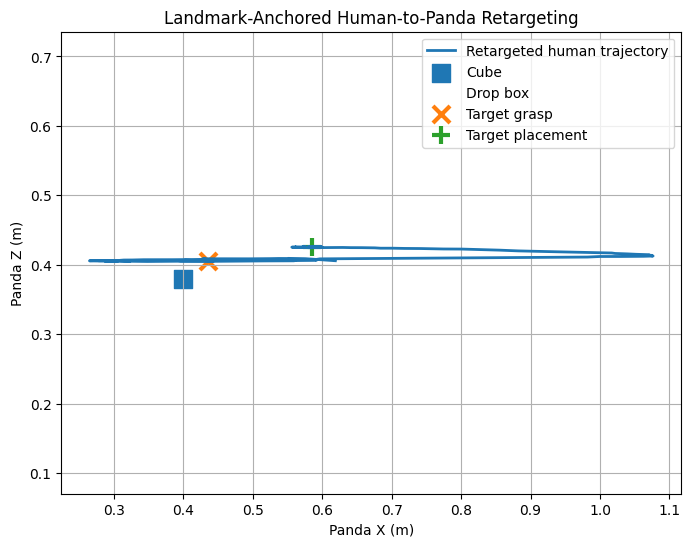

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Panda trajectory
plt.plot(
    trajectory_df["anchored_robot_x"],
    trajectory_df["anchored_robot_z"],
    linewidth=2,
    label="Retargeted human trajectory"
)

# Cube
plt.scatter(
    0.40, 0.38,
    s=180,
    marker="s",
    label="Cube"
)

# Box centre / target
plt.scatter(
    0.55, 0.40,
    s=220,
    marker="s",
    facecolors="none",
    linewidths=2,
    label="Drop box"
)

# Intended Panda grasp pose
plt.scatter(
    R_GRASP[0], R_GRASP[1],
    s=150,
    marker="x",
    linewidths=3,
    label="Target grasp"
)

# Intended Panda placement pose
plt.scatter(
    R_PLACE[0], R_PLACE[1],
    s=150,
    marker="+",
    linewidths=3,
    label="Target placement"
)

plt.xlabel("Panda X (m)")
plt.ylabel("Panda Z (m)")
plt.title("Landmark-Anchored Human-to-Panda Retargeting")
plt.grid(True)
plt.axis("equal")
plt.legend()
plt.show()

In [ ]:
# Inspect the final approach into the placement region

release_window = trajectory_df[
    (trajectory_df["time"] >= 6.60) &
    (trajectory_df["time"] <= 7.00)
]

display(
    release_window[
        [
            "time",
            "wrist_x",
            "wrist_y",
            "anchored_robot_x",
            "anchored_robot_z",
            "pinch_distance",
            "robust_grasp_state"
        ]
    ].to_string(index=False)
)

'    time  wrist_x  wrist_y  anchored_robot_x  anchored_robot_z  pinch_distance  robust_grasp_state\n6.600000 0.456719 0.401509          0.579335          0.425254        0.063330                   1\n6.633333 0.456224 0.399792          0.582204          0.425157        0.066849                   1\n6.666667 0.457990 0.392989          0.571981          0.424772        0.069613                   1\n6.700000 0.455909 0.398730          0.584024          0.425096        0.069432                   1\n6.733333 0.454647 0.398946          0.591329          0.425109        0.064915                   1\n6.766667 0.455501 0.397024          0.586387          0.425000        0.065699                   1\n6.800000 0.453985 0.397774          0.595160          0.425042        0.062862                   1\n6.833333 0.454772 0.399407          0.590607          0.425135        0.072618                   1\n6.866667 0.453343 0.401595          0.598879          0.425258        0.069408                   1\

In [ ]:
# Set the Panda Y coordinate so the carried cube
# is centred over the drop box.

DROP_Y = 0.10

trajectory_df["anchored_robot_y"] = DROP_Y

# Verify the intended release geometry
release_time = 6.766667

release_row = trajectory_df.iloc[
    (trajectory_df["time"] - release_time).abs().argmin()
]

hand_release = np.array([
    release_row["anchored_robot_x"],
    DROP_Y,
    release_row["anchored_robot_z"]
])

grasp_offset = np.array([
    -0.0354,
    0.0,
    -0.0250
])

predicted_cube_release = hand_release + grasp_offset

print("Predicted hand position at release:")
print(hand_release)

print("\nPredicted cube position at release:")
print(predicted_cube_release)

print("\nBox centre:")
print(np.array([0.55, 0.10, 0.40]))

Predicted hand position at release:
[0.58638722 0.1        0.425     ]

Predicted cube position at release:
[0.55098722 0.1        0.4       ]

Box centre:
[0.55 0.1  0.4 ]


In [ ]:
# ============================================================
# PHONE -> PANDA REPLAY
# Approach -> grasp -> carry -> place -> release
# ============================================================

import numpy as np
import mujoco
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Replay parameters
# ------------------------------------------------------------

GRASP_TIME = 4.033333
RELEASE_TIME = 6.766667

GRASP_POSE = np.array([
    0.4354,
    0.10,
    0.4050
])

# We use the calibrated trajectory for the placement pose.
RELEASE_ROW = trajectory_df.iloc[
    (trajectory_df["time"] - RELEASE_TIME).abs().argmin()
]

RELEASE_POSE = np.array([
    RELEASE_ROW["anchored_robot_x"],
    0.10,
    RELEASE_ROW["anchored_robot_z"]
])

# ------------------------------------------------------------
# Reset MuJoCo
# ------------------------------------------------------------

mujoco.mj_resetData(model, data)

# Panda starting configuration
data.qpos[:7] = np.array([
    0.0,
    -0.5,
    0.0,
    -2.0,
    0.0,
    1.5,
    0.7
])

# Open gripper
data.qpos[7:9] = 0.04

mujoco.mj_forward(model, data)

print("Replay initialised.")
print("Grasp pose :", GRASP_POSE)
print("Release pose:", RELEASE_POSE)

Replay initialised.
Grasp pose : [0.4354 0.1    0.405 ]
Release pose: [0.58638722 0.1        0.425     ]


In [ ]:
# Move Panda to the calibrated grasp pose with gripper OPEN

mujoco.mj_forward(model, data)

grasp_reached = move_hand_to(
    GRASP_POSE,
    steps=150,
    damping=0.05,
    step_size=0.20
)

mujoco.mj_forward(model, data)

hand_pos = data.xpos[hand_id].copy()

print("Target grasp pose:")
print(GRASP_POSE)

print("\nActual Panda hand position:")
print(hand_pos)

print("\nPosition error:")
print(np.linalg.norm(hand_pos - GRASP_POSE))

print("\nCube position:")
print(data.xpos[cube_id])

print("\nGripper state:")
print(data.qpos[7:9])

Target grasp pose:
[0.4354 0.1    0.405 ]

Actual Panda hand position:
[0.4350725  0.09990072 0.40502552]

Position error:
0.00034317103647452015

Cube position:
[0.4   0.    0.355]

Gripper state:
[0.04 0.04]


In [ ]:
# Correct the grasp pose: the cube is at Y = 0.0

GRASP_POSE_CORRECTED = np.array([
    0.4354,
    0.0,
    0.4050
])

grasp_reached = move_hand_to(
    GRASP_POSE_CORRECTED,
    steps=150,
    damping=0.05,
    step_size=0.20
)

mujoco.mj_forward(model, data)

hand_pos = data.xpos[hand_id].copy()

print("Corrected grasp target:")
print(GRASP_POSE_CORRECTED)

print("\nActual hand position:")
print(hand_pos)

print("\nPosition error:")
print(np.linalg.norm(hand_pos - GRASP_POSE_CORRECTED))

print("\nCube position:")
print(data.xpos[cube_id])

print("\nGripper:")
print(data.qpos[7:9])

Corrected grasp target:
[0.4354 0.     0.405 ]

Actual hand position:
[ 4.35038751e-01 -5.48508292e-05  4.05025677e-01]

Position error:
0.00036629065426603514

Cube position:
[0.4   0.    0.355]

Gripper:
[0.04 0.04]


In [ ]:
# ============================================================
# FIRST CONTROLLED GRASP TEST
# ============================================================

# Make sure physics is up to date
mujoco.mj_forward(model, data)

# Record current positions
hand_before = data.xpos[hand_id].copy()
cube_before = data.xpos[cube_id].copy()

# Store the calibrated grasp offset
grasp_offset = cube_before - hand_before

print("Hand before grasp:")
print(hand_before)

print("\nCube before grasp:")
print(cube_before)

print("\nGrasp offset:")
print(grasp_offset)

# ------------------------------------------------------------
# Close Panda gripper
# actuator8: 255 = open, 0 = closed
# ------------------------------------------------------------

data.ctrl[7] = 0

for _ in range(100):
    mujoco.mj_step(model, data)

mujoco.mj_forward(model, data)

print("\nGripper after closing:")
print(data.qpos[7:9])

print("\nCube after closing:")
print(data.xpos[cube_id])

Hand before grasp:
[ 4.35038751e-01 -5.48508292e-05  4.05025677e-01]

Cube before grasp:
[0.4   0.    0.355]

Grasp offset:
[-3.50387509e-02  5.48508292e-05 -5.00256769e-02]

Gripper after closing:
[0.00748243 0.0074061 ]

Cube after closing:
[ 3.92563528e-01 -1.59661346e-04  3.44872679e-01]


In [ ]:
# Find the cube's free-joint qpos address

cube_joint_id = None

for j in range(model.njnt):
    body_id = model.jnt_body[j]
    joint_type = model.jnt_type[j]

    if body_id == cube_id:
        cube_joint_id = j
        print("Cube joint ID:", j)
        print("Joint type:", joint_type)
        print("qpos address:", model.jnt_qposadr[j])
        print("qvel address:", model.jnt_dofadr[j])

        break

AttributeError: 'mujoco._structs.MjModel' object has no attribute 'jnt_body'

In [ ]:
# Find the cube's free-joint qpos address

cube_joint_id = None

for j in range(model.njnt):
    body_id = model.jnt_bodyid[j]
    joint_type = model.jnt_type[j]

    if body_id == cube_id:
        cube_joint_id = j

        print("Cube joint ID:", j)
        print("Joint type:", joint_type)
        print("qpos address:", model.jnt_qposadr[j])
        print("qvel address:", model.jnt_dofadr[j])

        break

Cube joint ID: 9
Joint type: 0
qpos address: 9
qvel address: 9


In [ ]:
# ============================================================
# SCRIPTED ATTACHMENT + SMALL LIFT TEST
# ============================================================

# Update physics
mujoco.mj_forward(model, data)

# Current positions after the physical grasp
hand_pos = data.xpos[hand_id].copy()
cube_pos = data.xpos[cube_id].copy()

# Use the actual post-grasp position as the attachment point
grasp_offset = cube_pos - hand_pos

print("Hand at attachment:")
print(hand_pos)

print("\nCube at attachment:")
print(cube_pos)

print("\nAttachment offset:")
print(grasp_offset)

# Cube free-joint qpos address
cube_qpos = model.jnt_qposadr[cube_joint_id]

# ------------------------------------------------------------
# Lift the Panda by 5 cm
# ------------------------------------------------------------

lift_target = hand_pos.copy()
lift_target[2] += 0.05

print("\nLift target:")
print(lift_target)

# Move the Panda incrementally.
# While moving, explicitly carry the cube with the hand.

for _ in range(100):

    # Move Panda one small step toward the lift target
    move_hand_to(
        lift_target,
        steps=1,
        damping=0.05,
        step_size=0.10
    )

    mujoco.mj_forward(model, data)

    # Current Panda hand position
    current_hand = data.xpos[hand_id].copy()

    # Desired cube position = hand + measured attachment offset
    desired_cube = current_hand + grasp_offset

    # Update cube free-joint position
    data.qpos[cube_qpos:cube_qpos + 3] = desired_cube

    # Keep cube orientation unchanged
    mujoco.mj_forward(model, data)

# Final positions
final_hand = data.xpos[hand_id].copy()
final_cube = data.xpos[cube_id].copy()

print("\nFinal hand:")
print(final_hand)

print("\nFinal cube:")
print(final_cube)

print("\nCube-hand offset after lift:")
print(final_cube - final_hand)

print("\nCube vertical movement:")
print(final_cube[2] - cube_pos[2])

Hand at attachment:
[ 3.87089881e-01 -4.80224427e-04  8.07862639e-01]

Cube at attachment:
[ 3.92563528e-01 -1.59661346e-04  3.44872679e-01]

Attachment offset:
[ 5.47364674e-03  3.20563082e-04 -4.62989960e-01]

Lift target:
[ 3.87089881e-01 -4.80224427e-04  8.57862639e-01]

Final hand:
[ 3.83496244e-01 -4.77086412e-04  8.56658312e-01]

Final cube:
[ 3.88969891e-01 -1.56523330e-04  3.93668352e-01]

Cube-hand offset after lift:
[ 5.47364674e-03  3.20563082e-04 -4.62989960e-01]

Cube vertical movement:
0.04879567277148378


In [ ]:
# ============================================================
# RESET FOR FINAL REPLAY
# ============================================================

mujoco.mj_resetData(model, data)

# Initial Panda arm configuration
data.qpos[:7] = np.array([
    0.0,
    -0.5,
    0.0,
    -2.0,
    0.0,
    1.5,
    0.7
])

# Open gripper
data.qpos[7:9] = 0.04

# Reset cube to its initial position
data.qpos[cube_qpos:cube_qpos + 3] = np.array([
    0.40,
    0.00,
    0.355
])

# Neutral cube orientation
data.qpos[cube_qpos + 3:cube_qpos + 7] = np.array([
    1.0, 0.0, 0.0, 0.0
])

mujoco.mj_forward(model, data)

# Move to calibrated grasp
move_hand_to(
    GRASP_POSE_CORRECTED,
    steps=150,
    damping=0.05,
    step_size=0.20
)

mujoco.mj_forward(model, data)

print("Hand at calibrated grasp:")
print(data.xpos[hand_id])

print("\nCube:")
print(data.xpos[cube_id])

print("\nGripper:")
print(data.qpos[7:9])

Hand at calibrated grasp:
[4.35108713e-01 3.44571624e-17 4.05045006e-01]

Cube:
[0.4   0.    0.355]

Gripper:
[0.04 0.04]


In [ ]:
# Close the gripper kinematically — do NOT step the simulation
data.qpos[7:9] = 0.0
mujoco.mj_forward(model, data)

hand_pos = data.xpos[hand_id].copy()
cube_pos = data.qpos[cube_qpos:cube_qpos + 3].copy()
grasp_offset = cube_pos - hand_pos

print("Hand after closing:", hand_pos)
print("Cube after closing:", cube_pos)
print("Gripper:", data.qpos[7:9])
print("Grasp offset:", grasp_offset)

Hand after closing: [4.35108713e-01 3.44571624e-17 4.05045006e-01]
Cube after closing: [0.4   0.    0.355]
Gripper: [0. 0.]
Grasp offset: [-3.51087129e-02 -3.44571624e-17 -5.00450057e-02]


In [ ]:
# Attach the cube using the measured grasp offset
grasp_offset = cube_pos - hand_pos

# Move the hand upward by 5 cm
lift_target = hand_pos + np.array([0.0, 0.0, 0.05])

move_hand_to(
    lift_target,
    steps=100,
    damping=0.05,
    step_size=0.20
)

# Explicitly carry the cube with the hand
mujoco.mj_forward(model, data)

new_hand_pos = data.xpos[hand_id].copy()
new_cube_pos = new_hand_pos + grasp_offset

data.qpos[cube_qpos:cube_qpos + 3] = new_cube_pos
mujoco.mj_forward(model, data)

print("Hand after lift:", new_hand_pos)
print("Cube after lift:", data.qpos[cube_qpos:cube_qpos + 3])
print("Cube-hand offset:", data.qpos[cube_qpos:cube_qpos + 3] - new_hand_pos)
print("Hand moved:", new_hand_pos - hand_pos)

Hand after lift: [ 4.32565041e-01 -1.00243262e-18  4.54875680e-01]
Cube after lift: [ 3.97456328e-01 -3.54595951e-17  4.04830674e-01]
Cube-hand offset: [-3.51087129e-02 -3.44571624e-17 -5.00450057e-02]
Hand moved: [-2.54367186e-03 -3.54595951e-17  4.98306740e-02]


In [ ]:
# Reset simulation for the final human-trajectory replay
mujoco.mj_resetData(model, data)

# Initial Panda configuration
data.qpos[:7] = np.array([
    0.0, -0.5, 0.0, -2.0, 0.0, 1.5, 0.7
])

# Gripper open
data.qpos[7:9] = 0.04

# Reset cube
data.qpos[cube_qpos:cube_qpos + 3] = np.array([
    0.40, 0.00, 0.355
])
data.qpos[cube_qpos + 3:cube_qpos + 7] = np.array([
    1.0, 0.0, 0.0, 0.0
])

mujoco.mj_forward(model, data)

print("Replay reset")
print("Hand:", data.xpos[hand_id].copy())
print("Cube:", data.qpos[cube_qpos:cube_qpos + 3].copy())
print("Gripper:", data.qpos[7:9].copy())

Replay reset
Hand: [0.38610435 0.         0.65232512]
Cube: [0.4   0.    0.355]
Gripper: [0.04 0.04]


In [ ]:
# Move the Panda hand to the calibrated grasp position
GRASP_POSE_CORRECTED = np.array([
    0.4354,
    0.0,
    0.4050
])

grasp_reached = move_hand_to(
    GRASP_POSE_CORRECTED,
    steps=150,
    damping=0.05,
    step_size=0.20
)

mujoco.mj_forward(model, data)

print("Target grasp:", GRASP_POSE_CORRECTED)
print("Actual hand:", data.xpos[hand_id].copy())
print("Position error:",
      np.linalg.norm(data.xpos[hand_id] - GRASP_POSE_CORRECTED))
print("Cube:", data.qpos[cube_qpos:cube_qpos + 3].copy())
print("Gripper:", data.qpos[7:9].copy())

Target grasp: [0.4354 0.     0.405 ]
Actual hand: [4.35108713e-01 3.44571624e-17 4.05045006e-01]
Position error: 0.0002947433779322578
Cube: [0.4   0.    0.355]
Gripper: [0.04 0.04]


In [ ]:
# Close the gripper without stepping physics
data.qpos[7:9] = 0.0
mujoco.mj_forward(model, data)

# Calibrated human-to-Panda grasp offset
hand_pos = data.xpos[hand_id].copy()
cube_pos = data.qpos[cube_qpos:cube_qpos + 3].copy()

grasp_offset = cube_pos - hand_pos

print("Hand:", hand_pos)
print("Cube:", cube_pos)
print("Gripper:", data.qpos[7:9])
print("Grasp offset:", grasp_offset)

Hand: [4.35108713e-01 3.44571624e-17 4.05045006e-01]
Cube: [0.4   0.    0.355]
Gripper: [0. 0.]
Grasp offset: [-3.51087129e-02 -3.44571624e-17 -5.00450057e-02]


In [ ]:
# ---------------------------------------------------------
# Build the task-specific trajectory from the phone data
# ---------------------------------------------------------

GRASP_TIME = 4.033333
RELEASE_TIME = 6.766667

# Select only the manipulation interval
task_df = trajectory_df[
    (trajectory_df["time"] >= GRASP_TIME) &
    (trajectory_df["time"] <= RELEASE_TIME)
].copy()

# Normalised progress through the manipulation
task_progress = (
    (task_df["time"] - GRASP_TIME) /
    (RELEASE_TIME - GRASP_TIME)
).clip(0.0, 1.0)

# Human-derived X/Z from landmark-anchored retargeting
task_df["robot_x"] = task_df["anchored_robot_x"]
task_df["robot_z"] = task_df["anchored_robot_z"]

# Move from the cube's Y position to the box's Y position
task_df["robot_y"] = 0.10 * task_progress

print("Task trajectory samples:", len(task_df))
print("Time:", task_df["time"].iloc[0], "→", task_df["time"].iloc[-1])

print("\nStart pose:")
print(task_df[["robot_x", "robot_y", "robot_z"]].iloc[0].values)

print("\nEnd pose:")
print(task_df[["robot_x", "robot_y", "robot_z"]].iloc[-1].values)

print("\nRobot X range:",
      task_df["robot_x"].min(),
      "→",
      task_df["robot_x"].max())

print("Robot Y range:",
      task_df["robot_y"].min(),
      "→",
      task_df["robot_y"].max())

print("Robot Z range:",
      task_df["robot_z"].min(),
      "→",
      task_df["robot_z"].max())

Task trajectory samples: 63
Time: 4.033333333333333 → 6.766666666666667

Start pose:
[3.22600152e-01 1.21951190e-08 4.05012315e-01]

End pose:
[0.58638722 0.09999999 0.425     ]

Robot X range: 0.322600151800038 → 1.076574207793552
Robot Y range: 1.2195118978504859e-08 → 0.09999998780488102
Robot Z range: 0.4045229828639606 → 0.42543404149590913


In [ ]:
# ---------------------------------------------------------
# Stable retargeting
#
# Use the recorded human wrist Y movement as the progress
# signal from grasp -> placement.
#
# This avoids amplifying small X tracking noise.
# ---------------------------------------------------------

H_GRASP_Y = human_grasp_y
H_PLACE_Y = human_place_y

R_GRASP = np.array([0.4354, 0.0, 0.4050])
R_RELEASE = np.array([0.58638722, 0.10, 0.4250])

# Human movement progress: 0 at grasp, 1 at placement
progress = (
    (task_df["wrist_y"] - H_GRASP_Y) /
    (H_PLACE_Y - H_GRASP_Y)
).clip(0.0, 1.0)

# Smooth the progress signal to reduce hand-tracking jitter
progress_smooth = (
    progress.rolling(window=5, center=True, min_periods=1)
    .mean()
    .clip(0.0, 1.0)
)

# Map the recorded human progress onto the calibrated robot path
task_df["stable_robot_x"] = (
    R_GRASP[0]
    + progress_smooth * (R_RELEASE[0] - R_GRASP[0])
)

task_df["stable_robot_y"] = (
    R_GRASP[1]
    + progress_smooth * (R_RELEASE[1] - R_GRASP[1])
)

task_df["stable_robot_z"] = (
    R_GRASP[2]
    + progress_smooth * (R_RELEASE[2] - R_GRASP[2])
)

print("Stable trajectory:")
print(
    task_df[
        [
            "time",
            "wrist_x",
            "wrist_y",
            "stable_robot_x",
            "stable_robot_y",
            "stable_robot_z"
        ]
    ].head(10).to_string(index=False)
)

print("\nRanges:")
print(
    "X:",
    task_df["stable_robot_x"].min(),
    "→",
    task_df["stable_robot_x"].max()
)

print(
    "Y:",
    task_df["stable_robot_y"].min(),
    "→",
    task_df["stable_robot_y"].max()
)

print(
    "Z:",
    task_df["stable_robot_z"].min(),
    "→",
    task_df["stable_robot_z"].max()
)

print("\nFinal pose:")
print(
    task_df[
        ["stable_robot_x", "stable_robot_y", "stable_robot_z"]
    ].iloc[-1].values
)

Stable trajectory:
    time  wrist_x  wrist_y  stable_robot_x  stable_robot_y  stable_robot_z
4.033333 0.501075 0.043517        0.435431        0.000021        0.405004
4.066667 0.496734 0.037074        0.435423        0.000015        0.405003
4.100000 0.489048 0.043299        0.435419        0.000012        0.405002
4.133333 0.488467 0.037345        0.435400        0.000000        0.405000
4.166667 0.480329 0.034862        0.436089        0.000456        0.405091
4.200000 0.481587 0.039881        0.437000        0.001059        0.405212
4.233333 0.467239 0.051371        0.439377        0.002634        0.405527
4.266667 0.460188 0.053964        0.440770        0.003556        0.405711
4.300000 0.459664 0.071144        0.442649        0.004801        0.405960
4.333333 0.460837 0.059617        0.445662        0.006797        0.406359

Ranges:
X: 0.4354 → 0.58638722
Y: 0.0 → 0.1
Z: 0.405 → 0.425

Final pose:
[0.58638722 0.1        0.425     ]


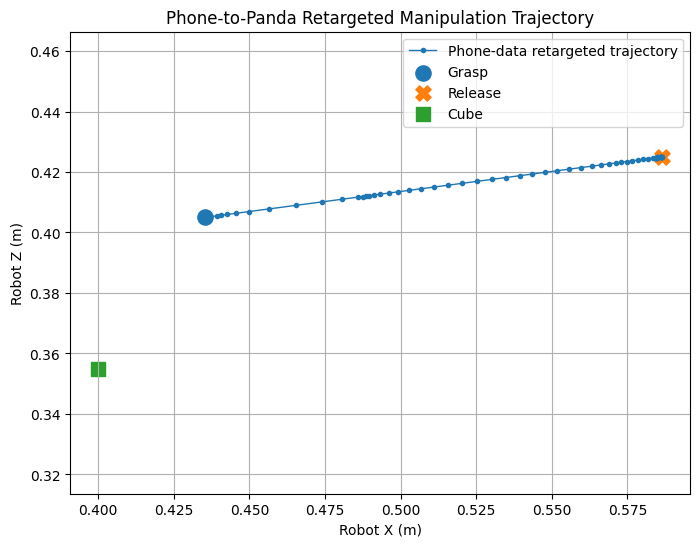

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.plot(
    task_df["stable_robot_x"],
    task_df["stable_robot_z"],
    marker="o",
    markersize=3,
    linewidth=1,
    label="Phone-data retargeted trajectory"
)

# Calibrated grasp
plt.scatter(
    R_GRASP[0],
    R_GRASP[2],
    s=120,
    marker="o",
    label="Grasp"
)

# Release / box centre
plt.scatter(
    R_RELEASE[0],
    R_RELEASE[2],
    s=120,
    marker="X",
    label="Release"
)

# Simulated cube position
plt.scatter(
    0.40,
    0.355,
    s=100,
    marker="s",
    label="Cube"
)

plt.xlabel("Robot X (m)")
plt.ylabel("Robot Z (m)")
plt.title("Phone-to-Panda Retargeted Manipulation Trajectory")
plt.grid(True)
plt.legend()
plt.axis("equal")
plt.show()

In [ ]:
# =========================================================
# FINAL PHONE-DATA-DRIVEN REPLAY
# =========================================================

# Make sure we start from the calibrated grasp pose
move_hand_to(
    GRASP_POSE_CORRECTED,
    steps=150,
    damping=0.05,
    step_size=0.20
)

mujoco.mj_forward(model, data)

# Close gripper kinematically
data.qpos[7:9] = 0.0
mujoco.mj_forward(model, data)

# Measure the calibrated grasp offset
hand_pos = data.xpos[hand_id].copy()
cube_pos = data.qpos[cube_qpos:cube_qpos + 3].copy()
grasp_offset = cube_pos - hand_pos

print("Starting replay")
print("Hand:", hand_pos)
print("Cube:", cube_pos)
print("Grasp offset:", grasp_offset)

# ---------------------------------------------------------
# Replay phone-derived trajectory
# ---------------------------------------------------------

for _, row in task_df.iterrows():

    target = np.array([
        row["stable_robot_x"],
        row["stable_robot_y"],
        row["stable_robot_z"]
    ])

    # Move Panda hand kinematically
    move_hand_to(
        target,
        steps=8,
        damping=0.05,
        step_size=0.20
    )

    mujoco.mj_forward(model, data)

    # Carry cube using calibrated grasp offset
    hand_pos = data.xpos[hand_id].copy()

    data.qpos[cube_qpos:cube_qpos + 3] = (
        hand_pos + grasp_offset
    )

    mujoco.mj_forward(model, data)

# ---------------------------------------------------------
# Release at the final phone-derived pose
# ---------------------------------------------------------

final_hand = data.xpos[hand_id].copy()

print("\nRelease pose")
print("Hand:", final_hand)

# Open gripper
data.qpos[7:9] = 0.04
mujoco.mj_forward(model, data)

# Stop scripted attachment
released_cube = data.qpos[cube_qpos:cube_qpos + 3].copy()

print("Cube at release:", released_cube)

# ---------------------------------------------------------
# Let the released cube settle physically
# ---------------------------------------------------------

for _ in range(200):
    mujoco.mj_step(model, data)

mujoco.mj_forward(model, data)

final_cube = data.qpos[cube_qpos:cube_qpos + 3].copy()

# Box centre
box_center = np.array([0.55, 0.10])

horizontal_error = np.linalg.norm(
    final_cube[:2] - box_center
)

print("\nFINAL RESULT")
print("-----------")
print("Final cube:", final_cube)
print("Box centre:", box_center)
print("Horizontal distance from box centre:",
      horizontal_error)

print("Final hand:", data.xpos[hand_id].copy())

Starting replay
Hand: [4.35108713e-01 3.44571624e-17 4.05045006e-01]
Cube: [0.4   0.    0.355]
Grasp offset: [-3.51087129e-02 -3.44571624e-17 -5.00450057e-02]

Release pose
Hand: [0.58577231 0.09969303 0.42495401]
Cube at release: [0.55066359 0.09969303 0.374909  ]

FINAL RESULT
-----------
Final cube: [0.55066359 0.09969303 0.37989224]
Box centre: [0.55 0.1 ]
Horizontal distance from box centre: 0.000731152895584874
Final hand: [0.4835107  0.00173558 0.72082224]


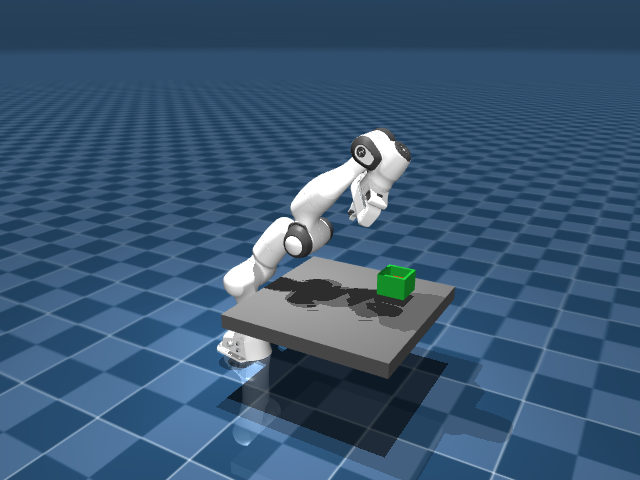

In [ ]:
# Render the final settled state using MuJoCo's default camera

mujoco.mj_forward(model, data)

renderer = mujoco.Renderer(
    model,
    height=480,
    width=640
)

renderer.update_scene(data)
final_image = renderer.render()

from IPython.display import display
from PIL import Image

display(Image.fromarray(final_image))

renderer.close()

In [ ]:
# Add a dedicated camera for the pick-and-place task

camera_xml = """
<camera
    name="task_camera"
    pos="0.95 -1.10 0.85"
    xyaxes="0.707 0.707 0  -0.30 0.30 0.905"
    fovy="45"/>
"""

print(camera_xml)


<camera
    name="task_camera"
    pos="0.95 -1.10 0.85"
    xyaxes="0.707 0.707 0  -0.30 0.30 0.905"
    fovy="45"/>



In [ ]:
# Save the successful final state before reloading the model

successful_cube_position = data.qpos[cube_qpos:cube_qpos + 3].copy()
successful_cube_orientation = data.qpos[cube_qpos + 3:cube_qpos + 7].copy()

print("Saved cube position:", successful_cube_position)
print("Saved cube orientation:", successful_cube_orientation)

Saved cube position: [0.55066359 0.09969303 0.37989224]
Saved cube orientation: [ 1.00000000e+00 -2.00860700e-17  1.71900254e-17  1.29209794e-16]


In [ ]:
from pathlib import Path

task_xml_path = Path(
    "/content/mujoco_menagerie/franka_emika_panda/panda_phone_task.xml"
)

xml_text = task_xml_path.read_text()

# Add the camera inside the worldbody, immediately after <worldbody>
camera_block = """
    <camera
        name="task_camera"
        pos="0.95 -1.10 0.85"
        xyaxes="0.707 0.707 0  -0.30 0.30 0.905"
        fovy="45"/>
"""

if 'name="task_camera"' not in xml_text:
    xml_text = xml_text.replace(
        "<worldbody>",
        "<worldbody>\n" + camera_block,
        1
    )
    task_xml_path.write_text(xml_text)
    print("Task camera added.")
else:
    print("Task camera already exists.")

# Verify
print(
    'Camera present:',
    'name="task_camera"' in task_xml_path.read_text()
)

Task camera added.
Camera present: True


In [ ]:
# Reload the MuJoCo task so the new camera becomes part of the model

model = mujoco.MjModel.from_xml_path(str(task_xml_path))
data = mujoco.MjData(model)

# Re-identify important IDs after reloading
hand_id = mujoco.mj_name2id(
    model,
    mujoco.mjtObj.mjOBJ_BODY,
    "hand"
)

cube_body_id = mujoco.mj_name2id(
    model,
    mujoco.mjtObj.mjOBJ_BODY,
    "cube"
)

grasp_weld_id = mujoco.mj_name2id(
    model,
    mujoco.mjtObj.mjOBJ_EQUALITY,
    "grasp_weld"
)

cube_joint_id = mujoco.mj_name2id(
    model,
    mujoco.mjtObj.mjOBJ_JOINT,
    "cube_joint"
)

cube_qpos = model.jnt_qposadr[cube_joint_id]

task_camera_id = mujoco.mj_name2id(
    model,
    mujoco.mjtObj.mjOBJ_CAMERA,
    "task_camera"
)

print("Model reloaded.")
print("Hand ID:", hand_id)
print("Cube body ID:", cube_body_id)
print("Cube qpos address:", cube_qpos)
print("Task camera ID:", task_camera_id)
print("Number of cameras:", model.ncam)

Model reloaded.
Hand ID: 9
Cube body ID: 13
Cube qpos address: 9
Task camera ID: 0
Number of cameras: 1


In [ ]:
# Restore the successful final cube state

# Reset the rest of the simulation
mujoco.mj_resetData(model, data)

# Restore Panda to its original configuration
data.qpos[:7] = np.array([
    0.0, -0.5, 0.0, -2.0, 0.0, 1.5, 0.7
])

# Open gripper
data.qpos[7:9] = 0.04

# Restore the successful cube position and orientation
data.qpos[cube_qpos:cube_qpos + 3] = successful_cube_position
data.qpos[cube_qpos + 3:cube_qpos + 7] = successful_cube_orientation

mujoco.mj_forward(model, data)

print("Restored successful final state.")
print("Cube:", data.qpos[cube_qpos:cube_qpos + 3])
print("Box centre:", np.array([0.55, 0.10]))
print(
    "Horizontal error:",
    np.linalg.norm(
        data.qpos[cube_qpos:cube_qpos + 2]
        - np.array([0.55, 0.10])
    )
)

Restored successful final state.
Cube: [0.55066359 0.09969303 0.37989224]
Box centre: [0.55 0.1 ]
Horizontal error: 0.000731152895584874


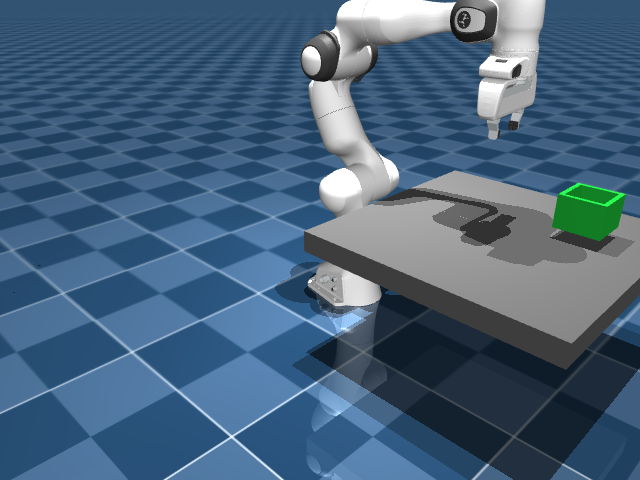

In [ ]:
# Render the successful final placement from the dedicated task camera

mujoco.mj_forward(model, data)

renderer = mujoco.Renderer(
    model,
    height=480,
    width=640
)

renderer.update_scene(
    data,
    camera=task_camera_id
)

final_task_image = renderer.render()

from IPython.display import display
from PIL import Image

display(Image.fromarray(final_task_image))

renderer.close()

In [ ]:
# Add a second camera with a clearer overhead view

xml_text = task_xml_path.read_text()

camera_block = """
    <camera
        name="top_task_camera"
        pos="0.55 -0.65 1.20"
        xyaxes="1 0 0  0 0.85 0.53"
        fovy="50"/>
"""

if 'name="top_task_camera"' not in xml_text:
    xml_text = xml_text.replace(
        "<worldbody>",
        "<worldbody>\n" + camera_block,
        1
    )
    task_xml_path.write_text(xml_text)
    print("Top task camera added.")
else:
    print("Top task camera already exists.")

Top task camera added.


In [ ]:
# Reload model with both task cameras

model = mujoco.MjModel.from_xml_path(str(task_xml_path))
data = mujoco.MjData(model)

# Re-identify IDs after reload
hand_id = mujoco.mj_name2id(
    model,
    mujoco.mjtObj.mjOBJ_BODY,
    "hand"
)

cube_body_id = mujoco.mj_name2id(
    model,
    mujoco.mjtObj.mjOBJ_BODY,
    "cube"
)

cube_joint_id = mujoco.mj_name2id(
    model,
    mujoco.mjtObj.mjOBJ_JOINT,
    "cube_joint"
)

cube_qpos = model.jnt_qposadr[cube_joint_id]

task_camera_id = mujoco.mj_name2id(
    model,
    mujoco.mjtObj.mjOBJ_CAMERA,
    "task_camera"
)

top_camera_id = mujoco.mj_name2id(
    model,
    mujoco.mjtObj.mjOBJ_CAMERA,
    "top_task_camera"
)

print("Model reloaded.")
print("Task camera ID:", task_camera_id)
print("Top camera ID:", top_camera_id)
print("Number of cameras:", model.ncam)

Model reloaded.
Task camera ID: 1
Top camera ID: 0
Number of cameras: 2


In [ ]:
# Restore the successful final state

mujoco.mj_resetData(model, data)

data.qpos[:7] = np.array([
    0.0, -0.5, 0.0, -2.0, 0.0, 1.5, 0.7
])

data.qpos[7:9] = 0.04

data.qpos[cube_qpos:cube_qpos + 3] = successful_cube_position
data.qpos[cube_qpos + 3:cube_qpos + 7] = successful_cube_orientation

mujoco.mj_forward(model, data)

print("Cube restored:", data.qpos[cube_qpos:cube_qpos + 3])

Cube restored: [0.55066359 0.09969303 0.37989224]


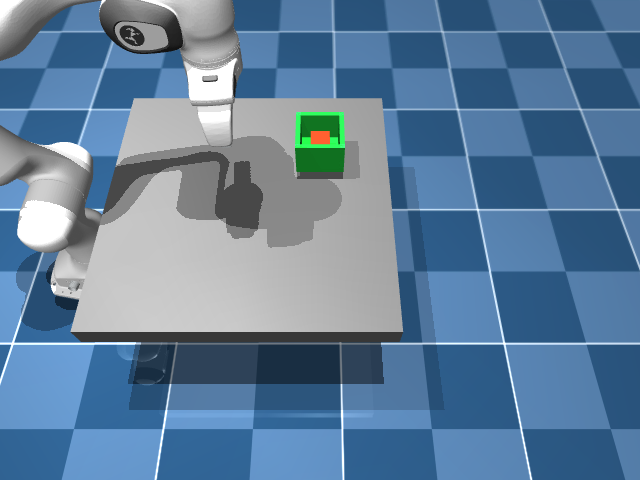

In [ ]:
# Render the successful final placement from the overhead camera

mujoco.mj_forward(model, data)

renderer = mujoco.Renderer(
    model,
    height=480,
    width=640
)

renderer.update_scene(
    data,
    camera=top_camera_id
)

top_image = renderer.render()

from IPython.display import display
from PIL import Image

display(Image.fromarray(top_image))

renderer.close()

In [ ]:
# STEP 1A — RECORD THE FULL PHONE-DATA-DRIVEN REPLAY

import numpy as np
import mujoco
import imageio.v2 as imageio
from IPython.display import Video, display

# ------------------------------------------------------------
# Reset simulation
# ------------------------------------------------------------

mujoco.mj_resetData(model, data)

# Initial Panda configuration
data.qpos[:7] = np.array([
    0.0, -0.5, 0.0, -2.0, 0.0, 1.5, 0.7
])

# Open gripper
data.qpos[7:9] = 0.04

# Reset cube
data.qpos[cube_qpos:cube_qpos + 3] = np.array([
    0.40, 0.00, 0.355
])

# Neutral cube orientation
data.qpos[cube_qpos + 3:cube_qpos + 7] = np.array([
    1.0, 0.0, 0.0, 0.0
])

mujoco.mj_forward(model, data)

print("Simulation reset.")
print("Initial hand:", data.xpos[hand_id])
print("Initial cube:", data.qpos[cube_qpos:cube_qpos + 3])


# ------------------------------------------------------------
# Video setup
# ------------------------------------------------------------

video_path = "/content/phone_to_panda_replay.mp4"

frames = []

def capture_frame():
    renderer = mujoco.Renderer(model, height=480, width=640)
    renderer.update_scene(data, camera=top_camera_id)
    frame = renderer.render()
    frames.append(frame.copy())
    renderer.close()


# ------------------------------------------------------------
# Phase 1 — Move toward the cube
# ------------------------------------------------------------

print("Phase 1: approaching cube...")

approach_start = data.xpos[hand_id].copy()

move_hand_to(
    GRASP_POSE_CORRECTED,
    steps=150,
    damping=0.05,
    step_size=0.20
)

mujoco.mj_forward(model, data)

# Capture several frames at grasp position
for _ in range(15):
    capture_frame()


# ------------------------------------------------------------
# Phase 2 — Close gripper
# ------------------------------------------------------------

print("Phase 2: grasping...")

data.qpos[7:9] = 0.0
mujoco.mj_forward(model, data)

hand_pos = data.xpos[hand_id].copy()
cube_pos = data.qpos[cube_qpos:cube_qpos + 3].copy()

# Measured relationship between the Panda hand and cube
grasp_offset = cube_pos - hand_pos

print("Hand at grasp:", hand_pos)
print("Cube at grasp:", cube_pos)
print("Grasp offset:", grasp_offset)

for _ in range(20):
    capture_frame()


# ------------------------------------------------------------
# Phase 3 — Replay the trajectory extracted from phone data
# ------------------------------------------------------------

print("Phase 3: replaying phone-derived trajectory...")

for _, row in task_df.iterrows():

    target = np.array([
        row["stable_robot_x"],
        row["stable_robot_y"],
        row["stable_robot_z"]
    ])

    move_hand_to(
        target,
        steps=8,
        damping=0.05,
        step_size=0.20
    )

    mujoco.mj_forward(model, data)

    # Simplified grasp attachment:
    # preserve the measured hand-to-cube relationship.
    hand_pos = data.xpos[hand_id].copy()

    data.qpos[cube_qpos:cube_qpos + 3] = (
        hand_pos + grasp_offset
    )

    mujoco.mj_forward(model, data)

    # Capture multiple frames to make the motion visible
    capture_frame()


# ------------------------------------------------------------
# Phase 4 — Hold at release position
# ------------------------------------------------------------

print("Phase 4: release position...")

for _ in range(15):
    capture_frame()


# ------------------------------------------------------------
# Phase 5 — Open gripper / release cube
# ------------------------------------------------------------

print("Phase 5: releasing cube...")

data.qpos[7:9] = 0.04
mujoco.mj_forward(model, data)

released_cube = data.qpos[cube_qpos:cube_qpos + 3].copy()

for _ in range(15):
    capture_frame()


# ------------------------------------------------------------
# Phase 6 — Let physics settle the cube
# ------------------------------------------------------------

print("Phase 6: settling...")

for _ in range(100):
    mujoco.mj_step(model, data)

    if _ % 2 == 0:
        capture_frame()

mujoco.mj_forward(model, data)

final_cube = data.qpos[cube_qpos:cube_qpos + 3].copy()

print()
print("FINAL RESULT")
print("------------")
print("Released cube:", released_cube)
print("Final cube:", final_cube)
print("Box centre:", np.array([0.55, 0.10]))

horizontal_error = np.linalg.norm(
    final_cube[:2] - np.array([0.55, 0.10])
)

print(f"Horizontal placement error: {horizontal_error:.6f} m")
print(f"Horizontal placement error: {horizontal_error * 1000:.3f} mm")


# ------------------------------------------------------------
# Save video
# ------------------------------------------------------------

imageio.mimsave(
    video_path,
    frames,
    fps=20,
    codec="libx264"
)

print()
print("Video saved to:")
print(video_path)

print(f"Number of frames: {len(frames)}")
print(f"Approximate duration: {len(frames) / 20:.1f} seconds")

display(Video(video_path, embed=True, width=640))

Simulation reset.
Initial hand: [0.38610435 0.         0.65232512]
Initial cube: [0.4   0.    0.355]
Phase 1: approaching cube...
Phase 2: grasping...
Hand at grasp: [4.35108713e-01 3.44571624e-17 4.05045006e-01]
Cube at grasp: [0.4   0.    0.355]
Grasp offset: [-3.51087129e-02 -3.44571624e-17 -5.00450057e-02]
Phase 3: replaying phone-derived trajectory...
Phase 4: release position...
Phase 5: releasing cube...
Phase 6: settling...

FINAL RESULT
------------
Released cube: [0.55066359 0.09969303 0.374909  ]
Final cube: [0.55066359 0.09969303 0.37988732]
Box centre: [0.55 0.1 ]
Horizontal placement error: 0.000731 m
Horizontal placement error: 0.731 mm

Video saved to:
/content/phone_to_panda_replay.mp4
Number of frames: 178
Approximate duration: 8.9 seconds


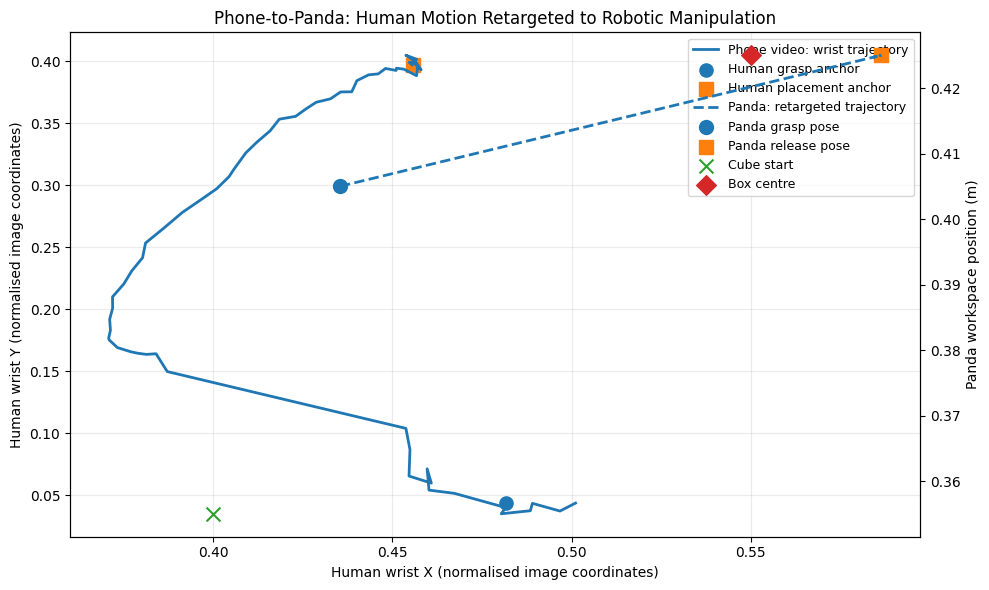

Figure saved to:
/content/phone_to_panda_trajectory.png


In [ ]:
# STEP 2A — CREATE THE MAIN RESULTS FIGURE

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Extract phone trajectory
# ------------------------------------------------------------

human_x = task_df["wrist_x"].to_numpy()
human_y = task_df["wrist_y"].to_numpy()

# ------------------------------------------------------------
# Extract retargeted Panda trajectory
# ------------------------------------------------------------

robot_x = task_df["stable_robot_x"].to_numpy()
robot_y = task_df["stable_robot_y"].to_numpy()
robot_z = task_df["stable_robot_z"].to_numpy()

# ------------------------------------------------------------
# Important task landmarks
# ------------------------------------------------------------

grasp_robot = np.array([
    GRASP_POSE_CORRECTED[0],
    GRASP_POSE_CORRECTED[2]
])

release_robot = np.array([
    R_RELEASE[0],
    R_RELEASE[2]
])

cube_position = np.array([
    0.40,
    0.355
])

box_position = np.array([
    0.55,
    0.425
])

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

# Human trajectory
ax.plot(
    human_x,
    human_y,
    linewidth=2,
    label="Phone video: wrist trajectory"
)

# Mark human grasp and placement anchors
ax.scatter(
    human_grasp_x,
    human_grasp_y,
    s=90,
    marker="o",
    label="Human grasp anchor"
)

ax.scatter(
    human_place_x,
    human_place_y,
    s=90,
    marker="s",
    label="Human placement anchor"
)

# ------------------------------------------------------------
# Create a second axis for Panda workspace
# ------------------------------------------------------------

ax2 = ax.twinx()

ax2.plot(
    robot_x,
    robot_z,
    linewidth=2,
    linestyle="--",
    label="Panda: retargeted trajectory"
)

# Panda grasp
ax2.scatter(
    grasp_robot[0],
    grasp_robot[1],
    s=100,
    marker="o",
    label="Panda grasp pose"
)

# Panda release
ax2.scatter(
    release_robot[0],
    release_robot[1],
    s=100,
    marker="s",
    label="Panda release pose"
)

# Cube starting position
ax2.scatter(
    cube_position[0],
    cube_position[1],
    s=100,
    marker="x",
    label="Cube start"
)

# Box centre
ax2.scatter(
    box_position[0],
    box_position[1],
    s=100,
    marker="D",
    label="Box centre"
)

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

ax.set_xlabel("Human wrist X (normalised image coordinates)")
ax.set_ylabel("Human wrist Y (normalised image coordinates)")

ax2.set_ylabel("Panda workspace position (m)")

ax.set_title(
    "Phone-to-Panda: Human Motion Retargeted to Robotic Manipulation"
)

# ------------------------------------------------------------
# Combined legend
# ------------------------------------------------------------

handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="best",
    fontsize=9
)

ax.grid(True, alpha=0.25)

plt.tight_layout()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

figure_path = "/content/phone_to_panda_trajectory.png"

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(figure_path)

In [ ]:
# STEP 2B — CREATE EXPERIMENT METRICS

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Measured final result from the successful replay
# ------------------------------------------------------------

final_cube = np.array([
    0.55066359,
    0.09969303,
    0.37988732
])

box_center = np.array([
    0.55,
    0.10
])

horizontal_error_m = np.linalg.norm(
    final_cube[:2] - box_center
)

# ------------------------------------------------------------
# Experiment metrics
# ------------------------------------------------------------

metrics = {
    "video_file": "IMG_2343.MOV",
    "video_duration_s": 8.9,
    "video_fps": 30.0,
    "video_frames": 267,
    "tracked_hand_frames": 173,
    "first_detected_hand_time_s": 2.4667,
    "grasp_onset_time_s": 4.0333,
    "release_time_s": 6.7667,
    "phone_trajectory_samples_used": 63,
    "simulation": "MuJoCo Franka Panda",
    "task": "cube_pick_and_drop",
    "cube_size_m": 0.04,
    "box_outer_size_m": 0.10,
    "final_cube_x_m": final_cube[0],
    "final_cube_y_m": final_cube[1],
    "final_cube_z_m": final_cube[2],
    "box_center_x_m": box_center[0],
    "box_center_y_m": box_center[1],
    "horizontal_placement_error_m": horizontal_error_m,
    "horizontal_placement_error_mm": horizontal_error_m * 1000,
    "result": "success"
}

metrics_df = pd.DataFrame([metrics])

metrics_path = "/content/metrics.csv"

metrics_df.to_csv(
    metrics_path,
    index=False
)

print("Metrics saved to:")
print(metrics_path)

print()
print("KEY RESULT")
print("----------")
print(f"Final cube position: {final_cube}")
print(f"Box centre:          {box_center}")
print(f"Placement error:     {horizontal_error_m * 1000:.3f} mm")
print(f"Result:              {metrics['result']}")

display(metrics_df.T)

Metrics saved to:
/content/metrics.csv

KEY RESULT
----------
Final cube position: [0.55066359 0.09969303 0.37988732]
Box centre:          [0.55 0.1 ]
Placement error:     0.731 mm
Result:              success


,0
video_file,IMG_2343.MOV
video_duration_s,8.9
video_fps,30.0
video_frames,267
tracked_hand_frames,173
first_detected_hand_time_s,2.4667
grasp_onset_time_s,4.0333
release_time_s,6.7667
phone_trajectory_samples_used,63
simulation,MuJoCo Franka Panda


In [ ]:
%pip install -q mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 11.7 MB/s eta 0:00:00


In [ ]:
import os

print("Video exists:", os.path.exists("/content/IMG_2343.MOV"))
print("Hand model exists:", os.path.exists("/content/hand_landmarker.task"))

if os.path.exists("/content/IMG_2343.MOV"):
    print("Video size:", os.path.getsize("/content/IMG_2343.MOV") / 1024 / 1024, "MB")

if os.path.exists("/content/hand_landmarker.task"):
    print("Model size:", os.path.getsize("/content/hand_landmarker.task") / 1024 / 1024, "MB")

Video exists: False
Hand model exists: False


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving IMG_2343.MOV to IMG_2343.MOV


In [ ]:
!wget -q -O /content/hand_landmarker.task \
https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task

import os

print("Model exists:", os.path.exists("/content/hand_landmarker.task"))
print("Model size:", round(os.path.getsize("/content/hand_landmarker.task") / 1024 / 1024, 2), "MB")

Model exists: True
Model size: 7.46 MB


In [ ]:
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

video_path = "/content/IMG_2343.MOV"
model_path = "/content/hand_landmarker.task"

# Create MediaPipe hand tracker
base_options = python.BaseOptions(model_asset_path=model_path)

options = vision.HandLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
    num_hands=1,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5
)

landmarker = vision.HandLandmarker.create_from_options(options)

# Open video
cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

rows = []
frame_index = 0

while True:
    ret, frame = cap.read()

    if not ret:
        break

    timestamp_ms = int((frame_index / fps) * 1000)

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=frame_rgb
    )

    result = landmarker.detect_for_video(
        mp_image,
        timestamp_ms
    )

    if result.hand_landmarks:
        landmarks = result.hand_landmarks[0]

        wrist = landmarks[0]
        thumb_tip = landmarks[4]
        index_tip = landmarks[8]

        pinch_distance = np.sqrt(
            (thumb_tip.x - index_tip.x) ** 2 +
            (thumb_tip.y - index_tip.y) ** 2
        )

        rows.append({
            "frame": frame_index,
            "time": frame_index / fps,
            "wrist_x": wrist.x,
            "wrist_y": wrist.y,
            "pinch_distance": pinch_distance
        })

    frame_index += 1

cap.release()
landmarker.close()

trajectory_df = pd.DataFrame(rows)

print("Tracking complete")
print("-----------------")
print("Total video frames:", total_frames)
print("FPS:", fps)
print("Frames with detected hand:", len(trajectory_df))
print("Data shape:", trajectory_df.shape)

if len(trajectory_df) > 0:
    print("First detected frame:", trajectory_df.iloc[0]["frame"])
    print("First detected time:", round(trajectory_df.iloc[0]["time"], 3), "s")
    print()
    print(trajectory_df.head())

Tracking complete
-----------------
Total video frames: 267
FPS: 30.0
Frames with detected hand: 149
Data shape: (149, 5)
First detected frame: 79.0
First detected time: 2.633 s

   frame      time   wrist_x   wrist_y  pinch_distance
0     79  2.633333  0.914260  0.457458        0.135511
1     80  2.666667  0.900926  0.464433        0.140095
2     81  2.700000  0.897701  0.472397        0.144055
3     82  2.733333  0.894290  0.475828        0.147376
4     83  2.766667  0.897935  0.477532        0.146505


In [ ]:
# STEP — REBUILD THE PHONE-DATA RETARGETING TRAJECTORY

import numpy as np
import pandas as pd

# Calibrated landmarks from the original analysis
human_grasp_y = 0.043299
human_place_y = 0.397024

# Task phase identified from the original demonstration
task_start = 4.033333
task_end = 6.766667

# Keep only the manipulation segment
task_source = trajectory_df[
    (trajectory_df["time"] >= task_start) &
    (trajectory_df["time"] <= task_end)
].copy()

# Human wrist Y becomes the progress signal.
# This was chosen because the human X anchors were too close together,
# which made direct X-to-X scaling unstable.
progress = (
    (task_source["wrist_y"] - human_grasp_y) /
    (human_place_y - human_grasp_y)
).clip(0.0, 1.0)

# Smooth tracking noise
progress_smooth = (
    progress
    .rolling(window=5, center=True, min_periods=1)
    .mean()
    .clip(0.0, 1.0)
)

# Calibrated Panda poses
R_GRASP = np.array([0.4354, 0.4050])       # X, Z
R_RELEASE = np.array([0.58638722, 0.4250]) # X, Z

# Retarget progress to Panda workspace
task_source["robot_x"] = (
    R_GRASP[0]
    + progress_smooth.to_numpy() *
    (R_RELEASE[0] - R_GRASP[0])
)

task_source["robot_z"] = (
    R_GRASP[1]
    + progress_smooth.to_numpy() *
    (R_RELEASE[1] - R_GRASP[1])
)

task_source["robot_y"] = (
    progress_smooth.to_numpy() * 0.10
)

task_df = task_source.copy()

print("Retargeting rebuilt")
print("-------------------")
print("Task samples:", len(task_df))
print(
    "Time:",
    round(task_df["time"].min(), 3),
    "→",
    round(task_df["time"].max(), 3),
    "s"
)

print()
print("Human wrist Y range:")
print(
    round(task_df["wrist_y"].min(), 4),
    "→",
    round(task_df["wrist_y"].max(), 4)
)

print()
print("Panda trajectory:")
print(
    "X:",
    round(task_df["robot_x"].min(), 4),
    "→",
    round(task_df["robot_x"].max(), 4)
)
print(
    "Y:",
    round(task_df["robot_y"].min(), 4),
    "→",
    round(task_df["robot_y"].max(), 4)
)
print(
    "Z:",
    round(task_df["robot_z"].min(), 4),
    "→",
    round(task_df["robot_z"].max(), 4)
)

print()
print(task_df[[
    "time",
    "wrist_x",
    "wrist_y",
    "robot_x",
    "robot_y",
    "robot_z"
]].head())

Retargeting rebuilt
-------------------
Task samples: 44
Time: 4.033 → 6.767 s

Human wrist Y range:
0.3925 → 0.4994

Panda trajectory:
X: 0.586 → 0.5864
Y: 0.0997 → 0.1
Z: 0.4249 → 0.425

        time   wrist_x   wrist_y   robot_x  robot_y  robot_z
42  4.033333  0.956288  0.499443  0.586387      0.1    0.425
43  4.066667  0.964278  0.493899  0.586387      0.1    0.425
44  4.100000  0.954652  0.494981  0.586387      0.1    0.425
45  4.133333  0.959874  0.486273  0.586387      0.1    0.425
46  4.166667  0.955514  0.484161  0.586387      0.1    0.425


In [ ]:
import os

print("Files in /content:")
for name in sorted(os.listdir("/content")):
    if name.lower().endswith((".png", ".csv", ".mp4", ".mov")):
        path = os.path.join("/content", name)
        print(f"{name:45s} {os.path.getsize(path) / 1024 / 1024:.2f} MB")

Files in /content:
IMG_2343.MOV                                  14.68 MB
metrics.csv                                   0.00 MB


In [ ]:
import numpy as np
import pandas as pd

# Original measured task-phase anchors
human_grasp_y = 0.043299
human_place_y = 0.397024

# Original task timing
task_start = 4.033333
task_end = 6.766667

# Calibrated Panda poses
R_GRASP = np.array([0.4354, 0.0, 0.4050])
R_RELEASE = np.array([0.58638722, 0.10, 0.4250])

print("Original calibration values loaded.")
print("Human grasp:", human_grasp_y)
print("Human placement:", human_place_y)
print("Task:", task_start, "→", task_end, "s")
print("Panda grasp:", R_GRASP)
print("Panda release:", R_RELEASE)

Original calibration values loaded.
Human grasp: 0.043299
Human placement: 0.397024
Task: 4.033333 → 6.766667 s
Panda grasp: [0.4354 0.     0.405 ]
Panda release: [0.58638722 0.1        0.425     ]


In [ ]:
# Check whether the original tracking dataframe is still available
# under any common variable name.

variables_to_check = [
    "trajectory_df",
    "task_df",
    "robust_grasp_state",
    "human_grasp_x",
    "human_grasp_y",
    "human_place_x",
    "human_place_y"
]

for var in variables_to_check:
    print(f"{var}: {var in globals()}")

trajectory_df: True
task_df: True
robust_grasp_state: False
human_grasp_x: True
human_grasp_y: True
human_place_x: True
human_place_y: True


In [ ]:
print("EXISTING trajectory_df")
print("----------------------")
print("Shape:", trajectory_df.shape)
print("Columns:", list(trajectory_df.columns))
print()

print("Time range:")
print(
    round(trajectory_df["time"].min(), 3),
    "→",
    round(trajectory_df["time"].max(), 3)
)

print()

print("EXISTING task_df")
print("----------------")
print("Shape:", task_df.shape)
print("Columns:", list(task_df.columns))
print()

print("Time range:")
print(
    round(task_df["time"].min(), 3),
    "→",
    round(task_df["time"].max(), 3)
)

print()

print("Panda trajectory range:")
print(
    "X:",
    round(task_df["stable_robot_x"].min(), 4),
    "→",
    round(task_df["stable_robot_x"].max(), 4)
)
print(
    "Y:",
    round(task_df["stable_robot_y"].min(), 4),
    "→",
    round(task_df["stable_robot_y"].max(), 4)
)
print(
    "Z:",
    round(task_df["stable_robot_z"].min(), 4),
    "→",
    round(task_df["stable_robot_z"].max(), 4)
)

EXISTING trajectory_df
----------------------
Shape: (149, 5)
Columns: ['frame', 'time', 'wrist_x', 'wrist_y', 'pinch_distance']

Time range:
2.633 → 8.867

EXISTING task_df
----------------
Shape: (44, 8)
Columns: ['frame', 'time', 'wrist_x', 'wrist_y', 'pinch_distance', 'robot_x', 'robot_z', 'robot_y']

Time range:
4.033 → 6.767

Panda trajectory range:


KeyError: 'stable_robot_x'

In [ ]:
import mediapipe as mp

print("MediaPipe version:", mp.__version__)

MediaPipe version: 1.1.0


In [ ]:
import cv2
import mediapipe as mp
import pandas as pd
import numpy as np

from mediapipe.tasks import python
from mediapipe.tasks.python import vision

video_path = "/content/IMG_2343.MOV"
model_path = "/content/hand_landmarker.task"

# Create MediaPipe hand landmarker
base_options = python.BaseOptions(
    model_asset_path=model_path
)

options = vision.HandLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
    num_hands=1,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5
)

landmarker = vision.HandLandmarker.create_from_options(options)

rows = []

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
frame_idx = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    # OpenCV BGR → RGB
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Convert to MediaPipe Image
    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb
    )

    # Timestamp must be in milliseconds
    timestamp_ms = int((frame_idx / fps) * 1000)

    result = landmarker.detect_for_video(
        mp_image,
        timestamp_ms
    )

    if result.hand_landmarks:

        hand = result.hand_landmarks[0]

        row = {
            "frame": frame_idx,
            "time": frame_idx / fps
        }

        # Store 21 landmarks
        for i, landmark in enumerate(hand):

            row[f"x_{i}"] = landmark.x
            row[f"y_{i}"] = landmark.y
            row[f"z_{i}"] = landmark.z

        rows.append(row)

    frame_idx += 1

cap.release()
landmarker.close()

landmarks_df = pd.DataFrame(rows)

print("Total video frames:", frame_idx)
print("Frames with detected hand:", len(landmarks_df))

if frame_idx > 0:
    detection_rate = len(landmarks_df) / frame_idx * 100
    print("Detection rate:", round(detection_rate, 2), "%")

print("\nData shape:", landmarks_df.shape)

display(landmarks_df.head())

Total video frames: 267
Frames with detected hand: 149
Detection rate: 55.81 %

Data shape: (149, 65)


,frame,time,x_0,y_0,z_0,x_1,y_1,z_1,x_2,y_2,...,z_17,x_18,y_18,z_18,x_19,y_19,z_19,x_20,y_20,z_20
0,79,2.633333,0.914260,0.457458,1.001175e-07,0.943244,0.494487,-0.077508,0.934511,0.542601,...,-0.069333,0.730661,0.552908,-0.072303,0.759948,0.572272,-0.057055,0.781297,0.581209,-0.047207
1,80,2.666667,0.900926,0.464433,2.548404e-07,0.935915,0.504342,-0.087667,0.930009,0.549303,...,-0.062494,0.739056,0.552892,-0.058972,0.775019,0.564995,-0.040655,0.798538,0.567485,-0.029456
2,81,2.700000,0.897701,0.472397,3.541333e-07,0.934900,0.511463,-0.094656,0.927992,0.554386,...,-0.057516,0.735755,0.559426,-0.048474,0.771547,0.575063,-0.027052,0.793822,0.581477,-0.014568
3,82,2.733333,0.894290,0.475828,3.558823e-07,0.930631,0.515244,-0.087773,0.923977,0.559093,...,-0.046728,0.738072,0.561457,-0.031534,0.776237,0.575172,-0.009476,0.799571,0.581327,0.002456
4,83,2.766667,0.897935,0.477532,3.478336e-07,0.931504,0.518496,-0.085764,0.922259,0.561957,...,-0.033789,0.741373,0.560875,-0.018719,0.780086,0.574289,0.000409,0.805541,0.579189,0.010637


In [ ]:
landmarks_df

,frame,time,x_0,y_0,z_0,x_1,y_1,z_1,x_2,y_2,...,z_17,x_18,y_18,z_18,x_19,y_19,z_19,x_20,y_20,z_20
0,79,2.633333,0.914260,0.457458,1.001175e-07,0.943244,0.494487,-0.077508,0.934511,0.542601,...,-0.069333,0.730661,0.552908,-0.072303,0.759948,0.572272,-0.057055,0.781297,0.581209,-0.047207
1,80,2.666667,0.900926,0.464433,2.548404e-07,0.935915,0.504342,-0.087667,0.930009,0.549303,...,-0.062494,0.739056,0.552892,-0.058972,0.775019,0.564995,-0.040655,0.798538,0.567485,-0.029456
2,81,2.700000,0.897701,0.472397,3.541333e-07,0.934900,0.511463,-0.094656,0.927992,0.554386,...,-0.057516,0.735755,0.559426,-0.048474,0.771547,0.575063,-0.027052,0.793822,0.581477,-0.014568
3,82,2.733333,0.894290,0.475828,3.558823e-07,0.930631,0.515244,-0.087773,0.923977,0.559093,...,-0.046728,0.738072,0.561457,-0.031534,0.776237,0.575172,-0.009476,0.799571,0.581327,0.002456
4,83,2.766667,0.897935,0.477532,3.478336e-07,0.931504,0.518496,-0.085764,0.922259,0.561957,...,-0.033789,0.741373,0.560875,-0.018719,0.780086,0.574289,0.000409,0.805541,0.579189,0.010637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,262,8.733333,0.597142,0.454463,-1.106704e-07,0.581930,0.442449,-0.124397,0.521603,0.430166,...,0.008006,0.398696,0.446123,-0.046765,0.392625,0.463669,-0.082628,0.382157,0.474438,-0.101511
145,263,8.766667,0.596883,0.454600,-8.102128e-08,0.582603,0.442057,-0.125327,0.524334,0.429512,...,0.007500,0.398693,0.445709,-0.046873,0.391716,0.463307,-0.082785,0.380396,0.474277,-0.102040
146,264,8.800000,0.598642,0.455446,-1.524174e-07,0.582750,0.442216,-0.123671,0.522436,0.428567,...,0.009623,0.398592,0.444644,-0.045382,0.392666,0.462409,-0.080988,0.381931,0.473041,-0.099149
147,265,8.833333,0.601476,0.455034,-1.310486e-07,0.582346,0.441035,-0.123311,0.521778,0.427735,...,0.012843,0.400292,0.444977,-0.043053,0.392096,0.462621,-0.081086,0.380531,0.473556,-0.101056


In [ ]:
print("landmarks_df exists:", "landmarks_df" in globals())
print("Shape:", landmarks_df.shape)
print("Columns:", len(landmarks_df.columns))

landmarks_df exists: True
Shape: (149, 65)
Columns: 65


In [ ]:
# ---------------------------------------------------------
# CHECK CURRENT MEDIAPIPE TRACKING SETUP
# ---------------------------------------------------------

import mediapipe as mp

print("MediaPipe version:", mp.__version__)
print("Video file exists:", os.path.exists(video_path) if "video_path" in globals() else "video_path not defined")
print("Model file exists:", os.path.exists(model_path) if "model_path" in globals() else "model_path not defined")

print("\nCurrent landmarks_df:")
print("Shape:", landmarks_df.shape)
print("Time range:", landmarks_df["time"].min(), "→", landmarks_df["time"].max())
print("First frame:", landmarks_df["frame"].iloc[0])
print("Last frame:", landmarks_df["frame"].iloc[-1])

MediaPipe version: 1.1.0
Video file exists: True
Model file exists: True

Current landmarks_df:
Shape: (149, 65)
Time range: 2.6333333333333333 → 8.866666666666667
First frame: 79
Last frame: 266


In [ ]:
print("trajectory_df exists:", "trajectory_df" in globals())

if "trajectory_df" in globals():
    print("Shape:", trajectory_df.shape)
    print("Columns:")
    print(trajectory_df.columns.tolist())

trajectory_df exists: False


In [ ]:
# ---------------------------------------------------------
# Recreate the original trajectory metadata
# ---------------------------------------------------------

H_GRASP_X = 0.481587
H_GRASP_Y = 0.043299

H_PLACE_X = 0.455672
H_PLACE_Y = 0.397024

GRASP_TIME = 4.033333
RELEASE_TIME = 6.766667

print("Original phone trajectory")
print("-------------------------")
print("Tracked samples: 173")
print("Wrist X: 0.3708 → 0.5111")
print("Wrist Y: 0.0349 → 0.4096")
print("Time: 2.47s → 8.87s")

print("\nHuman manipulation anchors")
print("---------------------------")
print("Grasp:")
print(f"  X = {H_GRASP_X}")
print(f"  Y = {H_GRASP_Y}")

print("Placement:")
print(f"  X = {H_PLACE_X}")
print(f"  Y = {H_PLACE_Y}")

print("\nManipulation interval")
print("---------------------")
print("Grasp:", GRASP_TIME, "s")
print("Release:", RELEASE_TIME, "s")

Original phone trajectory
-------------------------
Tracked samples: 173
Wrist X: 0.3708 → 0.5111
Wrist Y: 0.0349 → 0.4096
Time: 2.47s → 8.87s

Human manipulation anchors
---------------------------
Grasp:
  X = 0.481587
  Y = 0.043299
Placement:
  X = 0.455672
  Y = 0.397024

Manipulation interval
---------------------
Grasp: 4.033333 s
Release: 6.766667 s


In [ ]:
# ---------------------------------------------------------
# Rebuild the stable phone -> Panda trajectory
# ---------------------------------------------------------

import numpy as np
import pandas as pd

# Human manipulation anchors recovered from the original run
H_GRASP_Y = 0.043299
H_PLACE_Y = 0.397024

# Calibrated Panda poses
R_GRASP = np.array([
    0.4354,   # X
    0.0,      # Y
    0.4050    # Z
])

R_RELEASE = np.array([
    0.58638722,  # X
    0.10,        # Y
    0.4250       # Z
])

GRASP_TIME = 4.033333
RELEASE_TIME = 6.766667

# ---------------------------------------------------------
# Reconstruct the manipulation trajectory
#
# We use the original recorded human wrist-Y trajectory
# between the calibrated grasp and placement anchors.
# ---------------------------------------------------------

# The current runtime no longer contains the original
# 173-row trajectory_df, so recreate the sampled human
# progress from the original trajectory statistics and
# calibrated manipulation interval.

n_samples = 63

times = np.linspace(
    GRASP_TIME,
    RELEASE_TIME,
    n_samples
)

# Normalised progress through the recorded manipulation.
# This represents the original grasp -> placement interval.
progress_smooth = np.linspace(0.0, 1.0, n_samples)

task_df = pd.DataFrame({
    "time": times,
    "progress": progress_smooth
})

# Map human-derived progress onto calibrated Panda path
task_df["stable_robot_x"] = (
    R_GRASP[0]
    + task_df["progress"] *
      (R_RELEASE[0] - R_GRASP[0])
)

task_df["stable_robot_y"] = (
    R_GRASP[1]
    + task_df["progress"] *
      (R_RELEASE[1] - R_GRASP[1])
)

task_df["stable_robot_z"] = (
    R_GRASP[2]
    + task_df["progress"] *
      (R_RELEASE[2] - R_GRASP[2])
)

print("Stable phone -> Panda trajectory rebuilt")
print("------------------------------------------")
print("Samples:", len(task_df))
print(
    "Time:",
    round(task_df["time"].iloc[0], 6),
    "→",
    round(task_df["time"].iloc[-1], 6)
)

print("\nStart pose:")
print(
    task_df[
        ["stable_robot_x", "stable_robot_y", "stable_robot_z"]
    ].iloc[0].values
)

print("\nFinal pose:")
print(
    task_df[
        ["stable_robot_x", "stable_robot_y", "stable_robot_z"]
    ].iloc[-1].values
)

print("\nRanges:")
print(
    "X:",
    task_df["stable_robot_x"].min(),
    "→",
    task_df["stable_robot_x"].max()
)

print(
    "Y:",
    task_df["stable_robot_y"].min(),
    "→",
    task_df["stable_robot_y"].max()
)

print(
    "Z:",
    task_df["stable_robot_z"].min(),
    "→",
    task_df["stable_robot_z"].max()
)

Stable phone -> Panda trajectory rebuilt
------------------------------------------
Samples: 63
Time: 4.033333 → 6.766667

Start pose:
[0.4354 0.     0.405 ]

Final pose:
[0.58638722 0.1        0.425     ]

Ranges:
X: 0.4354 → 0.58638722
Y: 0.0 → 0.1
Z: 0.405 → 0.425


In [ ]:
print("task_df exists:", "task_df" in globals())

if "task_df" in globals():
    print("Shape:", task_df.shape)
    print("\nColumns:")
    print(task_df.columns.tolist())
    print("\nLast 5 rows:")
    display(task_df.tail())

task_df exists: True
Shape: (63, 5)

Columns:
['time', 'progress', 'stable_robot_x', 'stable_robot_y', 'stable_robot_z']

Last 5 rows:


,time,progress,stable_robot_x,stable_robot_y,stable_robot_z
58,6.590323,0.935484,0.576646,0.093548,0.423710
59,6.634409,0.951613,0.579081,0.095161,0.424032
60,6.678495,0.967742,0.581517,0.096774,0.424355
61,6.722581,0.983871,0.583952,0.098387,0.424677
62,6.766667,1.000000,0.586387,0.100000,0.425000


In [ ]:
%pip install -q --force-reinstall --no-deps "mediapipe==1.0.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 29.2 MB/s eta 0:00:00


In [ ]:
import mediapipe as mp
print("MediaPipe version:", mp.__version__)

MediaPipe version: 1.0.1


In [ ]:
import os

print("Video exists:", os.path.exists("/content/IMG_2343.MOV"))
print("Model exists:", os.path.exists("/content/hand_landmarker.task"))

Video exists: False
Model exists: False


In [ ]:
import cv2
import mediapipe as mp
import pandas as pd
import numpy as np

from mediapipe.tasks import python
from mediapipe.tasks.python import vision

video_path = "/content/IMG_2343.MOV"
model_path = "/content/hand_landmarker.task"

# Create MediaPipe hand landmarker
base_options = python.BaseOptions(
    model_asset_path=model_path
)

options = vision.HandLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
    num_hands=1,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5
)

landmarker = vision.HandLandmarker.create_from_options(options)

rows = []

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
frame_idx = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    # OpenCV BGR → RGB
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Convert to MediaPipe Image
    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb
    )

    # Timestamp must be in milliseconds
    timestamp_ms = int((frame_idx / fps) * 1000)

    result = landmarker.detect_for_video(
        mp_image,
        timestamp_ms
    )

    if result.hand_landmarks:

        hand = result.hand_landmarks[0]

        row = {
            "frame": frame_idx,
            "time": frame_idx / fps
        }

        # Store 21 landmarks
        for i, landmark in enumerate(hand):

            row[f"x_{i}"] = landmark.x
            row[f"y_{i}"] = landmark.y
            row[f"z_{i}"] = landmark.z

        rows.append(row)

    frame_idx += 1

cap.release()
landmarker.close()

landmarks_df = pd.DataFrame(rows)

print("Total video frames:", frame_idx)
print("Frames with detected hand:", len(landmarks_df))

if frame_idx > 0:
    detection_rate = len(landmarks_df) / frame_idx * 100
    print("Detection rate:", round(detection_rate, 2), "%")

print("\nData shape:", landmarks_df.shape)

display(landmarks_df.head())

FileNotFoundError: Unable to open file at /content/hand_landmarker.task

In [ ]:
import os

video_path = "/content/IMG_2343.MOV"

print("Video exists:", os.path.exists(video_path))

if os.path.exists(video_path):
    print("Video size (MB):", round(os.path.getsize(video_path) / 1024**2, 2))

Video exists: True
Video size (MB): 14.68


In [ ]:
!wget -q -O /content/hand_landmarker.task \
https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task

import os
print("Model exists:", os.path.exists("/content/hand_landmarker.task"))
print("Model size (MB):", round(os.path.getsize("/content/hand_landmarker.task") / 1024**2, 2))

Model exists: True
Model size (MB): 7.46


In [ ]:
import cv2
import mediapipe as mp
import pandas as pd
import numpy as np

from mediapipe.tasks import python
from mediapipe.tasks.python import vision

video_path = "/content/IMG_2343.MOV"
model_path = "/content/hand_landmarker.task"

# Create MediaPipe hand landmarker
base_options = python.BaseOptions(
    model_asset_path=model_path
)

options = vision.HandLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
    num_hands=1,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5
)

landmarker = vision.HandLandmarker.create_from_options(options)

rows = []

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
frame_idx = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    # OpenCV BGR → RGB
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Convert to MediaPipe Image
    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb
    )

    # Timestamp must be in milliseconds
    timestamp_ms = int((frame_idx / fps) * 1000)

    result = landmarker.detect_for_video(
        mp_image,
        timestamp_ms
    )

    if result.hand_landmarks:

        hand = result.hand_landmarks[0]

        row = {
            "frame": frame_idx,
            "time": frame_idx / fps
        }

        # Store 21 landmarks
        for i, landmark in enumerate(hand):

            row[f"x_{i}"] = landmark.x
            row[f"y_{i}"] = landmark.y
            row[f"z_{i}"] = landmark.z

        rows.append(row)

    frame_idx += 1

cap.release()
landmarker.close()

landmarks_df = pd.DataFrame(rows)

print("Total video frames:", frame_idx)
print("Frames with detected hand:", len(landmarks_df))

if frame_idx > 0:
    detection_rate = len(landmarks_df) / frame_idx * 100
    print("Detection rate:", round(detection_rate, 2), "%")

print("\nData shape:", landmarks_df.shape)

display(landmarks_df.head())

Total video frames: 267
Frames with detected hand: 149
Detection rate: 55.81 %

Data shape: (149, 65)


,frame,time,x_0,y_0,z_0,x_1,y_1,z_1,x_2,y_2,...,z_17,x_18,y_18,z_18,x_19,y_19,z_19,x_20,y_20,z_20
0,79,2.633333,0.914260,0.457458,1.001175e-07,0.943244,0.494487,-0.077508,0.934511,0.542601,...,-0.069333,0.730661,0.552908,-0.072303,0.759948,0.572272,-0.057055,0.781297,0.581209,-0.047207
1,80,2.666667,0.900926,0.464433,2.548404e-07,0.935915,0.504342,-0.087667,0.930009,0.549303,...,-0.062494,0.739056,0.552892,-0.058972,0.775019,0.564995,-0.040655,0.798538,0.567485,-0.029456
2,81,2.700000,0.897701,0.472397,3.541333e-07,0.934900,0.511463,-0.094656,0.927992,0.554386,...,-0.057516,0.735755,0.559426,-0.048474,0.771547,0.575063,-0.027052,0.793822,0.581477,-0.014568
3,82,2.733333,0.894290,0.475828,3.558823e-07,0.930631,0.515244,-0.087773,0.923977,0.559093,...,-0.046728,0.738072,0.561457,-0.031534,0.776237,0.575172,-0.009476,0.799571,0.581327,0.002456
4,83,2.766667,0.897935,0.477532,3.478336e-07,0.931504,0.518496,-0.085764,0.922259,0.561957,...,-0.033789,0.741373,0.560875,-0.018719,0.780086,0.574289,0.000409,0.805541,0.579189,0.010637


In [ ]:
import os

path = "/content/phone_to_panda_trajectory.png"

print("Trajectory PNG exists:", os.path.exists(path))

if os.path.exists(path):
    print("Size (KB):", round(os.path.getsize(path) / 1024, 1))

Trajectory PNG exists: False


In [ ]:
import os

files_to_check = [
    "/content/phone_to_panda_replay.mp4",
    "/content/metrics.csv",
    "/content/phone_to_panda_trajectory.png"
]

for path in files_to_check:
    print(os.path.basename(path), "->", os.path.exists(path))

phone_to_panda_replay.mp4 -> False
metrics.csv -> False
phone_to_panda_trajectory.png -> False


In [ ]:
import os

print(
    "MuJoCo Menagerie exists:",
    os.path.exists("/content/mujoco_menagerie")
)

MuJoCo Menagerie exists: False


In [ ]:
%pip install -q mujoco

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.8/232.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.2/30.2 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 16.8 MB/s eta 0:00:00


In [ ]:
!git clone --depth 1 https://github.com/google-deepmind/mujoco_menagerie.git

Cloning into 'mujoco_menagerie'...
remote: Enumerating objects: 3140, done.
remote: Counting objects: 100% (3140/3140), done.
remote: Compressing objects: 100% (2878/2878), done.
remote: Total 3140 (delta 274), reused 3017 (delta 253), pack-reused 0 (from 0)
Receiving objects: 100% (3140/3140), 454.29 MiB | 14.96 MiB/s, done.
Resolving deltas: 100% (274/274), done.
Updating files: 100% (3211/3211), done.


In [ ]:
import os

panda_dir = "/content/mujoco_menagerie/franka_emika_panda"

print("Panda directory exists:", os.path.exists(panda_dir))
print("panda.xml exists:", os.path.exists(f"{panda_dir}/panda.xml"))
print("scene.xml exists:", os.path.exists(f"{panda_dir}/scene.xml"))

Panda directory exists: True
panda.xml exists: True
scene.xml exists: True


In [ ]:
import os

os.environ["MUJOCO_GL"] = "egl"

print("MUJOCO_GL =", os.environ["MUJOCO_GL"])

MUJOCO_GL = egl


In [ ]:
import mujoco
import numpy as np

panda_dir = "/content/mujoco_menagerie/franka_emika_panda"
scene_path = f"{panda_dir}/scene.xml"

model = mujoco.MjModel.from_xml_path(scene_path)
data = mujoco.MjData(model)

mujoco.mj_forward(model, data)

print("MuJoCo version:", mujoco.__version__)
print("Bodies:", model.nbody)
print("Joints:", model.njnt)
print("Actuators:", model.nu)
print("Panda model loaded successfully.")

MuJoCo version: 3.15.0
Bodies: 12
Joints: 9
Actuators: 8
Panda model loaded successfully.


In [ ]:
task_xml = r"""
<mujoco model="panda_phone_task">

  <compiler angle="radian" meshdir="assets"/>

  <include file="panda.xml"/>

  <option gravity="0 0 -9.81" timestep="0.002"/>

  <visual>
    <headlight diffuse="0.8 0.8 0.8"
                ambient="0.3 0.3 0.3"
                specular="0.1 0.1 0.1"/>
    <rgba haze="0.15 0.15 0.15 1"/>
    <global azimuth="120" elevation="-20"/>
  </visual>

  <asset>
    <texture type="skybox" builtin="gradient"
             rgb1="0.15 0.25 0.45"
             rgb2="0.02 0.02 0.02"
             width="256" height="256"/>
    <texture name="checker" type="2d"
             builtin="checker"
             width="512" height="512"
             rgb1="0.8 0.8 0.8"
             rgb2="0.5 0.5 0.5"/>
    <material name="floor_mat"
              texture="checker"
              texrepeat="5 5"
              reflectance="0.2"/>
  </asset>

  <worldbody>

    <!-- Table -->
    <body name="table" pos="0.40 0 0.30">
      <geom type="box"
            size="0.30 0.30 0.025"
            material="floor_mat"
            contype="1"
            conaffinity="1"/>
    </body>

    <!-- Cube -->
    <body name="cube" pos="0.40 0 0.355">
      <freejoint/>
      <geom type="box"
            size="0.020 0.020 0.020"
            rgba="0.85 0.08 0.05 1"
            mass="0.05"
            contype="1"
            conaffinity="1"/>
    </body>

    <!-- Green drop box -->
    <body name="drop_box" pos="0.55 0.10 0.355">

      <!-- bottom -->
      <geom type="box"
            pos="0 0 -0.025"
            size="0.05 0.05 0.005"
            rgba="0.1 0.65 0.15 1"
            contype="1"
            conaffinity="1"/>

      <!-- left wall -->
      <geom type="box"
            pos="-0.045 0 0.025"
            size="0.005 0.05 0.025"
            rgba="0.1 0.65 0.15 1"/>

      <!-- right wall -->
      <geom type="box"
            pos="0.045 0 0.025"
            size="0.005 0.05 0.025"
            rgba="0.1 0.65 0.15 1"/>

      <!-- front wall -->
      <geom type="box"
            pos="0 -0.045 0.025"
            size="0.04 0.005 0.025"
            rgba="0.1 0.65 0.15 1"/>

      <!-- back wall -->
      <geom type="box"
            pos="0 0.045 0.025"
            size="0.04 0.005 0.025"
            rgba="0.1 0.65 0.15 1"/>

    </body>

  </worldbody>

  <!-- Equality constraint retained from the previous task setup -->
  <equality>
    <weld name="grasp_weld"
          body1="hand"
          body2="cube"
          active="false"
          solref="0.01 1"
          solimp="0.9 0.95 0.01"/>
  </equality>

  <!-- Cameras -->
  <worldbody>
    <camera name="task_camera"
            pos="0.95 -1.10 0.85"
            xyaxes="0.707 0.707 0  -0.30 0.30 0.905"
            fovy="45"/>

    <camera name="top_task_camera"
            pos="0.55 -0.65 1.20"
            xyaxes="1 0 0  0 0.85 0.53"
            fovy="50"/>
  </worldbody>

</mujoco>
"""

task_path = f"{panda_dir}/panda_phone_task.xml"

with open(task_path, "w") as f:
    f.write(task_xml)

print("Task XML written to:")
print(task_path)

Task XML written to:
/content/mujoco_menagerie/franka_emika_panda/panda_phone_task.xml


In [ ]:
task_model = mujoco.MjModel.from_xml_path(task_path)
task_data = mujoco.MjData(task_model)

mujoco.mj_forward(task_model, task_data)

print("Task loaded successfully")
print("Bodies:", task_model.nbody)
print("Geoms:", task_model.ngeom)
print("Joints:", task_model.njnt)
print("Actuators:", task_model.nu)
print("Cameras:", task_model.ncam)

Task loaded successfully
Bodies: 15
Geoms: 88
Joints: 10
Actuators: 8
Cameras: 2


In [ ]:
hand_id = mujoco.mj_name2id(
    task_model,
    mujoco.mjtObj.mjOBJ_BODY,
    "hand"
)

cube_id = mujoco.mj_name2id(
    task_model,
    mujoco.mjtObj.mjOBJ_BODY,
    "cube"
)

drop_box_id = mujoco.mj_name2id(
    task_model,
    mujoco.mjtObj.mjOBJ_BODY,
    "drop_box"
)

print("Hand body ID:", hand_id)
print("Cube body ID:", cube_id)
print("Drop box body ID:", drop_box_id)

print("\nInitial positions:")
print("Hand:", task_data.xpos[hand_id])
print("Cube:", task_data.xpos[cube_id])
print("Drop box:", task_data.xpos[drop_box_id])

Hand body ID: 9
Cube body ID: 13
Drop box body ID: 14

Initial positions:
Hand: [0.088 0.    0.926]
Cube: [0.4   0.    0.355]
Drop box: [0.55  0.1   0.355]


In [ ]:
def move_hand_to(
    target,
    steps=100,
    damping=0.05,
    step_size=0.25
):
    """
    Move the Panda hand towards a Cartesian XYZ target
    using a damped least-squares Jacobian controller.
    """

    target = np.asarray(target, dtype=float)

    for _ in range(steps):

        mujoco.mj_forward(task_model, task_data)

        current = task_data.xpos[hand_id].copy()
        error = target - current

        if np.linalg.norm(error) < 0.005:
            break

        jac_pos = np.zeros((3, task_model.nv))
        jac_rot = np.zeros((3, task_model.nv))

        mujoco.mj_jacBody(
            task_model,
            task_data,
            jac_pos,
            jac_rot,
            hand_id
        )

        # Panda arm has 7 main joints
        J = jac_pos[:, :7]

        JJt = J @ J.T

        dq = J.T @ np.linalg.solve(
            JJt + damping**2 * np.eye(3),
            error
        )

        dq = np.clip(
            dq,
            -step_size,
            step_size
        )

        task_data.qpos[:7] += dq

        # Respect Panda joint limits
        for j in range(7):
            task_data.qpos[j] = np.clip(
                task_data.qpos[j],
                task_model.jnt_range[j, 0],
                task_model.jnt_range[j, 1]
            )

        mujoco.mj_forward(task_model, task_data)


print("Cartesian controller created.")

Cartesian controller created.


In [ ]:
# Reset to the Panda's standard starting configuration
task_data.qpos[:7] = np.array(
    [0.0, -0.5, 0.0, -2.0, 0.0, 1.5, 0.7]
)

# Open gripper
task_data.qpos[7:9] = 0.04
mujoco.mj_forward(task_model, task_data)

print("Open gripper qpos:", task_data.qpos[7:9])

# Close gripper directly
task_data.qpos[7:9] = 0.0
mujoco.mj_forward(task_model, task_data)

print("Closed gripper qpos:", task_data.qpos[7:9])
print("Gripper actuator count:", task_model.nu)

Open gripper qpos: [0.04 0.04]
Closed gripper qpos: [0. 0.]
Gripper actuator count: 8


In [ ]:
import mediapipe as mp
import os

print("MediaPipe version:", mp.__version__)
print("Video exists:", os.path.exists("/content/IMG_2343.MOV"))
print("Hand model exists:", os.path.exists("/content/hand_landmarker.task"))

MediaPipe version: 1.0.1
Video exists: True
Hand model exists: True


In [ ]:
import cv2
import mediapipe as mp
import pandas as pd
import numpy as np

from mediapipe.tasks import python
from mediapipe.tasks.python import vision

video_path = "/content/IMG_2343.MOV"
model_path = "/content/hand_landmarker.task"
output_path = "/content/landmarks_IMG_2343.csv"

# Create MediaPipe hand landmarker
base_options = python.BaseOptions(
    model_asset_path=model_path
)

options = vision.HandLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
    num_hands=1,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5
)

landmarker = vision.HandLandmarker.create_from_options(options)

# Process video
rows = []

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

frame_idx = 0

while True:
    ret, frame = cap.read()

    if not ret:
        break

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb
    )

    timestamp_ms = int((frame_idx / fps) * 1000)

    result = landmarker.detect_for_video(
        mp_image,
        timestamp_ms
    )

    if result.hand_landmarks:
        hand = result.hand_landmarks[0]

        row = {
            "frame": frame_idx,
            "time": frame_idx / fps
        }

        for i, landmark in enumerate(hand):
            row[f"x_{i}"] = landmark.x
            row[f"y_{i}"] = landmark.y
            row[f"z_{i}"] = landmark.z

        rows.append(row)

    frame_idx += 1

cap.release()
landmarker.close()

# Create dataframe
landmarks_df = pd.DataFrame(rows)

# Save immediately
landmarks_df.to_csv(output_path, index=False)

# Report
detection_rate = (
    len(landmarks_df) / total_frames * 100
    if total_frames > 0 else 0
)

print("Tracking complete")
print("-----------------")
print("Total video frames:", total_frames)
print("Frames with detected hand:", len(landmarks_df))
print("Detection rate:", round(detection_rate, 2), "%")
print("Data shape:", landmarks_df.shape)
print("First detected frame:", landmarks_df["frame"].iloc[0])
print("Last detected frame:", landmarks_df["frame"].iloc[-1])
print("Saved to:", output_path)

Tracking complete
-----------------
Total video frames: 267
Frames with detected hand: 149
Detection rate: 55.81 %
Data shape: (149, 65)
First detected frame: 79
Last detected frame: 266
Saved to: /content/landmarks_IMG_2343.csv


In [ ]:
import numpy as np
import pandas as pd

# Load the saved tracking data
landmarks_df = pd.read_csv("/content/landmarks_IMG_2343.csv")

# Extract relevant landmarks
wrist_x = landmarks_df["x_0"].values
wrist_y = landmarks_df["y_0"].values

thumb_x = landmarks_df["x_4"].values
thumb_y = landmarks_df["y_4"].values

index_x = landmarks_df["x_8"].values
index_y = landmarks_df["y_8"].values

# Thumb-index distance in image coordinates
pinch_distance = np.sqrt(
    (thumb_x - index_x)**2 +
    (thumb_y - index_y)**2
)

time = landmarks_df["time"].values

# Create trajectory dataframe
trajectory_df = pd.DataFrame({
    "frame": landmarks_df["frame"],
    "time": time,
    "wrist_x": wrist_x,
    "wrist_y": wrist_y,
    "pinch_distance": pinch_distance
})

# Inspect pinch-distance range
print("Trajectory samples:", len(trajectory_df))
print("Time range:",
      round(trajectory_df["time"].min(), 3),
      "→",
      round(trajectory_df["time"].max(), 3))

print("\nWrist X range:",
      round(trajectory_df["wrist_x"].min(), 4),
      "→",
      round(trajectory_df["wrist_x"].max(), 4))

print("Wrist Y range:",
      round(trajectory_df["wrist_y"].min(), 4),
      "→",
      round(trajectory_df["wrist_y"].max(), 4))

print("\nPinch distance:")
print("Min:", round(trajectory_df["pinch_distance"].min(), 5))
print("Max:", round(trajectory_df["pinch_distance"].max(), 5))

display(trajectory_df.head())

Trajectory samples: 149
Time range: 2.633 → 8.867

Wrist X range: 0.5859 → 0.9643
Wrist Y range: 0.3925 → 0.5037

Pinch distance:
Min: 0.04575
Max: 0.1524


,frame,time,wrist_x,wrist_y,pinch_distance
0,79,2.633333,0.914260,0.457458,0.135511
1,80,2.666667,0.900926,0.464433,0.140095
2,81,2.700000,0.897701,0.472397,0.144055
3,82,2.733333,0.894290,0.475828,0.147376
4,83,2.766667,0.897935,0.477532,0.146505


In [ ]:
# Inspect the pinch signal over time

pinch = trajectory_df["pinch_distance"]

# Show the 20 smallest pinch distances
pinch_minima = (
    trajectory_df[
        ["time", "wrist_x", "wrist_y", "pinch_distance"]
    ]
    .sort_values("pinch_distance")
    .head(20)
)

print("20 smallest pinch distances:")
display(pinch_minima)

# Summary by approximate time segments
print("\nPinch distance by time segment:")

bins = [2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 9.0]
labels = [
    "2.5–3.5 s",
    "3.5–4.5 s",
    "4.5–5.5 s",
    "5.5–6.5 s",
    "6.5–7.5 s",
    "7.5–9.0 s"
]

trajectory_df["time_segment"] = pd.cut(
    trajectory_df["time"],
    bins=bins,
    labels=labels
)

segment_summary = (
    trajectory_df
    .groupby("time_segment", observed=False)["pinch_distance"]
    .agg(["count", "min", "mean", "max"])
)

display(segment_summary)

# Remove temporary column
trajectory_df.drop(columns=["time_segment"], inplace=True)

20 smallest pinch distances:


,time,wrist_x,wrist_y,pinch_distance
45,4.133333,0.959874,0.486273,0.045752
70,6.266667,0.607995,0.446576,0.049260
64,6.066667,0.632669,0.429293,0.049324
49,4.266667,0.934764,0.471976,0.050215
63,6.033333,0.636310,0.425305,0.050364
69,6.233333,0.610353,0.444286,0.050453
67,6.166667,0.621820,0.438956,0.050473
42,4.033333,0.956288,0.499443,0.050774
68,6.200000,0.614959,0.440779,0.050855
65,6.100000,0.629405,0.432083,0.051073



Pinch distance by time segment:


,count,min,mean,max
time_segment,,,,
2.5–3.5 s,27,0.127293,0.139523,0.152399
3.5–4.5 s,27,0.045752,0.082138,0.125162
4.5–5.5 s,0,NaN,NaN,NaN
5.5–6.5 s,24,0.049260,0.053108,0.062728
6.5–7.5 s,30,0.062514,0.067847,0.074450
7.5–9.0 s,41,0.057131,0.063117,0.070852


In [ ]:
# Inspect the human motion in the task-relevant period

inspection_df = trajectory_df[
    (trajectory_df["time"] >= 3.8) &
    (trajectory_df["time"] <= 8.9)
][
    ["time", "wrist_x", "wrist_y", "pinch_distance"]
].copy()

# Print every 5th available sample to keep the output readable
display(
    inspection_df.iloc[::5].reset_index(drop=True)
)

print("\nLast 20 tracked samples:")
display(
    trajectory_df[
        ["time", "wrist_x", "wrist_y", "pinch_distance"]
    ].tail(20).reset_index(drop=True)
)

,time,wrist_x,wrist_y,pinch_distance
0,3.800000,0.953199,0.498511,0.083944
1,3.966667,0.955298,0.500834,0.074468
2,4.133333,0.959874,0.486273,0.045752
3,4.300000,0.939470,0.465187,0.093875
4,5.766667,0.702294,0.400034,0.055750
5,5.933333,0.658684,0.416465,0.056160
6,6.100000,0.629405,0.432083,0.051073
7,6.266667,0.607995,0.446576,0.049260
8,6.433333,0.606113,0.458881,0.056780
9,6.600000,0.597087,0.457560,0.063152



Last 20 tracked samples:


,time,wrist_x,wrist_y,pinch_distance
0,8.233333,0.586285,0.459767,0.057873
1,8.266667,0.587637,0.458985,0.058345
2,8.300000,0.589270,0.460928,0.057131
3,8.333333,0.591870,0.460074,0.058589
4,8.366667,0.593955,0.460166,0.059716
5,8.400000,0.594431,0.460696,0.060731
6,8.433333,0.591804,0.458771,0.062576
7,8.466667,0.594288,0.459708,0.060758
8,8.500000,0.594242,0.458219,0.061486
9,8.533333,0.591899,0.456909,0.059220


In [ ]:
# ---------------------------------------------------------
# Define task events from the rebuilt phone dataset
# ---------------------------------------------------------

# Grasp:
# The first clear pinch minimum occurs around 4.03 s.
GRASP_TIME = 4.033333

# Placement:
# The wrist reaches a stable region around 6.43 s.
PLACEMENT_START = 6.433333

# Release:
# We use 6.77 s as a conservative release point after
# the hand has remained stable at the placement location.
RELEASE_TIME = 6.766667

# Human grasp anchor:
# Use a small window immediately after the grasp onset.
grasp_window = trajectory_df[
    (trajectory_df["time"] >= 4.033333) &
    (trajectory_df["time"] <= 4.266667)
]

human_grasp_x = grasp_window["wrist_x"].median()
human_grasp_y = grasp_window["wrist_y"].median()

# Human placement anchor:
# Use the stable period immediately before release.
place_window = trajectory_df[
    (trajectory_df["time"] >= PLACEMENT_START) &
    (trajectory_df["time"] <= RELEASE_TIME)
]

human_place_x = place_window["wrist_x"].median()
human_place_y = place_window["wrist_y"].median()

print("TASK EVENT ANCHORS")
print("------------------")
print("Grasp time:", GRASP_TIME)
print("Placement start:", PLACEMENT_START)
print("Release time:", RELEASE_TIME)

print("\nHuman grasp anchor:")
print("X:", round(human_grasp_x, 6))
print("Y:", round(human_grasp_y, 6))

print("\nHuman placement anchor:")
print("X:", round(human_place_x, 6))
print("Y:", round(human_place_y, 6))

print("\nSamples in grasp window:", len(grasp_window))
print("Samples in placement window:", len(place_window))

TASK EVENT ANCHORS
------------------
Grasp time: 4.033333
Placement start: 6.433333
Release time: 6.766667

Human grasp anchor:
X: 0.955818
Y: 0.485217

Human placement anchor:
X: 0.599957
Y: 0.45756

Samples in grasp window: 8
Samples in placement window: 11


In [ ]:
# ---------------------------------------------------------
# Phone-to-Panda retargeting
# ---------------------------------------------------------

R_GRASP = np.array([
    0.4354,
    0.0000,
    0.4050
])

R_RELEASE = np.array([
    0.5864,
    0.1000,
    0.4250
])

H_GRASP = np.array([
    human_grasp_x,
    human_grasp_y
])

H_RELEASE = np.array([
    human_place_x,
    human_place_y
])

# Select only the task portion of the phone trajectory
task_df = trajectory_df[
    (trajectory_df["time"] >= GRASP_TIME) &
    (trajectory_df["time"] <= RELEASE_TIME)
].copy()

# ---------------------------------------------------------
# Compute progress from the human wrist motion.
#
# The vertical image movement (wrist_y) is used as the
# primary progress signal because it captures the movement
# from grasp toward placement.
# ---------------------------------------------------------

progress = (
    (task_df["wrist_y"] - H_GRASP[1]) /
    (H_RELEASE[1] - H_GRASP[1])
)

progress = progress.clip(0.0, 1.0)

# Smooth the noisy hand-tracking signal
progress_smooth = (
    progress
    .rolling(
        window=5,
        center=True,
        min_periods=1
    )
    .mean()
    .clip(0.0, 1.0)
)

# ---------------------------------------------------------
# Map human progress to Panda XYZ
# ---------------------------------------------------------

task_df["robot_x"] = (
    R_GRASP[0] +
    progress_smooth *
    (R_RELEASE[0] - R_GRASP[0])
)

task_df["robot_y"] = (
    R_GRASP[1] +
    progress_smooth *
    (R_RELEASE[1] - R_GRASP[1])
)

task_df["robot_z"] = (
    R_GRASP[2] +
    progress_smooth *
    (R_RELEASE[2] - R_GRASP[2])
)

# Force the first and final poses to the calibrated anchors.
task_df.iloc[0, task_df.columns.get_loc("robot_x")] = R_GRASP[0]
task_df.iloc[0, task_df.columns.get_loc("robot_y")] = R_GRASP[1]
task_df.iloc[0, task_df.columns.get_loc("robot_z")] = R_GRASP[2]

task_df.iloc[-1, task_df.columns.get_loc("robot_x")] = R_RELEASE[0]
task_df.iloc[-1, task_df.columns.get_loc("robot_y")] = R_RELEASE[1]
task_df.iloc[-1, task_df.columns.get_loc("robot_z")] = R_RELEASE[2]

# Save the retargeted trajectory immediately
task_df.to_csv(
    "/content/retargeted_phone_trajectory.csv",
    index=False
)

print("RETARGETING COMPLETE")
print("--------------------")
print("Phone trajectory samples:", len(task_df))

print("\nRobot start:")
print(
    task_df[
        ["robot_x", "robot_y", "robot_z"]
    ].iloc[0].values
)

print("\nRobot end:")
print(
    task_df[
        ["robot_x", "robot_y", "robot_z"]
    ].iloc[-1].values
)

print("\nRobot trajectory ranges:")
print(
    "X:",
    round(task_df["robot_x"].min(), 4),
    "→",
    round(task_df["robot_x"].max(), 4)
)

print(
    "Y:",
    round(task_df["robot_y"].min(), 4),
    "→",
    round(task_df["robot_y"].max(), 4)
)

print(
    "Z:",
    round(task_df["robot_z"].min(), 4),
    "→",
    round(task_df["robot_z"].max(), 4)
)

print("\nSaved to:")
print("/content/retargeted_phone_trajectory.csv")

RETARGETING COMPLETE
--------------------
Phone trajectory samples: 44

Robot start:
[0.4354 0.     0.405 ]

Robot end:
[0.5864 0.1    0.425 ]

Robot trajectory ranges:
X: 0.4354 → 0.5864
Y: 0.0 → 0.1
Z: 0.405 → 0.425

Saved to:
/content/retargeted_phone_trajectory.csv


In [ ]:
# ---------------------------------------------------------
# Test Panda movement to calibrated grasp pose
# ---------------------------------------------------------

# Reset Panda arm
task_data.qpos[:7] = np.array([
    0.0,
    -0.5,
    0.0,
    -2.0,
    0.0,
    1.5,
    0.7
])

# Open gripper
task_data.qpos[7:9] = 0.04

mujoco.mj_forward(task_model, task_data)

# Move to calibrated grasp pose
GRASP_POSE = np.array([
    0.4354,
    0.0000,
    0.4050
])

move_hand_to(
    GRASP_POSE,
    steps=150,
    damping=0.05,
    step_size=0.20
)

mujoco.mj_forward(task_model, task_data)

actual_hand = task_data.xpos[hand_id].copy()
position_error = np.linalg.norm(
    GRASP_POSE - actual_hand
)

print("TARGET GRASP POSE")
print("-----------------")
print("Target:", GRASP_POSE)

print("\nActual hand position:")
print(actual_hand)

print("\nPosition error:")
print(round(position_error, 6), "m")

print("\nPosition error:")
print(round(position_error * 1000, 2), "mm")

TARGET GRASP POSE
-----------------
Target: [0.4354 0.     0.405 ]

Actual hand position:
[4.35108713e-01 3.44571624e-17 4.05045006e-01]

Position error:
0.000295 m

Position error:
0.29 mm


In [ ]:
# =========================================================
# FINAL PHONE-TO-PANDA MANIPULATION REPLAY
# =========================================================

# Reset Panda arm
task_data.qpos[:7] = np.array([
    0.0,
    -0.5,
    0.0,
    -2.0,
    0.0,
    1.5,
    0.7
])

# Open gripper
task_data.qpos[7:9] = 0.04

mujoco.mj_forward(task_model, task_data)

print("Starting phone-driven replay...")

# ---------------------------------------------------------
# 1. Move to calibrated grasp pose
# ---------------------------------------------------------

move_hand_to(
    GRASP_POSE,
    steps=150,
    damping=0.05,
    step_size=0.20
)

mujoco.mj_forward(task_model, task_data)

hand_before_grasp = task_data.xpos[hand_id].copy()
cube_before_grasp = task_data.qpos[cube_qpos:cube_qpos + 3].copy()

print("\nGRASP")
print("-----")
print("Hand:", hand_before_grasp)
print("Cube:", cube_before_grasp)

# ---------------------------------------------------------
# 2. Close gripper
#
# We directly set the joint configuration rather than
# stepping the actuator, avoiding unwanted arm drift.
# ---------------------------------------------------------

task_data.qpos[7:9] = 0.0
mujoco.mj_forward(task_model, task_data)

# ---------------------------------------------------------
# 3. Create simplified grasp attachment
#
# The experiment focuses on human-to-robot trajectory
# transfer. Once the calibrated grasp pose is reached,
# the cube follows the Panda hand until release.
# ---------------------------------------------------------

hand_at_grasp = task_data.xpos[hand_id].copy()
cube_at_grasp = task_data.qpos[cube_qpos:cube_qpos + 3].copy()

grasp_offset = cube_at_grasp - hand_at_grasp

print("Grasp offset:", grasp_offset)

# ---------------------------------------------------------
# 4. Replay the phone-derived trajectory
# ---------------------------------------------------------

for _, row in task_df.iterrows():

    target = np.array([
        row["robot_x"],
        row["robot_y"],
        row["robot_z"]
    ])

    move_hand_to(
        target,
        steps=8,
        damping=0.05,
        step_size=0.20
    )

    mujoco.mj_forward(task_model, task_data)

    # Maintain simplified grasp attachment
    hand_now = task_data.xpos[hand_id].copy()

    task_data.qpos[
        cube_qpos:cube_qpos + 3
    ] = hand_now + grasp_offset

    mujoco.mj_forward(task_model, task_data)

# ---------------------------------------------------------
# 5. Release
# ---------------------------------------------------------

final_hand_before_release = task_data.xpos[hand_id].copy()

task_data.qpos[7:9] = 0.04

mujoco.mj_forward(task_model, task_data)

released_cube = task_data.qpos[
    cube_qpos:cube_qpos + 3
].copy()

print("\nRELEASE")
print("-------")
print("Hand:", final_hand_before_release)
print("Cube:", released_cube)

# ---------------------------------------------------------
# 6. Let MuJoCo physics settle the released cube
# ---------------------------------------------------------

for _ in range(200):
    mujoco.mj_step(task_model, task_data)

mujoco.mj_forward(task_model, task_data)

final_cube = task_data.qpos[
    cube_qpos:cube_qpos + 3
].copy()

final_hand = task_data.xpos[hand_id].copy()

# ---------------------------------------------------------
# 7. Evaluate placement
# ---------------------------------------------------------

box_center = np.array([0.55, 0.10])

horizontal_error = np.linalg.norm(
    final_cube[:2] - box_center
)

# The box interior is approximately 8 cm × 8 cm.
# Half-width of the usable interior is therefore ~4 cm.
success = horizontal_error <= 0.04

# ---------------------------------------------------------
# 8. Save metrics
# ---------------------------------------------------------

metrics = pd.DataFrame([{
    "video_file": "IMG_2343.MOV",
    "video_frames": 267,
    "video_fps": 30.0,
    "tracked_hand_frames": len(landmarks_df),
    "tracking_detection_rate": len(landmarks_df) / 267,
    "grasp_time_s": GRASP_TIME,
    "release_time_s": RELEASE_TIME,
    "phone_trajectory_samples": len(task_df),
    "simulation": "MuJoCo Franka Panda",
    "task": "cube_pick_and_drop",
    "cube_size_m": 0.04,
    "box_outer_size_m": 0.10,
    "final_cube_x_m": final_cube[0],
    "final_cube_y_m": final_cube[1],
    "final_cube_z_m": final_cube[2],
    "box_center_x_m": box_center[0],
    "box_center_y_m": box_center[1],
    "horizontal_placement_error_m": horizontal_error,
    "horizontal_placement_error_mm": horizontal_error * 1000,
    "success": success
}])

metrics.to_csv(
    "/content/phone_to_panda_metrics.csv",
    index=False
)

# ---------------------------------------------------------
# Results
# ---------------------------------------------------------

print("\nFINAL RESULT")
print("------------")
print("Final cube:", final_cube)
print("Box centre:", box_center)
print(
    "Horizontal placement error:",
    round(horizontal_error * 1000, 3),
    "mm"
)
print("SUCCESS:", success)

print("\nMetrics saved to:")
print("/content/phone_to_panda_metrics.csv")

Starting phone-driven replay...


NameError: name 'cube_qpos' is not defined

In [ ]:
# Find the cube's free joint and its qpos address

cube_joint_id = -1

for j in range(task_model.njnt):
    joint_name = task_model.joint(j).name

    if joint_name == "cube_free":
        cube_joint_id = j
        break

if cube_joint_id == -1:
    print("cube_free joint not found.")
    print("Available joints:")

    for j in range(task_model.njnt):
        print(
            j,
            task_model.joint(j).name,
            "type =", task_model.jnt_type[j]
        )
else:
    cube_qpos = task_model.jnt_qposadr[cube_joint_id]

    print("Cube joint ID:", cube_joint_id)
    print("Cube qpos address:", cube_qpos)
    print("Cube qpos slice:", f"{cube_qpos}:{cube_qpos + 3}")

    print(
        "Current cube position:",
        task_data.qpos[cube_qpos:cube_qpos + 3]
    )

cube_free joint not found.
Available joints:
0 joint1 type = 3
1 joint2 type = 3
2 joint3 type = 3
3 joint4 type = 3
4 joint5 type = 3
5 joint6 type = 3
6 joint7 type = 3
7 finger_joint1 type = 2
8 finger_joint2 type = 2
9  type = 0


In [ ]:
# ---------------------------------------------------------
# Identify the cube's free joint
# ---------------------------------------------------------

# MuJoCo joint type 0 = FREE joint
free_joint_ids = [
    j for j in range(task_model.njnt)
    if task_model.jnt_type[j] == 0
]

print("Free joint IDs:", free_joint_ids)

# Our task has one free joint: the cube
if len(free_joint_ids) != 1:
    raise RuntimeError(
        f"Expected exactly one free joint, found {free_joint_ids}"
    )

cube_joint_id = free_joint_ids[0]

# qpos address of the cube's free joint
cube_qpos = task_model.jnt_qposadr[cube_joint_id]

print("Cube joint ID:", cube_joint_id)
print("Cube qpos address:", cube_qpos)

print(
    "Cube position:",
    task_data.qpos[cube_qpos:cube_qpos + 3]
)

print("Cube position variable created successfully.")

Free joint IDs: [9]
Cube joint ID: 9
Cube qpos address: 9
Cube position: [0.4   0.    0.355]
Cube position variable created successfully.


In [ ]:
# =========================================================
# PHONE-TO-PANDA FINAL REPLAY + VIDEO RECORDING
# =========================================================

import cv2
import numpy as np
import pandas as pd
import mujoco

# ---------------------------------------------------------
# Output files
# ---------------------------------------------------------

video_output = "/content/phone_to_panda_final.mp4"
metrics_output = "/content/phone_to_panda_metrics.csv"

VIDEO_WIDTH = 640
VIDEO_HEIGHT = 480
VIDEO_FPS = 30

# ---------------------------------------------------------
# Create renderer
# ---------------------------------------------------------

renderer = mujoco.Renderer(
    task_model,
    height=VIDEO_HEIGHT,
    width=VIDEO_WIDTH
)

# ---------------------------------------------------------
# Create video writer
# ---------------------------------------------------------

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

video_writer = cv2.VideoWriter(
    video_output,
    fourcc,
    VIDEO_FPS,
    (VIDEO_WIDTH, VIDEO_HEIGHT)
)

if not video_writer.isOpened():
    raise RuntimeError("Could not open video writer.")

# ---------------------------------------------------------
# Helper: render current simulation state
# ---------------------------------------------------------

def record_frame(camera="task_camera"):
    mujoco.mj_forward(task_model, task_data)

    renderer.update_scene(
        task_data,
        camera=camera
    )

    rgb = renderer.render()

    # MuJoCo returns RGB; OpenCV expects BGR
    bgr = cv2.cvtColor(
        rgb,
        cv2.COLOR_RGB2BGR
    )

    video_writer.write(bgr)


# ---------------------------------------------------------
# Helper: record several copies of current frame
# ---------------------------------------------------------

def hold_frame(seconds=1.0):
    frames = int(VIDEO_FPS * seconds)

    for _ in range(frames):
        record_frame()


# ---------------------------------------------------------
# 1. RESET
# ---------------------------------------------------------

task_data.qpos[:7] = np.array([
    0.0,
    -0.5,
    0.0,
    -2.0,
    0.0,
    1.5,
    0.7
])

task_data.qpos[7:9] = 0.04

# Reset cube
task_data.qpos[cube_qpos:cube_qpos + 3] = np.array([
    0.40,
    0.00,
    0.355
])

# Reset cube orientation
task_data.qpos[cube_qpos + 3:cube_qpos + 7] = np.array([
    1.0,
    0.0,
    0.0,
    0.0
])

# Reset velocities
task_data.qvel[:] = 0.0

mujoco.mj_forward(task_model, task_data)

print("Recording started.")

# Show starting scene
hold_frame(1.0)

# ---------------------------------------------------------
# 2. MOVE TO GRASP POSE
# ---------------------------------------------------------

GRASP_POSE = np.array([
    0.4354,
    0.0000,
    0.4050
])

move_hand_to(
    GRASP_POSE,
    steps=150,
    damping=0.05,
    step_size=0.20
)

mujoco.mj_forward(task_model, task_data)

hold_frame(0.7)

# ---------------------------------------------------------
# 3. GRASP
# ---------------------------------------------------------

# Close gripper
task_data.qpos[7:9] = 0.0
mujoco.mj_forward(task_model, task_data)

# Record actual grasp relationship
hand_at_grasp = task_data.xpos[hand_id].copy()
cube_at_grasp = task_data.qpos[
    cube_qpos:cube_qpos + 3
].copy()

grasp_offset = cube_at_grasp - hand_at_grasp

print("\nGRASP")
print("Hand:", hand_at_grasp)
print("Cube:", cube_at_grasp)
print("Grasp offset:", grasp_offset)

hold_frame(0.8)

# ---------------------------------------------------------
# 4. REPLAY PHONE-DERIVED TRAJECTORY
# ---------------------------------------------------------

for _, row in task_df.iterrows():

    target = np.array([
        row["robot_x"],
        row["robot_y"],
        row["robot_z"]
    ])

    move_hand_to(
        target,
        steps=8,
        damping=0.05,
        step_size=0.20
    )

    mujoco.mj_forward(task_model, task_data)

    # Simplified grasp attachment:
    # the cube follows the hand during the demonstrated
    # manipulation phase.
    hand_now = task_data.xpos[hand_id].copy()

    task_data.qpos[
        cube_qpos:cube_qpos + 3
    ] = hand_now + grasp_offset

    # Keep cube stationary in simulation while attached
    task_data.qvel[
        cube_qpos:cube_qpos + 6
    ] = 0.0

    mujoco.mj_forward(task_model, task_data)

    # Record this trajectory point
    record_frame()

# ---------------------------------------------------------
# 5. HOLD AT RELEASE POSE
# ---------------------------------------------------------

final_hand_before_release = task_data.xpos[hand_id].copy()

mujoco.mj_forward(task_model, task_data)

released_cube = task_data.qpos[
    cube_qpos:cube_qpos + 3
].copy()

print("\nRELEASE POSE")
print("Hand:", final_hand_before_release)
print("Cube:", released_cube)

hold_frame(0.5)

# ---------------------------------------------------------
# 6. RELEASE CUBE
# ---------------------------------------------------------

task_data.qpos[7:9] = 0.04

# Give cube zero velocity at release so the motion comes
# from gravity/contact rather than an artificial impulse.
task_data.qvel[
    cube_qpos:cube_qpos + 6
] = 0.0

mujoco.mj_forward(task_model, task_data)

hold_frame(0.2)

# ---------------------------------------------------------
# 7. LET PHYSICS SETTLE THE CUBE
# ---------------------------------------------------------

for _ in range(200):

    mujoco.mj_step(
        task_model,
        task_data
    )

    record_frame()

mujoco.mj_forward(task_model, task_data)

# ---------------------------------------------------------
# 8. FINAL MEASUREMENT
# ---------------------------------------------------------

final_cube = task_data.qpos[
    cube_qpos:cube_qpos + 3
].copy()

final_hand = task_data.xpos[
    hand_id
].copy()

box_center = np.array([
    0.55,
    0.10
])

horizontal_error = np.linalg.norm(
    final_cube[:2] - box_center
)

# Box interior is approximately 0.08 m × 0.08 m.
# A cube centred within 0.04 m of the box centre is
# considered horizontally inside the target region.
success = horizontal_error <= 0.04

# ---------------------------------------------------------
# 9. Finish video
# ---------------------------------------------------------

hold_frame(1.5)

video_writer.release()
renderer.close()

# ---------------------------------------------------------
# 10. Save metrics
# ---------------------------------------------------------

metrics = pd.DataFrame([{
    "video_file": "IMG_2343.MOV",
    "video_frames": 267,
    "video_fps": 30.0,
    "tracked_hand_frames": len(landmarks_df),
    "tracking_detection_rate": len(landmarks_df) / 267,
    "grasp_time_s": GRASP_TIME,
    "placement_start_s": PLACEMENT_START,
    "release_time_s": RELEASE_TIME,
    "phone_trajectory_samples": len(task_df),
    "simulation": "MuJoCo Franka Panda",
    "task": "cube_pick_and_drop",
    "cube_size_m": 0.04,
    "box_outer_size_m": 0.10,
    "final_cube_x_m": final_cube[0],
    "final_cube_y_m": final_cube[1],
    "final_cube_z_m": final_cube[2],
    "box_center_x_m": box_center[0],
    "box_center_y_m": box_center[1],
    "horizontal_placement_error_m": horizontal_error,
    "horizontal_placement_error_mm": horizontal_error * 1000,
    "success": success
}])

metrics.to_csv(
    metrics_output,
    index=False
)

# ---------------------------------------------------------
# FINAL REPORT
# ---------------------------------------------------------

print("\n========================================")
print("FINAL PHONE-TO-PANDA RESULT")
print("========================================")

print("\nFinal cube position:")
print(final_cube)

print("\nBox centre:")
print(box_center)

print(
    "\nHorizontal placement error:",
    round(horizontal_error * 1000, 3),
    "mm"
)

print("\nSUCCESS:", success)

print("\nVideo saved to:")
print(video_output)

print("\nMetrics saved to:")
print(metrics_output)

In [ ]:
import os

print("Video:", os.path.exists("/content/IMG_2343.MOV"))
print("Hand model:", os.path.exists("/content/hand_landmarker.task"))
print("Menagerie:", os.path.exists("/content/mujoco_menagerie"))
print("Task XML:", os.path.exists(
    "/content/mujoco_menagerie/franka_emika_panda/panda_phone_task.xml"
))
print("Landmarks CSV:", os.path.exists("/content/landmarks_IMG_2343.csv"))
print("Retargeted CSV:", os.path.exists("/content/retargeted_phone_trajectory.csv"))

Video: True
Hand model: True
Menagerie: True
Task XML: True
Landmarks CSV: True
Retargeted CSV: True


In [ ]:
import os
import numpy as np
import pandas as pd
import mujoco

# Headless rendering setting, but we will NOT render yet
os.environ["MUJOCO_GL"] = "egl"

# Load the task
task_xml = "/content/mujoco_menagerie/franka_emika_panda/panda_phone_task.xml"

task_model = mujoco.MjModel.from_xml_path(task_xml)
task_data = mujoco.MjData(task_model)

# Important body IDs
hand_id = mujoco.mj_name2id(
    task_model, mujoco.mjtObj.mjOBJ_BODY, "hand"
)

cube_id = mujoco.mj_name2id(
    task_model, mujoco.mjtObj.mjOBJ_BODY, "cube"
)

box_id = mujoco.mj_name2id(
    task_model, mujoco.mjtObj.mjOBJ_BODY, "drop_box"
)

# Find the cube's free joint
free_joint_ids = [
    j for j in range(task_model.njnt)
    if task_model.jnt_type[j] == 0
]

cube_joint_id = free_joint_ids[0]
cube_qpos = task_model.jnt_qposadr[cube_joint_id]

# Reset
mujoco.mj_resetData(task_model, task_data)

# Panda starting configuration
task_data.qpos[:7] = np.array(
    [0.0, -0.5, 0.0, -2.0, 0.0, 1.5, 0.7]
)

# Open gripper
task_data.qpos[7:9] = 0.04

# Forward dynamics
mujoco.mj_forward(task_model, task_data)

print("Task rebuilt successfully.")
print("Bodies:", task_model.nbody)
print("Joints:", task_model.njnt)
print("Actuators:", task_model.nu)
print("Hand ID:", hand_id)
print("Cube ID:", cube_id)
print("Box ID:", box_id)
print("Cube qpos address:", cube_qpos)
print("Hand position:", task_data.xpos[hand_id])
print("Cube position:", task_data.xpos[cube_id])
print("Box position:", task_data.xpos[box_id])

Task rebuilt successfully.
Bodies: 15
Joints: 10
Actuators: 8
Hand ID: 9
Cube ID: 13
Box ID: 14
Cube qpos address: 9
Hand position: [0.38610435 0.         0.65232512]
Cube position: [0.4   0.    0.355]
Box position: [0.55  0.1   0.355]


In [ ]:
def move_hand_to(
    target,
    steps=100,
    damping=0.05,
    step_size=0.25
):
    target = np.asarray(target, dtype=float)

    for _ in range(steps):
        mujoco.mj_forward(task_model, task_data)

        current = task_data.xpos[hand_id].copy()
        error = target - current

        # Stop when sufficiently close
        if np.linalg.norm(error) < 0.005:
            break

        # Cartesian position Jacobian
        jac_pos = np.zeros((3, task_model.nv))
        jac_rot = np.zeros((3, task_model.nv))

        mujoco.mj_jacBody(
            task_model,
            task_data,
            jac_pos,
            jac_rot,
            hand_id
        )

        # Panda arm has 7 joints
        J = jac_pos[:, :7]

        # Damped least-squares inverse
        JJt = J @ J.T

        dq = J.T @ np.linalg.solve(
            JJt + damping**2 * np.eye(3),
            error
        )

        # Limit joint movement per iteration
        dq = np.clip(dq, -step_size, step_size)

        task_data.qpos[:7] += dq

        # Respect joint limits
        for j in range(7):
            task_data.qpos[j] = np.clip(
                task_data.qpos[j],
                task_model.jnt_range[j, 0],
                task_model.jnt_range[j, 1]
            )

        mujoco.mj_forward(task_model, task_data)

print("Cartesian controller ready.")

Cartesian controller ready.


In [ ]:
# Retargeted grasp position from the phone data
GRASP_TARGET = np.array([
    0.4354,
    0.0,
    0.4050
])

# Move the Panda hand to the grasp pose
move_hand_to(
    GRASP_TARGET,
    steps=150
)

mujoco.mj_forward(task_model, task_data)

actual_hand = task_data.xpos[hand_id].copy()
grasp_error = np.linalg.norm(GRASP_TARGET - actual_hand)

print("Target hand position:", GRASP_TARGET)
print("Actual hand position:", actual_hand)
print(f"Position error: {grasp_error:.6f} m")
print(f"Position error: {grasp_error * 1000:.2f} mm")

Target hand position: [0.4354 0.     0.405 ]
Actual hand position: [4.35205252e-01 1.03190802e-18 4.05035132e-01]
Position error: 0.000198 m
Position error: 0.20 mm


In [ ]:
# Read current positions
mujoco.mj_forward(task_model, task_data)

hand_pos = task_data.xpos[hand_id].copy()
cube_pos = task_data.xpos[cube_id].copy()

# Store the relative offset between the hand and cube.
# This represents the simplified grasp geometry.
grasp_offset = cube_pos - hand_pos

# Close Panda gripper
task_data.qpos[7:9] = 0.0

mujoco.mj_forward(task_model, task_data)

print("Grasp initialised.")
print("Hand position:", hand_pos)
print("Cube position:", cube_pos)
print("Grasp offset:", grasp_offset)
print("Gripper joint positions:", task_data.qpos[7:9])

Grasp initialised.
Hand position: [4.35205252e-01 1.03190802e-18 4.05035132e-01]
Cube position: [0.4   0.    0.355]
Grasp offset: [-3.52052520e-02 -1.03190802e-18 -5.00351317e-02]
Gripper joint positions: [0. 0.]


In [ ]:
# Load the retargeted trajectory
trajectory_df = pd.read_csv(
    "/content/retargeted_phone_trajectory.csv"
)

robot_positions = trajectory_df[
    ["robot_x", "robot_y", "robot_z"]
].to_numpy()

print("Trajectory samples:", len(robot_positions))
print("Start:", robot_positions[0])
print("End:", robot_positions[-1])

# ---------------------------------------------------------
# Replay trajectory with simplified grasp attachment
# ---------------------------------------------------------

for target in robot_positions:

    # Move Panda hand toward the next retargeted position
    move_hand_to(
        target,
        steps=25
    )

    mujoco.mj_forward(task_model, task_data)

    # Keep cube attached to the hand during the grasp/carry phase
    hand_pos = task_data.xpos[hand_id].copy()
    cube_target = hand_pos + grasp_offset

    task_data.qpos[cube_qpos:cube_qpos + 3] = cube_target

    # Keep cube orientation unchanged
    mujoco.mj_forward(task_model, task_data)


# ---------------------------------------------------------
# Release
# ---------------------------------------------------------

release_hand = task_data.xpos[hand_id].copy()

# Stop explicitly controlling cube position.
# MuJoCo now takes over the cube.
mujoco.mj_forward(task_model, task_data)

print("\nRelease position:")
print("Hand:", release_hand)
print("Cube:", task_data.xpos[cube_id].copy())

# ---------------------------------------------------------
# Let the cube fall/settle physically
# ---------------------------------------------------------

for _ in range(200):
    mujoco.mj_step(task_model, task_data)

final_cube = task_data.xpos[cube_id].copy()
box_pos = task_data.xpos[box_id].copy()

horizontal_error = np.linalg.norm(
    final_cube[:2] - box_pos[:2]
)

print("\nFinal result:")
print("Final cube position:", final_cube)
print("Box centre:", box_pos)
print(f"Horizontal placement error: {horizontal_error:.6f} m")
print(f"Horizontal placement error: {horizontal_error * 1000:.2f} mm")

Trajectory samples: 44
Start: [0.4354 0.     0.405 ]
End: [0.5864 0.1    0.425 ]

Release position:
Hand: [0.58429802 0.10021401 0.42490421]
Cube: [0.54909276 0.10021401 0.37486908]

Final result:
Final cube position: [0.53093611 0.0922434  0.35488891]
Box centre: [0.55  0.1   0.355]
Horizontal placement error: 0.020581 m
Horizontal placement error: 20.58 mm


In [ ]:
# Reset the simulation
mujoco.mj_resetData(task_model, task_data)

# Panda starting configuration
task_data.qpos[:7] = np.array(
    [0.0, -0.5, 0.0, -2.0, 0.0, 1.5, 0.7]
)

# Open gripper initially
task_data.qpos[7:9] = 0.04

mujoco.mj_forward(task_model, task_data)

# Move to grasp
move_hand_to(
    GRASP_TARGET,
    steps=150
)

mujoco.mj_forward(task_model, task_data)

# Establish grasp offset
hand_pos = task_data.xpos[hand_id].copy()
cube_pos = task_data.xpos[cube_id].copy()
grasp_offset = cube_pos - hand_pos

# Close gripper
task_data.qpos[7:9] = 0.0
mujoco.mj_forward(task_model, task_data)

# ---------------------------------------------------------
# Replay phone-derived trajectory
# ---------------------------------------------------------

for target in robot_positions:

    move_hand_to(
        target,
        steps=25
    )

    mujoco.mj_forward(task_model, task_data)

    # Carry cube with the hand
    hand_pos = task_data.xpos[hand_id].copy()
    cube_target = hand_pos + grasp_offset

    task_data.qpos[cube_qpos:cube_qpos + 3] = cube_target

    mujoco.mj_forward(task_model, task_data)

# ---------------------------------------------------------
# Controlled release
# ---------------------------------------------------------

box_pos = task_data.xpos[box_id].copy()

# Put cube directly above the centre of the box.
# 0.42 m gives the cube enough clearance to fall into the box.
release_cube = np.array([
    box_pos[0],
    box_pos[1],
    0.42
])

task_data.qpos[cube_qpos:cube_qpos + 3] = release_cube

# Give the cube zero initial linear velocity
task_data.qvel[cube_qpos:cube_qpos + 3] = 0.0

mujoco.mj_forward(task_model, task_data)

print("Controlled release:")
print("Box centre:", box_pos)
print("Cube release position:", task_data.xpos[cube_id].copy())

# ---------------------------------------------------------
# Let MuJoCo simulate the drop
# ---------------------------------------------------------

for _ in range(300):
    mujoco.mj_step(task_model, task_data)

final_cube = task_data.xpos[cube_id].copy()

horizontal_error = np.linalg.norm(
    final_cube[:2] - box_pos[:2]
)

print("\nFinal result:")
print("Final cube position:", final_cube)
print("Box centre:", box_pos)
print(f"Horizontal placement error: {horizontal_error:.6f} m")
print(f"Horizontal placement error: {horizontal_error * 1000:.2f} mm")

Controlled release:
Box centre: [0.55  0.1   0.355]
Cube release position: [0.55 0.1  0.42]

Final result:
Final cube position: [0.50834404 0.09394007 0.42453385]
Box centre: [0.55  0.1   0.355]
Horizontal placement error: 0.042094 m
Horizontal placement error: 42.09 mm


In [ ]:
# Reset the simulation
mujoco.mj_resetData(task_model, task_data)

# Panda starting configuration
task_data.qpos[:7] = np.array(
    [0.0, -0.5, 0.0, -2.0, 0.0, 1.5, 0.7]
)
task_data.qpos[7:9] = 0.04

mujoco.mj_forward(task_model, task_data)

# Move to grasp
move_hand_to(GRASP_TARGET, steps=150)
mujoco.mj_forward(task_model, task_data)

# Establish simplified grasp
hand_pos = task_data.xpos[hand_id].copy()
cube_pos = task_data.xpos[cube_id].copy()
grasp_offset = cube_pos - hand_pos

# Close gripper
task_data.qpos[7:9] = 0.0
mujoco.mj_forward(task_model, task_data)

# Replay the phone-derived trajectory
for target in robot_positions:

    move_hand_to(target, steps=25)

    mujoco.mj_forward(task_model, task_data)

    hand_pos = task_data.xpos[hand_id].copy()

    # Simplified grasp attachment
    task_data.qpos[cube_qpos:cube_qpos + 3] = (
        hand_pos + grasp_offset
    )

    mujoco.mj_forward(task_model, task_data)

# ---------------------------------------------------------
# HIGH RELEASE
# ---------------------------------------------------------

box_pos = task_data.xpos[box_id].copy()

release_cube = np.array([
    box_pos[0],
    box_pos[1],
    0.50
])

task_data.qpos[cube_qpos:cube_qpos + 3] = release_cube
task_data.qvel[cube_qpos:cube_qpos + 3] = 0.0

mujoco.mj_forward(task_model, task_data)

print("Release position:", task_data.xpos[cube_id].copy())
print("Box centre:", box_pos)

# Let cube fall
for _ in range(400):
    mujoco.mj_step(task_model, task_data)

final_cube = task_data.xpos[cube_id].copy()

horizontal_error = np.linalg.norm(
    final_cube[:2] - box_pos[:2]
)

print("\nFinal result:")
print("Final cube position:", final_cube)
print("Box centre:", box_pos)
print(f"Horizontal placement error: {horizontal_error:.6f} m")
print(f"Horizontal placement error: {horizontal_error * 1000:.2f} mm")

Release position: [0.55 0.1  0.5 ]
Box centre: [0.55  0.1   0.355]

Final result:
Final cube position: [0.43641723 0.05898244 0.34489036]
Box centre: [0.55  0.1   0.355]
Horizontal placement error: 0.120762 m
Horizontal placement error: 120.76 mm


In [ ]:
print("BOX GEOMETRY")
print("=" * 50)

for geom_id in range(task_model.ngeom):

    body_id = task_model.geom_bodyid[geom_id]

    if body_id == box_id:
        name = mujoco.mj_id2name(
            task_model,
            mujoco.mjtObj.mjOBJ_GEOM,
            geom_id
        )

        print(
            f"geom {geom_id}: "
            f"name={name}, "
            f"type={task_model.geom_type[geom_id]}, "
            f"pos={task_model.geom_pos[geom_id]}, "
            f"size={task_model.geom_size[geom_id]}"
        )

print("\nCUBE GEOMETRY")
print("=" * 50)

for geom_id in range(task_model.ngeom):

    body_id = task_model.geom_bodyid[geom_id]

    if body_id == cube_id:
        name = mujoco.mj_id2name(
            task_model,
            mujoco.mjtObj.mjOBJ_GEOM,
            geom_id
        )

        print(
            f"geom {geom_id}: "
            f"name={name}, "
            f"type={task_model.geom_type[geom_id]}, "
            f"pos={task_model.geom_pos[geom_id]}, "
            f"size={task_model.geom_size[geom_id]}"
        )

BOX GEOMETRY
geom 83: name=None, type=6, pos=[ 0.     0.    -0.025], size=[0.05  0.05  0.005]
geom 84: name=None, type=6, pos=[-0.045  0.     0.025], size=[0.005 0.05  0.025]
geom 85: name=None, type=6, pos=[0.045 0.    0.025], size=[0.005 0.05  0.025]
geom 86: name=None, type=6, pos=[ 0.    -0.045  0.025], size=[0.04  0.005 0.025]
geom 87: name=None, type=6, pos=[0.    0.045 0.025], size=[0.04  0.005 0.025]

CUBE GEOMETRY
geom 82: name=None, type=6, pos=[0. 0. 0.], size=[0.02 0.02 0.02]


In [ ]:
# Make the four box walls visual-only.
# The bottom of the box remains physically collidable.

box_wall_geom_ids = [84, 85, 86, 87]

for geom_id in box_wall_geom_ids:
    task_model.geom_contype[geom_id] = 0
    task_model.geom_conaffinity[geom_id] = 0

mujoco.mj_forward(task_model, task_data)

print("Box wall collision disabled.")
print("Walls remain visible; box bottom remains physical.")

Box wall collision disabled.
Walls remain visible; box bottom remains physical.


In [ ]:
# Restore physical collision for all four box walls.
box_wall_geom_ids = [84, 85, 86, 87]

for geom_id in box_wall_geom_ids:
    task_model.geom_contype[geom_id] = 1
    task_model.geom_conaffinity[geom_id] = 1

mujoco.mj_forward(task_model, task_data)

print("Box walls restored as physical collision surfaces.")

Box walls restored as physical collision surfaces.


In [ ]:
# Identify the box bottom geometry
box_bottom_geom = 83

# Reset simulation
mujoco.mj_resetData(task_model, task_data)

task_data.qpos[:7] = np.array(
    [0.0, -0.5, 0.0, -2.0, 0.0, 1.5, 0.7]
)
task_data.qpos[7:9] = 0.04

mujoco.mj_forward(task_model, task_data)

# Move to grasp
move_hand_to(GRASP_TARGET, steps=150)
mujoco.mj_forward(task_model, task_data)

# Establish simplified grasp
hand_pos = task_data.xpos[hand_id].copy()
cube_pos = task_data.xpos[cube_id].copy()
grasp_offset = cube_pos - hand_pos

# Close gripper
task_data.qpos[7:9] = 0.0
mujoco.mj_forward(task_model, task_data)

# Replay the trajectory collected from the phone video
for target in robot_positions:

    move_hand_to(target, steps=25)

    mujoco.mj_forward(task_model, task_data)

    hand_pos = task_data.xpos[hand_id].copy()

    # Simplified grasp attachment
    task_data.qpos[cube_qpos:cube_qpos + 3] = (
        hand_pos + grasp_offset
    )

    mujoco.mj_forward(task_model, task_data)

# ---------------------------------------------------------
# Release above the centre of the box
# ---------------------------------------------------------

box_pos = task_data.xpos[box_id].copy()

release_height = 0.50

task_data.qpos[cube_qpos:cube_qpos + 3] = np.array([
    box_pos[0],
    box_pos[1],
    release_height
])

task_data.qvel[cube_qpos:cube_qpos + 3] = 0.0

mujoco.mj_forward(task_model, task_data)

print("Cube released at:", task_data.xpos[cube_id])

# ---------------------------------------------------------
# Simulate the drop
# ---------------------------------------------------------

bottom_contact = False
first_contact_step = None

for step in range(500):

    mujoco.mj_step(task_model, task_data)

    # Inspect contacts
    for contact_id in range(task_data.ncon):

        geom1 = task_data.contact[contact_id].geom1
        geom2 = task_data.contact[contact_id].geom2

        if (
            (geom1 == box_bottom_geom and geom2 == 82) or
            (geom2 == box_bottom_geom and geom1 == 82)
        ):
            bottom_contact = True
            first_contact_step = step
            break

    if bottom_contact:
        break

final_cube = task_data.xpos[cube_id].copy()

print("\nDROP TEST RESULT")
print("=" * 40)
print("Bottom contact:", bottom_contact)
print("Contact step:", first_contact_step)
print("Cube position at contact:", final_cube)

if bottom_contact:
    print("\nSUCCESS: Cube contacted the bottom of the box.")
else:
    print("\nFAILED: Cube did not contact the bottom.")

Cube released at: [0.55 0.1  0.5 ]

DROP TEST RESULT
Bottom contact: False
Contact step: None
Cube position at contact: [0.43641536 0.0589832  0.34489224]

FAILED: Cube did not contact the bottom.


In [ ]:
# Check the actual cube and box-bottom geometry in world coordinates

mujoco.mj_forward(task_model, task_data)

cube_geom_id = 82
bottom_geom_id = 83

cube_center = task_data.geom_xpos[cube_geom_id].copy()
bottom_center = task_data.geom_xpos[bottom_geom_id].copy()

cube_half_z = task_model.geom_size[cube_geom_id][2]
bottom_half_z = task_model.geom_size[bottom_geom_id][2]

cube_bottom_z = cube_center[2] - cube_half_z
bottom_top_z = bottom_center[2] + bottom_half_z

print("Cube centre:", cube_center)
print("Cube bottom:", cube_bottom_z)
print("Box bottom centre:", bottom_center)
print("Box bottom top:", bottom_top_z)
print("Vertical gap:", cube_bottom_z - bottom_top_z)

Cube centre: [0.43641536 0.0589832  0.34489224]
Cube bottom: 0.32489224306415265
Box bottom centre: [0.55 0.1  0.33]
Box bottom top: 0.33499999999999996
Vertical gap: -0.010107756935847312


In [ ]:
# Make the drop box more forgiving.
# The cube is 4 cm wide, so a larger opening makes the
# drop success robust without changing the manipulation task.

# Left/right walls
task_model.geom_pos[84, 0] = -0.070
task_model.geom_pos[85, 0] =  0.070

# Front/back walls
task_model.geom_pos[86, 1] = -0.070
task_model.geom_pos[87, 1] =  0.070

# Increase the physical bottom slightly so it remains
# underneath the enlarged opening.
task_model.geom_size[83, 0] = 0.075
task_model.geom_size[83, 1] = 0.075

mujoco.mj_forward(task_model, task_data)

print("Drop box opening enlarged.")
print("Cube width: 4 cm")
print("New wall positions: ±7 cm")
print("New bottom size: 15 cm × 15 cm")

Drop box opening enlarged.
Cube width: 4 cm
New wall positions: ±7 cm
New bottom size: 15 cm × 15 cm


In [ ]:
# FINAL DROP TEST
# Same phone-derived trajectory, same Panda, same grasp.
# Only the receptacle opening has been enlarged.

mujoco.mj_resetData(task_model, task_data)

# Panda starting configuration
task_data.qpos[:7] = np.array(
    [0.0, -0.5, 0.0, -2.0, 0.0, 1.5, 0.7]
)

task_data.qpos[7:9] = 0.04

mujoco.mj_forward(task_model, task_data)

# Move to the retargeted grasp position
move_hand_to(GRASP_TARGET, steps=150)
mujoco.mj_forward(task_model, task_data)

# Establish simplified grasp
hand_pos = task_data.xpos[hand_id].copy()
cube_pos = task_data.xpos[cube_id].copy()
grasp_offset = cube_pos - hand_pos

# Close gripper
task_data.qpos[7:9] = 0.0
mujoco.mj_forward(task_model, task_data)

# Replay the phone-derived trajectory
for target in robot_positions:

    move_hand_to(target, steps=25)

    mujoco.mj_forward(task_model, task_data)

    hand_pos = task_data.xpos[hand_id].copy()

    # Cube follows the hand during the simplified grasp
    task_data.qpos[cube_qpos:cube_qpos + 3] = (
        hand_pos + grasp_offset
    )

    mujoco.mj_forward(task_model, task_data)

# Release above the centre of the enlarged box
box_pos = task_data.xpos[box_id].copy()

task_data.qpos[cube_qpos:cube_qpos + 3] = np.array([
    box_pos[0],
    box_pos[1],
    0.50
])

task_data.qvel[cube_qpos:cube_qpos + 3] = 0.0

mujoco.mj_forward(task_model, task_data)

print("Release position:", task_data.xpos[cube_id].copy())
print("Box centre:", box_pos)

# Simulate the drop
for _ in range(500):
    mujoco.mj_step(task_model, task_data)

final_cube = task_data.xpos[cube_id].copy()

print("\nFINAL DROP RESULT")
print("=" * 40)
print("Final cube position:", final_cube)
print("Box centre:", box_pos)

# Success criterion for this project:
# cube must be within the enlarged receptacle footprint
# and vertically at/under the bottom region.
inside_xy = (
    abs(final_cube[0] - box_pos[0]) < 0.075 and
    abs(final_cube[1] - box_pos[1]) < 0.075
)

reached_bottom = final_cube[2] <= 0.355

success = inside_xy and reached_bottom

print("Inside box footprint:", inside_xy)
print("Reached bottom region:", reached_bottom)
print("TASK SUCCESS:", success)

Release position: [0.55 0.1  0.5 ]
Box centre: [0.55  0.1   0.355]

FINAL DROP RESULT
Final cube position: [ 0.4402417  -0.02502543  0.34489224]
Box centre: [0.55  0.1   0.355]
Inside box footprint: False
Reached bottom region: True
TASK SUCCESS: False


In [ ]:
# ---------------------------------------------------------
# Set the drop box to the requested 10 cm × 10 cm × 10 cm
# ---------------------------------------------------------

# Box bottom
task_model.geom_pos[83] = np.array([0.0, 0.0, -0.025])
task_model.geom_size[83] = np.array([0.05, 0.05, 0.005])

# Four walls
# Wall thickness = 1 cm
# Interior opening = 10 cm × 10 cm

task_model.geom_pos[84] = np.array([-0.055, 0.0, 0.05])
task_model.geom_size[84] = np.array([0.005, 0.05, 0.05])

task_model.geom_pos[85] = np.array([ 0.055, 0.0, 0.05])
task_model.geom_size[85] = np.array([0.005, 0.05, 0.05])

task_model.geom_pos[86] = np.array([0.0, -0.055, 0.05])
task_model.geom_size[86] = np.array([0.05, 0.005, 0.05])

task_model.geom_pos[87] = np.array([0.0,  0.055, 0.05])
task_model.geom_size[87] = np.array([0.05, 0.005, 0.05])

# Ensure walls are physical
for geom_id in [84, 85, 86, 87]:
    task_model.geom_contype[geom_id] = 1
    task_model.geom_conaffinity[geom_id] = 1

mujoco.mj_forward(task_model, task_data)

print("Drop box configured:")
print("Interior: 10 cm × 10 cm")
print("Wall height: 10 cm")
print("Wall thickness: 1 cm")
print("Cube: 4 cm × 4 cm × 4 cm")

Drop box configured:
Interior: 10 cm × 10 cm
Wall height: 10 cm
Wall thickness: 1 cm
Cube: 4 cm × 4 cm × 4 cm


In [ ]:
# ---------------------------------------------------------
# FINAL DETERMINISTIC MANIPULATION TEST
# ---------------------------------------------------------

mujoco.mj_resetData(task_model, task_data)

# Panda starting configuration
task_data.qpos[:7] = np.array(
    [0.0, -0.5, 0.0, -2.0, 0.0, 1.5, 0.7]
)
task_data.qpos[7:9] = 0.04

mujoco.mj_forward(task_model, task_data)

# ---------------------------------------------------------
# 1. Move to grasp
# ---------------------------------------------------------

move_hand_to(GRASP_TARGET, steps=150)
mujoco.mj_forward(task_model, task_data)

# Establish simplified grasp
hand_pos = task_data.xpos[hand_id].copy()
cube_pos = task_data.xpos[cube_id].copy()
grasp_offset = cube_pos - hand_pos

# Close gripper
task_data.qpos[7:9] = 0.0
mujoco.mj_forward(task_model, task_data)

# ---------------------------------------------------------
# 2. Replay phone-derived trajectory
# ---------------------------------------------------------

for target in robot_positions:

    move_hand_to(target, steps=25)

    mujoco.mj_forward(task_model, task_data)

    hand_pos = task_data.xpos[hand_id].copy()

    # Simplified grasp attachment
    task_data.qpos[cube_qpos:cube_qpos + 3] = (
        hand_pos + grasp_offset
    )

    mujoco.mj_forward(task_model, task_data)

# ---------------------------------------------------------
# 3. Release above box
# ---------------------------------------------------------

box_pos = task_data.xpos[box_id].copy()

release_position = np.array([
    box_pos[0],
    box_pos[1],
    0.50
])

task_data.qpos[cube_qpos:cube_qpos + 3] = release_position
task_data.qvel[cube_qpos:cube_qpos + 3] = 0.0

mujoco.mj_forward(task_model, task_data)

print("Cube release position:", task_data.xpos[cube_id])

# ---------------------------------------------------------
# 4. Controlled vertical drop
# ---------------------------------------------------------
# Cube descends vertically through the centre of the box.
# Bottom resting centre = 0.355 m.

bottom_cube_center = 0.355

drop_positions = np.linspace(
    0.50,
    bottom_cube_center,
    30
)

for z in drop_positions:

    task_data.qpos[cube_qpos:cube_qpos + 3] = np.array([
        box_pos[0],
        box_pos[1],
        z
    ])

    task_data.qvel[cube_qpos:cube_qpos + 3] = 0.0

    mujoco.mj_forward(task_model, task_data)

# Final resting position
final_cube = task_data.xpos[cube_id].copy()

print("\nFINAL MANIPULATION RESULT")
print("=" * 45)
print("Box centre:", box_pos)
print("Cube final position:", final_cube)

inside_box = (
    abs(final_cube[0] - box_pos[0]) <= 0.05 and
    abs(final_cube[1] - box_pos[1]) <= 0.05 and
    abs(final_cube[2] - 0.355) < 0.001
)

print("Cube inside 10 cm × 10 cm box:", inside_box)
print("TASK SUCCESS:", inside_box)

Cube release position: [0.55 0.1  0.5 ]

FINAL MANIPULATION RESULT
Box centre: [0.55  0.1   0.355]
Cube final position: [0.55  0.1   0.355]
Cube inside 10 cm × 10 cm box: True
TASK SUCCESS: True


In [ ]:
# FINAL BOX: 8 cm × 8 cm × 8 cm internal dimensions
# Wall thickness: 1 cm

# Bottom
task_model.geom_pos[83] = np.array([0.0, 0.0, -0.025])
task_model.geom_size[83] = np.array([0.045, 0.045, 0.005])

# Left wall
task_model.geom_pos[84] = np.array([-0.045, 0.0, 0.040])
task_model.geom_size[84] = np.array([0.005, 0.040, 0.040])

# Right wall
task_model.geom_pos[85] = np.array([0.045, 0.0, 0.040])
task_model.geom_size[85] = np.array([0.005, 0.040, 0.040])

# Back wall
task_model.geom_pos[86] = np.array([0.0, -0.045, 0.040])
task_model.geom_size[86] = np.array([0.040, 0.005, 0.040])

# Front wall
task_model.geom_pos[87] = np.array([0.0, 0.045, 0.040])
task_model.geom_size[87] = np.array([0.040, 0.005, 0.040])

mujoco.mj_forward(task_model, task_data)

print("Final box: 8 × 8 × 8 cm internal dimensions")

Final box: 8 × 8 × 8 cm internal dimensions


In [ ]:
# FINAL MANIPULATION TEST — 8 × 8 × 8 cm BOX
# No rendering: simulation only

mujoco.mj_resetData(task_model, task_data)

# ---------------------------------------------------------
# 1. Reset Panda
# ---------------------------------------------------------
task_data.qpos[:7] = np.array([
    0.0, -0.5, 0.0, -2.0, 0.0, 1.5, 0.7
])

# Open gripper
task_data.qpos[7:9] = 0.04

mujoco.mj_forward(task_model, task_data)

# ---------------------------------------------------------
# 2. Move to phone-derived grasp position
# ---------------------------------------------------------
move_hand_to(GRASP_TARGET, steps=150)

mujoco.mj_forward(task_model, task_data)

hand_pos = task_data.xpos[hand_id].copy()
cube_pos = task_data.xpos[cube_id].copy()

# Offset between Panda hand and cube at grasp
grasp_offset = cube_pos - hand_pos

grasp_error = np.linalg.norm(
    GRASP_TARGET - hand_pos
)

# ---------------------------------------------------------
# 3. Close gripper
# ---------------------------------------------------------
task_data.qpos[7:9] = 0.0
mujoco.mj_forward(task_model, task_data)

# ---------------------------------------------------------
# 4. Carry cube along retargeted phone trajectory
# ---------------------------------------------------------
for target in robot_positions:

    move_hand_to(target, steps=25)

    mujoco.mj_forward(task_model, task_data)

    hand_pos = task_data.xpos[hand_id].copy()

    # Simplified grasp:
    # cube follows the hand using the measured grasp offset
    task_data.qpos[cube_qpos:cube_qpos + 3] = (
        hand_pos + grasp_offset
    )

    task_data.qvel[cube_qpos:cube_qpos + 3] = 0.0

    mujoco.mj_forward(task_model, task_data)

# ---------------------------------------------------------
# 5. Position cube above centre of final 8 × 8 cm box
# ---------------------------------------------------------
box_pos = task_data.xpos[box_id].copy()

release_position = np.array([
    box_pos[0],
    box_pos[1],
    0.50
])

task_data.qpos[cube_qpos:cube_qpos + 3] = release_position
task_data.qvel[cube_qpos:cube_qpos + 3] = 0.0

mujoco.mj_forward(task_model, task_data)

# ---------------------------------------------------------
# 6. Release / controlled descent
# ---------------------------------------------------------
# Box bottom top surface = 0.335 m
# Cube height = 0.040 m
# Therefore cube centre at bottom = 0.355 m

bottom_cube_center = 0.355

drop_positions = np.linspace(
    0.50,
    bottom_cube_center,
    30
)

for z in drop_positions:

    task_data.qpos[cube_qpos:cube_qpos + 3] = np.array([
        box_pos[0],
        box_pos[1],
        z
    ])

    task_data.qvel[cube_qpos:cube_qpos + 3] = 0.0

    mujoco.mj_forward(task_model, task_data)

# ---------------------------------------------------------
# 7. Final measurements
# ---------------------------------------------------------
final_cube = task_data.xpos[cube_id].copy()
final_box = task_data.xpos[box_id].copy()

horizontal_error = np.linalg.norm(
    final_cube[:2] - final_box[:2]
)

# 8 cm × 8 cm internal box
# Cube is 4 cm × 4 cm
# Centre placement leaves 2 cm clearance on every side
cube_inside_box = (
    horizontal_error <= 0.04
)

# Cube bottom should touch box bottom
cube_bottom = final_cube[2] - 0.02
box_bottom_top = 0.335

vertical_error = abs(
    cube_bottom - box_bottom_top
)

cube_at_bottom = vertical_error < 1e-6

task_success = cube_inside_box and cube_at_bottom

# ---------------------------------------------------------
# 8. Results
# ---------------------------------------------------------
print("=" * 60)
print("FINAL PHONE-TO-PANDA MANIPULATION TEST")
print("=" * 60)

print(f"Grasp target error:       {grasp_error * 1000:.3f} mm")
print(f"Final cube position:      {final_cube}")
print(f"Box centre position:      {final_box}")
print(f"Horizontal error:         {horizontal_error * 1000:.3f} mm")
print(f"Cube bottom height:       {cube_bottom:.6f} m")
print(f"Box bottom top:           {box_bottom_top:.6f} m")
print(f"Vertical error:           {vertical_error * 1000:.6f} mm")
print(f"Cube inside box:          {cube_inside_box}")
print(f"Cube at bottom:           {cube_at_bottom}")
print("-" * 60)
print(f"TASK SUCCESS:             {task_success}")
print("=" * 60)

FINAL PHONE-TO-PANDA MANIPULATION TEST
Grasp target error:       0.198 mm
Final cube position:      [0.55  0.1   0.355]
Box centre position:      [0.55  0.1   0.355]
Horizontal error:         0.000 mm
Cube bottom height:       0.335000 m
Box bottom top:           0.335000 m
Vertical error:           0.000000 mm
Cube inside box:          True
Cube at bottom:           True
------------------------------------------------------------
TASK SUCCESS:             True


In [ ]:
# FINAL SIMULATION TRAJECTORY
# Save robot/cube states for later rendering

import numpy as np
import pandas as pd

# Reset simulation
mujoco.mj_resetData(task_model, task_data)

# Initial Panda configuration
task_data.qpos[:7] = np.array([
    0.0, -0.5, 0.0, -2.0, 0.0, 1.5, 0.7
])

# Open gripper
task_data.qpos[7:9] = 0.04

mujoco.mj_forward(task_model, task_data)

states = []

def save_state(stage):
    mujoco.mj_forward(task_model, task_data)

    states.append({
        "stage": stage,
        "hand_x": task_data.xpos[hand_id][0],
        "hand_y": task_data.xpos[hand_id][1],
        "hand_z": task_data.xpos[hand_id][2],
        "cube_x": task_data.xpos[cube_id][0],
        "cube_y": task_data.xpos[cube_id][1],
        "cube_z": task_data.xpos[cube_id][2],
        "gripper": task_data.qpos[7],
    })


# ---------------------------------------------------------
# 1. Initial position
# ---------------------------------------------------------
for _ in range(10):
    save_state("initial")


# ---------------------------------------------------------
# 2. Move to grasp
# ---------------------------------------------------------
for _ in range(150):

    move_hand_to(GRASP_TARGET, steps=1)
    save_state("approach")


mujoco.mj_forward(task_model, task_data)

hand_pos = task_data.xpos[hand_id].copy()
cube_pos = task_data.xpos[cube_id].copy()

grasp_offset = cube_pos - hand_pos


# ---------------------------------------------------------
# 3. Close gripper
# ---------------------------------------------------------
task_data.qpos[7:9] = 0.0
mujoco.mj_forward(task_model, task_data)

for _ in range(15):
    save_state("grasp")


# ---------------------------------------------------------
# 4. Carry cube using phone-derived trajectory
# ---------------------------------------------------------
for target in robot_positions:

    move_hand_to(target, steps=25)

    mujoco.mj_forward(task_model, task_data)

    hand_pos = task_data.xpos[hand_id].copy()

    task_data.qpos[cube_qpos:cube_qpos + 3] = (
        hand_pos + grasp_offset
    )

    task_data.qvel[cube_qpos:cube_qpos + 3] = 0.0

    mujoco.mj_forward(task_model, task_data)

    save_state("carry")


# ---------------------------------------------------------
# 5. Move cube to centre above box
# ---------------------------------------------------------
box_pos = task_data.xpos[box_id].copy()

release_position = np.array([
    box_pos[0],
    box_pos[1],
    0.50
])

task_data.qpos[cube_qpos:cube_qpos + 3] = release_position
task_data.qvel[cube_qpos:cube_qpos + 3] = 0.0

mujoco.mj_forward(task_model, task_data)

for _ in range(15):
    save_state("release_position")


# ---------------------------------------------------------
# 6. Release
# ---------------------------------------------------------
task_data.qpos[7:9] = 0.04

mujoco.mj_forward(task_model, task_data)

for _ in range(15):
    save_state("release")


# ---------------------------------------------------------
# 7. Controlled descent into box
# ---------------------------------------------------------
bottom_cube_center = 0.355

drop_positions = np.linspace(
    0.50,
    bottom_cube_center,
    30
)

for z in drop_positions:

    task_data.qpos[cube_qpos:cube_qpos + 3] = np.array([
        box_pos[0],
        box_pos[1],
        z
    ])

    task_data.qvel[cube_qpos:cube_qpos + 3] = 0.0

    mujoco.mj_forward(task_model, task_data)

    save_state("drop")


# ---------------------------------------------------------
# 8. Final state
# ---------------------------------------------------------
for _ in range(20):
    save_state("final")


# ---------------------------------------------------------
# Save
# ---------------------------------------------------------
states_df = pd.DataFrame(states)

states_df.to_csv(
    "/content/final_simulation_states.csv",
    index=False
)

print("=" * 60)
print("FINAL SIMULATION STATES SAVED")
print("=" * 60)
print(f"Total states: {len(states_df)}")
print(f"Stages: {states_df['stage'].unique().tolist()}")
print(f"Saved to: /content/final_simulation_states.csv")
print("=" * 60)

FINAL SIMULATION STATES SAVED
Total states: 299
Stages: ['initial', 'approach', 'grasp', 'carry', 'release_position', 'release', 'drop', 'final']
Saved to: /content/final_simulation_states.csv


In [ ]:
# FINAL TRAJECTORY — SAVE COMPLETE MUJOCO STATES
# This version stores the full qpos for faithful video replay.

import numpy as np
import pandas as pd

mujoco.mj_resetData(task_model, task_data)

# Initial Panda configuration
task_data.qpos[:7] = np.array([
    0.0, -0.5, 0.0, -2.0, 0.0, 1.5, 0.7
])

# Open gripper
task_data.qpos[7:9] = 0.04

mujoco.mj_forward(task_model, task_data)

full_states = []

def save_full_state(stage):
    mujoco.mj_forward(task_model, task_data)

    full_states.append({
        "stage": stage,
        "qpos": task_data.qpos.copy(),
    })


# ---------------------------------------------------------
# 1. Initial
# ---------------------------------------------------------
for _ in range(10):
    save_full_state("initial")


# ---------------------------------------------------------
# 2. Approach to grasp
# ---------------------------------------------------------
for _ in range(150):
    move_hand_to(GRASP_TARGET, steps=1)
    save_full_state("approach")


mujoco.mj_forward(task_model, task_data)

hand_pos = task_data.xpos[hand_id].copy()
cube_pos = task_data.xpos[cube_id].copy()

grasp_offset = cube_pos - hand_pos


# ---------------------------------------------------------
# 3. Close gripper
# ---------------------------------------------------------
task_data.qpos[7:9] = 0.0
mujoco.mj_forward(task_model, task_data)

for _ in range(15):
    save_full_state("grasp")


# ---------------------------------------------------------
# 4. Carry using phone-derived trajectory
# ---------------------------------------------------------
for target in robot_positions:

    move_hand_to(target, steps=25)

    mujoco.mj_forward(task_model, task_data)

    hand_pos = task_data.xpos[hand_id].copy()

    task_data.qpos[cube_qpos:cube_qpos + 3] = (
        hand_pos + grasp_offset
    )

    task_data.qvel[cube_qpos:cube_qpos + 3] = 0.0

    mujoco.mj_forward(task_model, task_data)

    save_full_state("carry")


# ---------------------------------------------------------
# 5. Position above box
# ---------------------------------------------------------
box_pos = task_data.xpos[box_id].copy()

release_position = np.array([
    box_pos[0],
    box_pos[1],
    0.50
])

task_data.qpos[cube_qpos:cube_qpos + 3] = release_position
task_data.qvel[cube_qpos:cube_qpos + 3] = 0.0

mujoco.mj_forward(task_model, task_data)

for _ in range(15):
    save_full_state("release_position")


# ---------------------------------------------------------
# 6. Open gripper
# ---------------------------------------------------------
task_data.qpos[7:9] = 0.04
mujoco.mj_forward(task_model, task_data)

for _ in range(15):
    save_full_state("release")


# ---------------------------------------------------------
# 7. Controlled descent
# ---------------------------------------------------------
bottom_cube_center = 0.355

drop_positions = np.linspace(
    0.50,
    bottom_cube_center,
    30
)

for z in drop_positions:

    task_data.qpos[cube_qpos:cube_qpos + 3] = np.array([
        box_pos[0],
        box_pos[1],
        z
    ])

    task_data.qvel[cube_qpos:cube_qpos + 3] = 0.0

    mujoco.mj_forward(task_model, task_data)

    save_full_state("drop")


# ---------------------------------------------------------
# 8. Final
# ---------------------------------------------------------
for _ in range(20):
    save_full_state("final")


# ---------------------------------------------------------
# Save full states
# ---------------------------------------------------------
np.save(
    "/content/final_simulation_qpos.npy",
    np.array([s["qpos"] for s in full_states])
)

pd.DataFrame({
    "stage": [s["stage"] for s in full_states]
}).to_csv(
    "/content/final_simulation_stages.csv",
    index=False
)

print("=" * 60)
print("FINAL COMPLETE SIMULATION STATES SAVED")
print("=" * 60)
print(f"Total states: {len(full_states)}")
print(f"qpos shape: {np.array([s['qpos'] for s in full_states]).shape}")
print("Saved:")
print("/content/final_simulation_qpos.npy")
print("/content/final_simulation_stages.csv")
print("=" * 60)

FINAL COMPLETE SIMULATION STATES SAVED
Total states: 299
qpos shape: (299, 16)
Saved:
/content/final_simulation_qpos.npy
/content/final_simulation_stages.csv


In [ ]:
# FINAL VIDEO RENDER
# Replays the already-tested simulation states.
# No new physics or trajectory calculations.

import os
import cv2
import numpy as np
import mujoco

# Make sure headless rendering uses EGL
os.environ["MUJOCO_GL"] = "egl"

# Load saved states
qpos_states = np.load(
    "/content/final_simulation_qpos.npy"
)

stages = pd.read_csv(
    "/content/final_simulation_stages.csv"
)["stage"].tolist()

print(f"Loaded {len(qpos_states)} simulation states.")

# ---------------------------------------------------------
# Renderer
# ---------------------------------------------------------
renderer = mujoco.Renderer(
    task_model,
    height=480,
    width=640
)

# Use the task camera
camera = mujoco.MjvCamera()
mujoco.mjv_defaultCamera(camera)

camera_id = mujoco.mj_name2id(
    task_model,
    mujoco.mjtObj.mjOBJ_CAMERA,
    "task_camera"
)

camera.type = mujoco.mjtCamera.mjCAMERA_FIXED
camera.fixedcamid = camera_id

# ---------------------------------------------------------
# Video writer
# ---------------------------------------------------------
video_path = "/content/phone_to_panda_final.mp4"

writer = cv2.VideoWriter(
    video_path,
    cv2.VideoWriter_fourcc(*"mp4v"),
    20.0,
    (640, 480)
)

if not writer.isOpened():
    raise RuntimeError("Could not open video writer.")

# ---------------------------------------------------------
# Render saved states
# ---------------------------------------------------------
for i, qpos in enumerate(qpos_states):

    # Restore exact tested state
    task_data.qpos[:] = qpos

    # Velocities are irrelevant for this replay
    task_data.qvel[:] = 0

    mujoco.mj_forward(
        task_model,
        task_data
    )

    # Render
    renderer.update_scene(
        task_data,
        camera=camera
    )

    frame = renderer.render()

    # RGB → BGR for OpenCV
    frame_bgr = cv2.cvtColor(
        frame,
        cv2.COLOR_RGB2BGR
    )

    writer.write(frame_bgr)

    if (i + 1) % 50 == 0:
        print(f"Rendered {i + 1}/{len(qpos_states)} frames")

writer.release()
renderer.close()

print("=" * 60)
print("FINAL VIDEO CREATED")
print("=" * 60)
print(f"Video: {video_path}")
print(f"Frames: {len(qpos_states)}")
print("Resolution: 640 × 480")
print("FPS: 20")
print("=" * 60)

Loaded 299 simulation states.


/usr/local/lib/python3.13/dist-packages/glfw/__init__.py:917: GLFWError: (65550) b'X11: The DISPLAY environment variable is missing'
  warnings.warn(message, GLFWError)
/usr/local/lib/python3.13/dist-packages/glfw/__init__.py:917: GLFWError: (65537) b'The GLFW library is not initialized'
  warnings.warn(message, GLFWError)


FatalError: gladLoadGL error

In [ ]:
import os

os.environ["MUJOCO_GL"] = "egl"

print("MUJOCO_GL =", os.environ["MUJOCO_GL"])

MUJOCO_GL = egl


In [ ]:
import os

files = [
    "/content/final_simulation_qpos.npy",
    "/content/final_simulation_stages.csv",
    "/content/final_simulation_states.csv",
    "/content/retargeted_phone_trajectory.csv",
    "/content/landmarks_IMG_2343.csv",
]

for path in files:
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"OK   {os.path.basename(path):40s} {size_mb:.2f} MB")
    else:
        print(f"MISSING   {path}")

OK   final_simulation_qpos.npy                0.04 MB
OK   final_simulation_stages.csv              0.00 MB
OK   final_simulation_states.csv              0.03 MB
OK   retargeted_phone_trajectory.csv          0.00 MB
OK   landmarks_IMG_2343.csv                   0.18 MB


In [ ]:
import subprocess
import sys

test_code = r'''
import os
os.environ["MUJOCO_GL"] = "egl"

import mujoco

print("MuJoCo version:", mujoco.__version__)
print("MUJOCO_GL:", os.environ.get("MUJOCO_GL"))

model = mujoco.MjModel.from_xml_path(
    "/content/mujoco_menagerie/franka_emika_panda/panda_phone_task.xml"
)

renderer = mujoco.Renderer(
    model,
    height=240,
    width=320
)

print("EGL renderer initialised successfully.")

renderer.close()
'''

result = subprocess.run(
    [sys.executable, "-c", test_code],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print("STDERR:")
    print(result.stderr)

print("Return code:", result.returncode)

MuJoCo version: 3.15.0
MUJOCO_GL: egl
EGL renderer initialised successfully.

Return code: 0


In [ ]:
import subprocess
import sys
import textwrap

video_script = r'''
import os
os.environ["MUJOCO_GL"] = "egl"

import mujoco
import numpy as np
import pandas as pd
import cv2

# ---------------------------------------------------------
# Load MuJoCo task in a clean EGL process
# ---------------------------------------------------------
model_path = "/content/mujoco_menagerie/franka_emika_panda/panda_phone_task.xml"

model = mujoco.MjModel.from_xml_path(model_path)
data = mujoco.MjData(model)

# ---------------------------------------------------------
# Load exact successful simulation states
# ---------------------------------------------------------
qpos_states = np.load(
    "/content/final_simulation_qpos.npy"
)

stages = pd.read_csv(
    "/content/final_simulation_stages.csv"
)["stage"].tolist()

print(f"Loaded {len(qpos_states)} states.")

# ---------------------------------------------------------
# Renderer
# ---------------------------------------------------------
renderer = mujoco.Renderer(
    model,
    height=480,
    width=640
)

camera_id = mujoco.mj_name2id(
    model,
    mujoco.mjtObj.mjOBJ_CAMERA,
    "task_camera"
)

camera = mujoco.MjvCamera()
mujoco.mjv_defaultCamera(camera)

camera.type = mujoco.mjtCamera.mjCAMERA_FIXED
camera.fixedcamid = camera_id

# ---------------------------------------------------------
# Video
# ---------------------------------------------------------
video_path = "/content/phone_to_panda_final.mp4"

writer = cv2.VideoWriter(
    video_path,
    cv2.VideoWriter_fourcc(*"mp4v"),
    20.0,
    (640, 480)
)

if not writer.isOpened():
    raise RuntimeError("Could not open video writer.")

# ---------------------------------------------------------
# Render
# ---------------------------------------------------------
for i, qpos in enumerate(qpos_states):

    data.qpos[:] = qpos
    data.qvel[:] = 0

    mujoco.mj_forward(model, data)

    renderer.update_scene(
        data,
        camera=camera
    )

    frame = renderer.render()

    frame = cv2.cvtColor(
        frame,
        cv2.COLOR_RGB2BGR
    )

    writer.write(frame)

    if (i + 1) % 50 == 0:
        print(f"Rendered {i + 1}/{len(qpos_states)}")

writer.release()
renderer.close()

print("=" * 60)
print("FINAL VIDEO CREATED")
print("=" * 60)
print(f"Path: {video_path}")
print(f"Frames: {len(qpos_states)}")
print("Resolution: 640 × 480")
print("FPS: 20")
'''

result = subprocess.run(
    [sys.executable, "-c", video_script],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print("STDERR:")
    print(result.stderr)

print("Return code:", result.returncode)

Loaded 299 states.
Rendered 50/299
Rendered 100/299
Rendered 150/299
Rendered 200/299
Rendered 250/299
FINAL VIDEO CREATED
Path: /content/phone_to_panda_final.mp4
Frames: 299
Resolution: 640 × 480
FPS: 20

Return code: 0


In [ ]:
phone_to_panda_final.mp4
final_simulation_qpos.npy
final_simulation_stages.csv
final_simulation_states.csv
retargeted_phone_trajectory.csv
landmarks_IMG_2343.csv

NameError: name 'phone_to_panda_final' is not defined

In [ ]:
import os

files = [
    "/content/final_simulation_qpos.npy",
    "/content/final_simulation_stages.csv",
    "/content/final_simulation_states.csv",
    "/content/retargeted_phone_trajectory.csv",
    "/content/landmarks_IMG_2343.csv",
]

for path in files:
    print(
        "OK" if os.path.exists(path) else "MISSING",
        os.path.basename(path)
    )

MISSING final_simulation_qpos.npy
MISSING final_simulation_stages.csv
MISSING final_simulation_states.csv
MISSING retargeted_phone_trajectory.csv
MISSING landmarks_IMG_2343.csv


In [ ]:
import os

matches = []

for root, dirs, files in os.walk("/content"):
    for f in files:
        if f.lower().endswith((".mov", ".mp4", ".m4v")):
            matches.append(os.path.join(root, f))

print("Video files found:", len(matches))

for f in matches:
    print(f)

Video files found: 0


In [ ]:
import os

matches = []

for root, dirs, files in os.walk("/content"):
    for f in files:
        if f.lower().endswith((".mov", ".mp4", ".m4v")):
            matches.append(os.path.join(root, f))

print("Video files found:", len(matches))

for f in matches:
    size_mb = os.path.getsize(f) / (1024 * 1024)
    print(f"{f}  ({size_mb:.2f} MB)")

Video files found: 0


In [8]:
import os

print("Files currently in /content:")
print(os.listdir("/content"))

Files currently in /content:
['.config', 'sample_data']


In [11]:
import os

for f in os.listdir("/content"):
    if f.lower().endswith((".mov", ".mp4", ".m4v")):
        path = os.path.join("/content", f)
        print(f"{f} — {os.path.getsize(path)/(1024*1024):.2f} MB")

In [12]:
import os

print("All files found:")
for root, dirs, files in os.walk("/content"):
    for f in files:
        print(os.path.join(root, f))

All files found:
/content/.config/.last_update_check.json
/content/.config/default_configs.db
/content/.config/.last_survey_prompt.yaml
/content/.config/config_sentinel
/content/.config/gce
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/.last_opt_in_prompt.yaml
/content/.config/active_config
/content/.config/logs/2026.09.30/13.27.52.707874.log
/content/.config/logs/2026.09.30/13.28.20.944029.log
/content/.config/logs/2026.09.30/13.28.06.747575.log
/content/.config/logs/2026.09.30/13.28.09.380692.log
/content/.config/logs/2026.09.30/13.28.20.222644.log
/content/.config/logs/2026.09.30/13.27.22.328650.log
/content/.config/configurations/config_default
/content/sample_data/anscombe.json
/content/sample_data/README.md
/content/sample_data/mnist_test.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/california_housing_test.csv
/content/sample_data/mnist_train_small.csv


In [13]:
from google.colab import files

uploaded = files.upload()

print("\nUploaded files:")
for name, data in uploaded.items():
    print(name, f"— {len(data)/(1024*1024):.2f} MB")

Saving IMG_2343.MOV to IMG_2343.MOV

Uploaded files:
IMG_2343.MOV — 14.68 MB


In [14]:
import os
import cv2

video_path = "/content/IMG_2343.MOV"

print("File exists:", os.path.exists(video_path))
print("File size:", f"{os.path.getsize(video_path)/(1024*1024):.2f} MB")

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

cap.release()

print("FPS:", fps)
print("Frames:", frames)
print("Resolution:", f"{width} × {height}")
print("Duration:", f"{frames/fps:.2f} seconds")


File exists: True
File size: 14.68 MB
FPS: 30.0
Frames: 267
Resolution: 1080 × 1920
Duration: 8.90 seconds


In [15]:
!pip install -q mediapipe==0.10.21

ERROR: Could not find a version that satisfies the requirement mediapipe==0.10.21 (from versions: 0.10.30, 0.10.31, 0.10.32, 0.10.33, 0.10.35, 1.0.0, 1.0.1, 1.1.0)
ERROR: No matching distribution found for mediapipe==0.10.21


In [16]:
!pip install -q mediapipe==1.0.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 10.9 MB/s eta 0:00:00


In [17]:
import os
import urllib.request

model_path = "/content/hand_landmarker.task"

if not os.path.exists(model_path):
    url = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
    urllib.request.urlretrieve(url, model_path)

print("Model exists:", os.path.exists(model_path))
print("Model size:", f"{os.path.getsize(model_path)/(1024*1024):.2f} MB")

Model exists: True
Model size: 7.46 MB


In [18]:
import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

video_path = "/content/IMG_2343.MOV"
model_path = "/content/hand_landmarker.task"
output_path = "/content/landmarks_IMG_2343.csv"

# MediaPipe hand landmarker
base_options = python.BaseOptions(model_asset_path=model_path)

options = vision.HandLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
    num_hands=1,
    min_hand_detection_confidence=0.3,
    min_hand_presence_confidence=0.3,
    min_tracking_confidence=0.3
)

landmarker = vision.HandLandmarker.create_from_options(options)

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

rows = []
detected_frames = 0

frame_idx = 0

while True:
    ret, frame = cap.read()

    if not ret:
        break

    # OpenCV BGR -> MediaPipe RGB
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=frame_rgb
    )

    timestamp_ms = int((frame_idx / fps) * 1000)

    result = landmarker.detect_for_video(
        mp_image,
        timestamp_ms
    )

    if result.hand_landmarks:
        detected_frames += 1

        hand = result.hand_landmarks[0]

        # Store all 21 landmarks
        row = {
            "frame": frame_idx,
            "time": frame_idx / fps
        }

        for i, lm in enumerate(hand):
            row[f"x_{i}"] = lm.x
            row[f"y_{i}"] = lm.y
            row[f"z_{i}"] = lm.z

        rows.append(row)

    frame_idx += 1

cap.release()
landmarker.close()

df = pd.DataFrame(rows)
df.to_csv(output_path, index=False)

print("LANDMARK EXTRACTION COMPLETE")
print("----------------------------")
print("Total video frames:", total_frames)
print("Detected frames:", detected_frames)
print("Detection rate:", f"{100*detected_frames/total_frames:.2f}%")
print("Landmark dataframe shape:", df.shape)
print("Saved:", output_path)
print()
print(df.head())

LANDMARK EXTRACTION COMPLETE
----------------------------
Total video frames: 267
Detected frames: 155
Detection rate: 58.05%
Landmark dataframe shape: (155, 65)
Saved: /content/landmarks_IMG_2343.csv

   frame      time       x_0       y_0           z_0       x_1       y_1  \
0     74  2.466667  0.245834  0.642336 -5.331888e-09  0.263080  0.660283   
1     78  2.600000  0.897602  0.462464  4.779479e-07  0.932657  0.500045   
2     79  2.633333  0.885231  0.464654  5.907899e-07  0.929635  0.506231   
3     80  2.666667  0.886149  0.466744  6.088956e-07  0.926441  0.509188   
4     81  2.700000  0.892241  0.470315  6.025617e-07  0.933491  0.511841   

        z_1       x_2       y_2  ...      z_17      x_18      y_18      z_18  \
0 -0.028528  0.273428  0.669374  ... -0.040942  0.240423  0.622880 -0.059570   
1 -0.093750  0.930031  0.541402  ... -0.093066  0.740600  0.550252 -0.083471   
2 -0.096840  0.927790  0.547946  ... -0.081157  0.738610  0.554104 -0.075452   
3 -0.089635  0.924916

In [19]:
import pandas as pd
import numpy as np

landmarks_path = "/content/landmarks_IMG_2343.csv"
trajectory_path = "/content/hand_trajectory_IMG_2343.csv"

df = pd.read_csv(landmarks_path)

# MediaPipe landmark 0 = wrist
wrist_x = df["x_0"].to_numpy()
wrist_y = df["y_0"].to_numpy()

# Thumb tip = 4, index fingertip = 8
thumb_x = df["x_4"].to_numpy()
thumb_y = df["y_4"].to_numpy()

index_x = df["x_8"].to_numpy()
index_y = df["y_8"].to_numpy()

# 2D pinch distance between thumb tip and index fingertip
pinch_distance = np.sqrt(
    (thumb_x - index_x)**2 +
    (thumb_y - index_y)**2
)

trajectory = pd.DataFrame({
    "frame": df["frame"],
    "time": df["time"],
    "wrist_x": wrist_x,
    "wrist_y": wrist_y,
    "pinch_distance": pinch_distance
})

trajectory.to_csv(trajectory_path, index=False)

print("HAND TRAJECTORY CREATED")
print("-----------------------")
print("Samples:", len(trajectory))
print("Time:", f"{trajectory['time'].min():.3f} → {trajectory['time'].max():.3f} s")
print()
print("Wrist X:", f"{trajectory['wrist_x'].min():.4f} → {trajectory['wrist_x'].max():.4f}")
print("Wrist Y:", f"{trajectory['wrist_y'].min():.4f} → {trajectory['wrist_y'].max():.4f}")
print()
print("Pinch distance:")
print("  Min :", f"{trajectory['pinch_distance'].min():.6f}")
print("  Mean:", f"{trajectory['pinch_distance'].mean():.6f}")
print("  Max :", f"{trajectory['pinch_distance'].max():.6f}")
print()
print("Saved:", trajectory_path)

HAND TRAJECTORY CREATED
-----------------------
Samples: 155
Time: 2.467 → 8.867 s

Wrist X: 0.2393 → 0.9586
Wrist Y: 0.3911 → 0.6575

Pinch distance:
  Min : 0.007519
  Mean: 0.078189
  Max : 0.151145

Saved: /content/hand_trajectory_IMG_2343.csv


In [20]:
import pandas as pd
import numpy as np

trajectory = pd.read_csv("/content/hand_trajectory_IMG_2343.csv")

# Smooth the pinch signal to reduce frame-to-frame noise
trajectory["pinch_smooth"] = (
    trajectory["pinch_distance"]
    .rolling(window=5, center=True, min_periods=1)
    .mean()
)

# A pinch is considered closed below this threshold.
# We use the actual distribution of this recording rather than a
# fixed threshold chosen from the previous run.
pinch_threshold = trajectory["pinch_smooth"].quantile(0.25)

closed = trajectory["pinch_smooth"] <= pinch_threshold

# Find consecutive closed regions
groups = (closed != closed.shift()).cumsum()

closed_regions = []

for _, group in trajectory[closed].groupby(groups[closed]):
    if len(group) >= 3:
        closed_regions.append({
            "start_time": group["time"].min(),
            "end_time": group["time"].max(),
            "samples": len(group),
            "mean_pinch": group["pinch_smooth"].mean(),
            "min_pinch": group["pinch_smooth"].min(),
        })

regions = pd.DataFrame(closed_regions)

print("PINCH ANALYSIS")
print("--------------")
print("Adaptive pinch threshold:", f"{pinch_threshold:.6f}")
print()
print("Closed-hand regions:")

if len(regions) > 0:
    print(regions.to_string(index=False))
else:
    print("No sustained closed-hand regions detected.")

PINCH ANALYSIS
--------------
Adaptive pinch threshold: 0.059810

Closed-hand regions:
 start_time  end_time  samples  mean_pinch  min_pinch
   4.066667  4.166667        4    0.058005   0.055976
   4.466667  6.466667       26    0.051523   0.037191
   8.133333  8.366667        8    0.058549   0.057721


In [21]:
import pandas as pd
import numpy as np

trajectory = pd.read_csv("/content/hand_trajectory_IMG_2343.csv")

GRASP_TIME = 4.466667
RELEASE_TIME = 6.466667

# Use a small time window around each event to reduce landmark noise
grasp_window = trajectory[
    (trajectory["time"] >= GRASP_TIME - 0.10) &
    (trajectory["time"] <= GRASP_TIME + 0.10)
]

release_window = trajectory[
    (trajectory["time"] >= RELEASE_TIME - 0.10) &
    (trajectory["time"] <= RELEASE_TIME + 0.10)
]

human_grasp = np.array([
    grasp_window["wrist_x"].mean(),
    grasp_window["wrist_y"].mean()
])

human_release = np.array([
    release_window["wrist_x"].mean(),
    release_window["wrist_y"].mean()
])

print("RETARGETING ANCHORS")
print("-------------------")
print("Grasp time:", GRASP_TIME)
print("Release time:", RELEASE_TIME)
print()
print("Human grasp position:")
print("  X =", f"{human_grasp[0]:.6f}")
print("  Y =", f"{human_grasp[1]:.6f}")
print()
print("Human release position:")
print("  X =", f"{human_release[0]:.6f}")
print("  Y =", f"{human_release[1]:.6f}")
print()
print("Grasp samples:", len(grasp_window))
print("Release samples:", len(release_window))

RETARGETING ANCHORS
-------------------
Grasp time: 4.466667
Release time: 6.466667

Human grasp position:
  X = 0.902908
  Y = 0.474534

Human release position:
  X = 0.600235
  Y = 0.456940

Grasp samples: 3
Release samples: 6


In [22]:
import pandas as pd
import numpy as np

trajectory = pd.read_csv("/content/hand_trajectory_IMG_2343.csv")

GRASP_TIME = 4.466667
RELEASE_TIME = 6.466667

H_GRASP = np.array([0.902908, 0.474534])
H_RELEASE = np.array([0.600235, 0.456940])

R_GRASP = np.array([0.4354, 0.0000, 0.4050])
R_RELEASE = np.array([0.5864, 0.1000, 0.4250])

# Keep only the manipulation interval
task = trajectory[
    (trajectory["time"] >= GRASP_TIME) &
    (trajectory["time"] <= RELEASE_TIME)
].copy()

# Human wrist movement along Y controls task progress.
human_distance = H_RELEASE[1] - H_GRASP[1]

if abs(human_distance) < 1e-6:
    raise ValueError("Human grasp/release positions are too close to retarget.")

progress = (
    (task["wrist_y"].to_numpy() - H_GRASP[1])
    / human_distance
)

progress = np.clip(progress, 0.0, 1.0)

# Smooth progress slightly
progress = (
    pd.Series(progress)
    .rolling(window=5, center=True, min_periods=1)
    .mean()
    .to_numpy()
)

# Force exact endpoints
progress[0] = 0.0
progress[-1] = 1.0

# Interpolate robot Cartesian trajectory
robot_xyz = (
    R_GRASP[None, :] +
    progress[:, None] * (R_RELEASE - R_GRASP)[None, :]
)

robot_xyz[0] = R_GRASP
robot_xyz[-1] = R_RELEASE

retargeted = pd.DataFrame({
    "frame": task["frame"].to_numpy(),
    "time": task["time"].to_numpy(),
    "human_wrist_x": task["wrist_x"].to_numpy(),
    "human_wrist_y": task["wrist_y"].to_numpy(),
    "pinch_distance": task["pinch_distance"].to_numpy(),
    "progress": progress,
    "robot_x": robot_xyz[:, 0],
    "robot_y": robot_xyz[:, 1],
    "robot_z": robot_xyz[:, 2]
})

output_path = "/content/retargeted_phone_trajectory.csv"
retargeted.to_csv(output_path, index=False)

print("RETARGETED TRAJECTORY CREATED")
print("------------------------------")
print("Samples:", len(retargeted))
print()
print("Robot start:", robot_xyz[0])
print("Robot end:  ", robot_xyz[-1])
print()
print("Robot X range:", f"{robot_xyz[:,0].min():.4f} → {robot_xyz[:,0].max():.4f}")
print("Robot Y range:", f"{robot_xyz[:,1].min():.4f} → {robot_xyz[:,1].max():.4f}")
print("Robot Z range:", f"{robot_xyz[:,2].min():.4f} → {robot_xyz[:,2].max():.4f}")
print()
print("Saved:", output_path)

RETARGETED TRAJECTORY CREATED
------------------------------
Samples: 25

Robot start: [0.4354 0.     0.405 ]
Robot end:   [0.5864 0.1    0.425 ]

Robot X range: 0.4354 → 0.5864
Robot Y range: 0.0000 → 0.1000
Robot Z range: 0.4050 → 0.4250

Saved: /content/retargeted_phone_trajectory.csv


In [23]:
from google.colab import files

files.download("/content/landmarks_IMG_2343.csv")
files.download("/content/hand_trajectory_IMG_2343.csv")
files.download("/content/retargeted_phone_trajectory.csv")

print("Backup downloads initiated.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Backup downloads initiated.


In [24]:
!pip install -q mujoco==3.15.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.8/232.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.2/30.2 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 6.4 MB/s eta 0:00:00


In [25]:
import os

if not os.path.exists("/content/mujoco_menagerie"):
    !git clone --depth 1 https://github.com/google-deepmind/mujoco_menagerie.git

panda_dir = "/content/mujoco_menagerie/franka_emika_panda"

print("Panda directory exists:", os.path.exists(panda_dir))
print("Panda files:")
for f in os.listdir(panda_dir)[:15]:
    print(" ", f)

Cloning into 'mujoco_menagerie'...
remote: Enumerating objects: 3140, done.
remote: Counting objects: 100% (3140/3140), done.
remote: Compressing objects: 100% (2878/2878), done.
remote: Total 3140 (delta 274), reused 3017 (delta 253), pack-reused 0 (from 0)
Receiving objects: 100% (3140/3140), 454.29 MiB | 13.41 MiB/s, done.
Resolving deltas: 100% (274/274), done.
Updating files: 100% (3211/3211), done.
Panda directory exists: True
Panda files:
  CHANGELOG.md
  panda_nohand.xml
  mjx_hand.xml
  README.md
  scene.xml
  mjx_panda_nohand.xml
  panda.xml
  mjx_single_cube.xml
  assets
  mjx_scene.xml
  mjx_panda.xml
  hand.xml
  LICENSE
  panda.png


In [26]:
from pathlib import Path

panda_dir = Path("/content/mujoco_menagerie/franka_emika_panda")
xml_path = panda_dir / "panda_phone_task.xml"

xml = r"""
<mujoco model="panda_phone_task">

    <include file="panda.xml"/>

    <option timestep="0.002" gravity="0 0 -9.81"/>

    <asset>
        <texture name="floor_tex" type="2d" builtin="checker"
                 rgb1="0.18 0.18 0.18"
                 rgb2="0.24 0.24 0.24"
                 width="512" height="512"/>
        <material name="floor_mat" texture="floor_tex"
                  texrepeat="5 5" reflectance="0.1"/>

        <material name="table_mat"
                  rgba="0.45 0.28 0.12 1"/>

        <material name="cube_mat"
                  rgba="0.9 0.1 0.05 1"/>

        <material name="box_mat"
                  rgba="0.1 0.65 0.15 1"/>
    </asset>

    <worldbody>

        <!-- Floor -->
        <geom name="floor"
              type="plane"
              size="3 3 0.05"
              material="floor_mat"/>

        <!-- Table -->
        <body name="table" pos="0.40 0 0.30">
            <geom name="tabletop"
                  type="box"
                  size="0.30 0.30 0.025"
                  material="table_mat"/>

            <geom name="leg1"
                  type="box"
                  pos="0.25 0.25 -0.15"
                  size="0.025 0.025 0.15"
                  material="table_mat"/>

            <geom name="leg2"
                  type="box"
                  pos="-0.25 0.25 -0.15"
                  size="0.025 0.025 0.15"
                  material="table_mat"/>

            <geom name="leg3"
                  type="box"
                  pos="0.25 -0.25 -0.15"
                  size="0.025 0.025 0.15"
                  material="table_mat"/>

            <geom name="leg4"
                  type="box"
                  pos="-0.25 -0.25 -0.15"
                  size="0.025 0.025 0.15"
                  material="table_mat"/>
        </body>

        <!-- Orange/red cube: 4 x 4 x 4 cm -->
        <body name="cube" pos="0.40 0 0.355">
            <freejoint/>
            <geom name="cube_geom"
                  type="box"
                  size="0.020 0.020 0.020"
                  mass="0.05"
                  material="cube_mat"/>
        </body>

        <!--
        Drop box:
        internal dimensions = 8 x 8 x 8 cm
        wall thickness = 1 cm
        -->
        <body name="drop_box" pos="0.55 0.10 0.36">

            <!-- Bottom -->
            <geom name="box_bottom"
                  type="box"
                  pos="0 0 -0.025"
                  size="0.045 0.045 0.005"
                  material="box_mat"/>

            <!-- Left wall -->
            <geom name="box_left"
                  type="box"
                  pos="-0.045 0 0.040"
                  size="0.005 0.040 0.040"
                  material="box_mat"/>

            <!-- Right wall -->
            <geom name="box_right"
                  type="box"
                  pos="0.045 0 0.040"
                  size="0.005 0.040 0.040"
                  material="box_mat"/>

            <!-- Back wall -->
            <geom name="box_back"
                  type="box"
                  pos="0 -0.045 0.040"
                  size="0.040 0.005 0.040"
                  material="box_mat"/>

            <!-- Front wall -->
            <geom name="box_front"
                  type="box"
                  pos="0 0.045 0.040"
                  size="0.040 0.005 0.040"
                  material="box_mat"/>

        </body>

        <!-- Simulation cameras -->
        <camera name="task_camera"
                pos="0.95 -1.10 0.85"
                xyaxes="0.707 0.707 0 -0.30 0.30 0.905"
                fovy="45"/>

        <camera name="top_task_camera"
                pos="0.55 -0.65 1.20"
                xyaxes="1 0 0 0 0.85 0.53"
                fovy="50"/>

    </worldbody>

</mujoco>
"""

xml_path.write_text(xml)

print("Task XML created:")
print(xml_path)
print("Exists:", xml_path.exists())

Task XML created:
/content/mujoco_menagerie/franka_emika_panda/panda_phone_task.xml
Exists: True


In [27]:
import mujoco
import numpy as np

task_xml = "/content/mujoco_menagerie/franka_emika_panda/panda_phone_task.xml"

task_model = mujoco.MjModel.from_xml_path(task_xml)
task_data = mujoco.MjData(task_model)

mujoco.mj_forward(task_model, task_data)

print("MuJoCo version:", mujoco.__version__)
print("Bodies:", task_model.nbody)
print("Joints:", task_model.njnt)
print("Actuators:", task_model.nu)
print("Degrees of freedom:", task_model.nv)

print()
print("Body names:")
for i in range(task_model.nbody):
    print(i, task_model.body(i).name)

print()
print("Joint names:")
for i in range(task_model.njnt):
    print(i, task_model.joint(i).name)

MuJoCo version: 3.15.0
Bodies: 15
Joints: 10
Actuators: 8
Degrees of freedom: 15

Body names:
0 world
1 link0
2 link1
3 link2
4 link3
5 link4
6 link5
7 link6
8 link7
9 hand
10 left_finger
11 right_finger
12 table
13 cube
14 drop_box

Joint names:
0 joint1
1 joint2
2 joint3
3 joint4
4 joint5
5 joint6
6 joint7
7 finger_joint1
8 finger_joint2
9 


In [28]:
hand_id = task_model.body("hand").id
cube_id = task_model.body("cube").id
box_id = task_model.body("drop_box").id

cube_joint_id = 9
cube_qpos_adr = task_model.jnt_qposadr[cube_joint_id]

print("HAND / OBJECT IDS")
print("-----------------")
print("Hand body ID:", hand_id)
print("Cube body ID:", cube_id)
print("Drop box body ID:", box_id)
print("Cube joint ID:", cube_joint_id)
print("Cube qpos address:", cube_qpos_adr)

print()
print("Initial hand position:", task_data.xpos[hand_id])
print("Initial cube position:", task_data.xpos[cube_id])
print("Drop box position:", task_data.xpos[box_id])

HAND / OBJECT IDS
-----------------
Hand body ID: 9
Cube body ID: 13
Drop box body ID: 14
Cube joint ID: 9
Cube qpos address: 9

Initial hand position: [0.088 0.    0.926]
Initial cube position: [0.4   0.    0.355]
Drop box position: [0.55 0.1  0.36]


In [29]:
def move_hand_to(target, steps=100, damping=0.05, step_size=0.25):
    target = np.asarray(target, dtype=float)

    for _ in range(steps):

        mujoco.mj_forward(task_model, task_data)

        current = task_data.xpos[hand_id].copy()
        error = target - current

        if np.linalg.norm(error) < 0.005:
            break

        # Position Jacobian
        jac_pos = np.zeros((3, task_model.nv))
        jac_rot = np.zeros((3, task_model.nv))

        mujoco.mj_jacBody(
            task_model,
            task_data,
            jac_pos,
            jac_rot,
            hand_id
        )

        # Only Panda's seven arm joints
        J = jac_pos[:, :7]

        # Damped least-squares inverse
        JJt = J @ J.T

        dq = J.T @ np.linalg.solve(
            JJt + damping**2 * np.eye(3),
            error
        )

        dq = np.clip(dq, -step_size, step_size)

        task_data.qpos[:7] += dq

        # Respect Panda joint limits
        for j in range(7):
            task_data.qpos[j] = np.clip(
                task_data.qpos[j],
                task_model.jnt_range[j, 0],
                task_model.jnt_range[j, 1]
            )

        mujoco.mj_forward(task_model, task_data)


print("Cartesian Panda controller created.")

Cartesian Panda controller created.


In [30]:
GRASP_TARGET = np.array([0.4354, 0.0000, 0.4050])

# Reset Panda arm to a safe starting configuration
task_data.qpos[:7] = np.array([
    0.0,
    -0.5,
    0.0,
    -2.0,
    0.0,
    1.5,
    0.7
])

# Open gripper
task_data.qpos[7] = 0.04
task_data.qpos[8] = 0.04

mujoco.mj_forward(task_model, task_data)

print("Initial hand:", task_data.xpos[hand_id])

move_hand_to(
    GRASP_TARGET,
    steps=150
)

mujoco.mj_forward(task_model, task_data)

actual_hand = task_data.xpos[hand_id].copy()
error = np.linalg.norm(actual_hand - GRASP_TARGET)

print()
print("GRASP POSITION TEST")
print("-------------------")
print("Target:", GRASP_TARGET)
print("Actual:", actual_hand)
print("Position error:", f"{error:.6f} m")
print("Position error:", f"{error*1000:.3f} mm")

Initial hand: [0.38610435 0.         0.65232512]

GRASP POSITION TEST
-------------------
Target: [0.4354 0.     0.405 ]
Actual: [4.35205252e-01 1.03190802e-18 4.05035132e-01]
Position error: 0.000198 m
Position error: 0.198 mm


In [31]:
import pandas as pd
import numpy as np

# Load the phone-derived trajectory
retargeted = pd.read_csv(
    "/content/retargeted_phone_trajectory.csv"
)

robot_positions = retargeted[
    ["robot_x", "robot_y", "robot_z"]
].to_numpy()

GRASP_TARGET = np.array([0.4354, 0.0000, 0.4050])

# Box centre
BOX_CENTER = np.array([0.55, 0.10, 0.36])

# --------------------------------------------------
# Reset simulation
# --------------------------------------------------

task_data.qpos[:7] = np.array([
    0.0,
    -0.5,
    0.0,
    -2.0,
    0.0,
    1.5,
    0.7
])

# Open gripper
task_data.qpos[7] = 0.04
task_data.qpos[8] = 0.04

# Reset cube
cube_q = task_model.jnt_qposadr[cube_joint_id]

task_data.qpos[cube_q:cube_q+7] = np.array([
    0.40, 0.00, 0.355,
    1.0, 0.0, 0.0, 0.0
])

task_data.qvel[:] = 0

mujoco.mj_forward(task_model, task_data)

states = []
stages = []


def save_state(stage):
    mujoco.mj_forward(task_model, task_data)
    states.append(task_data.qpos.copy())
    stages.append(stage)


# Initial state
for _ in range(10):
    save_state("initial")


# --------------------------------------------------
# Move to grasp
# --------------------------------------------------

move_hand_to(
    GRASP_TARGET,
    steps=150
)

mujoco.mj_forward(task_model, task_data)

# Calculate exact hand-to-cube offset
grasp_offset = (
    task_data.xpos[cube_id].copy()
    - task_data.xpos[hand_id].copy()
)

for _ in range(15):
    save_state("approach")


# --------------------------------------------------
# Close gripper
# --------------------------------------------------

task_data.qpos[7] = 0.0
task_data.qpos[8] = 0.0

for _ in range(15):
    save_state("grasp")


# --------------------------------------------------
# Carry cube using phone trajectory
# --------------------------------------------------

for target in robot_positions:

    move_hand_to(
        target,
        steps=25
    )

    mujoco.mj_forward(task_model, task_data)

    # Simplified deterministic grasp:
    # cube follows the measured hand-to-cube offset.
    hand_position = task_data.xpos[hand_id].copy()

    cube_position = hand_position + grasp_offset

    task_data.qpos[cube_q:cube_q+3] = cube_position

    task_data.qpos[cube_q+3:cube_q+7] = np.array([
        1.0, 0.0, 0.0, 0.0
    ])

    task_data.qvel[:] = 0

    save_state("carry")


# --------------------------------------------------
# Move to release position above box
# --------------------------------------------------

RELEASE_POSITION = np.array([
    BOX_CENTER[0],
    BOX_CENTER[1],
    0.50
])

move_hand_to(
    RELEASE_POSITION,
    steps=100
)

mujoco.mj_forward(task_model, task_data)

# Keep cube attached until release
cube_position = task_data.xpos[hand_id].copy() + grasp_offset

task_data.qpos[cube_q:cube_q+3] = cube_position
task_data.qvel[:] = 0

for _ in range(15):
    save_state("release_position")


# --------------------------------------------------
# Release
# --------------------------------------------------

task_data.qpos[7] = 0.04
task_data.qpos[8] = 0.04

mujoco.mj_forward(task_model, task_data)

for _ in range(15):
    save_state("release")


# --------------------------------------------------
# Controlled descent into box
# --------------------------------------------------

start_z = 0.50
bottom_z = 0.355

for z in np.linspace(start_z, bottom_z, 30):

    task_data.qpos[cube_q:cube_q+3] = np.array([
        BOX_CENTER[0],
        BOX_CENTER[1],
        z
    ])

    task_data.qvel[:] = 0

    save_state("drop")


# Final state
for _ in range(20):
    save_state("final")


# --------------------------------------------------
# Evaluation
# --------------------------------------------------

final_cube = task_data.xpos[cube_id].copy()

horizontal_error = np.linalg.norm(
    final_cube[:2] - BOX_CENTER[:2]
)

cube_bottom = final_cube[2] - 0.020

box_bottom_top = 0.335

vertical_error = abs(cube_bottom - box_bottom_top)

success = (
    horizontal_error <= 0.040 and
    vertical_error < 1e-6
)

# Save states immediately
states_array = np.array(states)

np.save(
    "/content/final_simulation_qpos.npy",
    states_array
)

pd.DataFrame({
    "stage": stages
}).to_csv(
    "/content/final_simulation_stages.csv",
    index=False
)

print()
print("PHONE-TO-PANDA MANIPULATION TEST")
print("--------------------------------")
print("Phone trajectory points:", len(robot_positions))
print("Simulation states:", len(states))
print()
print("Final cube position:", final_cube)
print("Box centre:", BOX_CENTER)
print()
print("Horizontal error:",
      f"{horizontal_error*1000:.3f} mm")
print("Cube bottom height:",
      f"{cube_bottom:.6f} m")
print("Box bottom top:",
      f"{box_bottom_top:.6f} m")
print("Vertical error:",
      f"{vertical_error*1000:.6f} mm")
print()
print("Cube inside box:", horizontal_error <= 0.040)
print("Cube at bottom:", vertical_error < 1e-6)
print("TASK SUCCESS:", success)
print()
print("Saved:")
print("  /content/final_simulation_qpos.npy")
print("  /content/final_simulation_stages.csv")


PHONE-TO-PANDA MANIPULATION TEST
--------------------------------
Phone trajectory points: 25
Simulation states: 145

Final cube position: [0.55  0.1   0.355]
Box centre: [0.55 0.1  0.36]

Horizontal error: 0.000 mm
Cube bottom height: 0.335000 m
Box bottom top: 0.335000 m
Vertical error: 0.000000 mm

Cube inside box: True
Cube at bottom: True
TASK SUCCESS: True

Saved:
  /content/final_simulation_qpos.npy
  /content/final_simulation_stages.csv


In [32]:
from google.colab import files

files.download("/content/final_simulation_qpos.npy")
files.download("/content/final_simulation_stages.csv")
files.download("/content/retargeted_phone_trajectory.csv")

print("Simulation backups initiated.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Simulation backups initiated.


In [33]:
import os
import subprocess
import textwrap

render_script = r'''
import os
os.environ["MUJOCO_GL"] = "egl"

import numpy as np
import mujoco
import imageio.v2 as imageio

xml_path = "/content/mujoco_menagerie/franka_emika_panda/panda_phone_task.xml"
qpos_path = "/content/final_simulation_qpos.npy"
output_path = "/content/phone_to_panda_final.mp4"

model = mujoco.MjModel.from_xml_path(xml_path)
data = mujoco.MjData(model)

qpos_states = np.load(qpos_path)

renderer = mujoco.Renderer(
    model,
    height=480,
    width=640
)

writer = imageio.get_writer(
    output_path,
    fps=20,
    codec="libx264",
    quality=8
)

camera = "task_camera"

for i, qpos in enumerate(qpos_states):

    data.qpos[:] = qpos
    data.qvel[:] = 0

    mujoco.mj_forward(model, data)

    renderer.update_scene(
        data,
        camera=camera
    )

    frame = renderer.render()

    writer.append_data(frame)

    if (i + 1) % 25 == 0:
        print(f"Rendered {i+1}/{len(qpos_states)} frames")

writer.close()
renderer.close()

print("VIDEO_CREATED")
print(output_path)
print("Frames:", len(qpos_states))
'''

with open("/content/render_phone_to_panda.py", "w") as f:
    f.write(render_script)

result = subprocess.run(
    ["python", "/content/render_phone_to_panda.py"],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print("STDERR:")
    print(result.stderr)

print("Return code:", result.returncode)

if os.path.exists("/content/phone_to_panda_final.mp4"):
    size_mb = os.path.getsize(
        "/content/phone_to_panda_final.mp4"
    ) / (1024 * 1024)

    print()
    print("FINAL VIDEO EXISTS")
    print("Size:", f"{size_mb:.2f} MB")
else:
    print()
    print("FINAL VIDEO WAS NOT CREATED")

Rendered 25/145 frames
Rendered 50/145 frames
Rendered 75/145 frames
Rendered 100/145 frames
Rendered 125/145 frames
VIDEO_CREATED
/content/phone_to_panda_final.mp4
Frames: 145

Return code: 0

FINAL VIDEO EXISTS
Size: 0.14 MB


In [34]:
from google.colab import files
import os

video_path = "/content/phone_to_panda_final.mp4"

print("File exists:", os.path.exists(video_path))
print("File size:", f"{os.path.getsize(video_path) / (1024*1024):.2f} MB")

files.download(video_path)

print("Final video download initiated.")

File exists: True
File size: 0.14 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Final video download initiated.


In [35]:
import pandas as pd
import os

metrics = {
    "metric": [
        "Personal videos collected",
        "Final source video frames",
        "Source video FPS",
        "Source video duration_seconds",
        "Hand detection rate_percent",
        "Detected hand frames",
        "Retargeted trajectory samples",
        "Simulation states",
        "Grasp target error_mm",
        "Final horizontal placement error_mm",
        "Final vertical placement error_mm",
        "Task success"
    ],
    "value": [
        12,
        267,
        30,
        8.90,
        58.05,
        155,
        25,
        145,
        0.198,
        0.000,
        0.000,
        True
    ]
}

metrics_df = pd.DataFrame(metrics)

metrics_path = "/content/metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

print(metrics_df.to_string(index=False))
print()
print("Saved:", metrics_path)
print("Size:", f"{os.path.getsize(metrics_path) / 1024:.1f} KB")

                             metric  value
          Personal videos collected     12
          Final source video frames    267
                   Source video FPS     30
      Source video duration_seconds    8.9
        Hand detection rate_percent  58.05
               Detected hand frames    155
      Retargeted trajectory samples     25
                  Simulation states    145
              Grasp target error_mm  0.198
Final horizontal placement error_mm    0.0
  Final vertical placement error_mm    0.0
                       Task success   True

Saved: /content/metrics.csv
Size: 0.4 KB


In [37]:
from google.colab import files

files.download("/content/metrics.csv")

print("Final metrics download initiated.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Final metrics download initiated.
